In [ ]:
# ============================================================
# 0. COLAB SETUP
# ============================================================

!pip -q install numba scipy pandas matplotlib gurobipy

import os
import time
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import mmread
from scipy.sparse.csgraph import shortest_path

from google.colab import drive, files

UPLOAD_GUROBI_LICENSE = True
if UPLOAD_GUROBI_LICENSE:
    uploaded = files.upload()
    license_files = [x for x in uploaded if x.lower().endswith('.lic')]
    if license_files:
        os.environ['GRB_LICENSE_FILE'] = f'/content/{license_files[0]}'
        print('Gurobi license:', os.environ['GRB_LICENSE_FILE'])
    else:
        print('No .lic uploaded. Skip Gurobi cells if no license is otherwise configured.')

drive.mount('/content/drive')

base_dir = Path('/content/drive/MyDrive/robust_mflvF_1')
data_dir = base_dir / 'data'
cache_dir = base_dir / 'cache'
result_dir = base_dir / 'results'
image_dir = base_dir / 'images'
for folder in [base_dir, data_dir, cache_dir, result_dir, image_dir]:
    folder.mkdir(parents=True, exist_ok=True)

OUTER_SEEDS = np.arange(42, 52, dtype=int)   # 10 independent problem instances
ALG_SEEDS = np.arange(42, 47, dtype=int)     # 5 internal randomized runs

# SESSION_ID = -1 -> run every outer seed in this one session.
# SESSION_ID = 0,1,2,3 -> split seeds across four Colab sessions.
NUM_SESSIONS = 4
SESSION_ID = -1

if SESSION_ID < 0:
    SESSION_SEEDS = OUTER_SEEDS.copy()
else:
    if SESSION_ID >= NUM_SESSIONS:
        raise ValueError('SESSION_ID must be -1 or in {0,...,NUM_SESSIONS-1}.')
    SESSION_SEEDS = OUTER_SEEDS[SESSION_ID::NUM_SESSIONS]

print('Outer seeds in this session:', SESSION_SEEDS.tolist())
print('Base directory:', base_dir)

global_size = 22
global_font = 20

Saving gurobi.lic to gurobi (1).lic
Gurobi license: /content/gurobi (1).lic
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outer seeds in this session: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Base directory: /content/drive/MyDrive/robust_mflvF_1


In [ ]:
"""
Clean implementation of the metric facility-location experiments.

DATA FORMAT
-----------
D[i, j]              = distance between metric points i and j.
facility_costs[f]     = opening cost of facility f.
                       Candidate facilities are 0, ..., M-1.
online / sample       = integer arrays of metric-point indices.
initial_facilities    = facilities available at time 0 for free.

ALGORITHM CODES USED BY run_algorithm
-------------------------------------
0 = greedy
1 = Fotakis dual / primal-dual algorithm (SNFL)
2 = Fotakis uniform deterministic algorithm (DFL)
3 = Fotakis non-uniform deterministic algorithm (NDFL)
4 = Meyerson
5 = Meyerson V2 (marked-client BudgetedRO variant; mode 2 only)

MODES USED BY run_algorithm
---------------------------
0 = run the online algorithm only
1 = run the full offline sample reference first, then run the online algorithm
2 = budgeted sample reference: redeem reference facilities using the online algorithm's own cost

SAMPLE REFERENCE CODES USED BY run_algorithm
--------------------------------------------
0 = RO: generalized Meyerson on a random permutation of the sample
1 = Gurobi integer optimum, with its opened facilities randomly shuffled
2 = Mettu--Plaxton 3-approximation, in its natural greedy opening order
3 = JMS 1.61-approximation, in its natural facility-opening order

For budgeted Gurobi, Mettu--Plaxton, and JMS, redemption uses facility opening
costs only. Budgeted RO can either use its full simulated opening + connection
cost, or only its simulated facility opening cost.
"""

import os
import time
from pathlib import Path

import numpy as np
from numba import njit


# Algorithm numbers. These are just names for the integer codes above.
GREEDY = 0
FOTAKIS_DUAL = 1
FOTAKIS_UNIFORM = 2
FOTAKIS_NONUNIFORM = 3
MEYERSON = 4
MEYERSON_V2 = 5


# Sample-reference numbers. These are just names for the integer codes above.
REFERENCE_RO = 0
REFERENCE_GUROBI = 1
REFERENCE_METTU_PLAXTON = 2
REFERENCE_JMS = 3


# -----------------------------------------------------------------------------
# Basic data helpers
# -----------------------------------------------------------------------------

def precompute_distance_matrix(coordinates, distance_function, cache_path=None, block_size=512, dtype=np.float32, force=False):
    """Compute the full distance matrix once and optionally cache it as a .npy file."""
    coordinates = np.asarray(coordinates)
    P = len(coordinates)

    if cache_path is not None:
        cache_path = Path(cache_path)
        if cache_path.exists() and not force:
            D = np.load(cache_path)
            if D.shape != (P, P):
                raise ValueError(f"Cached matrix has shape {D.shape}, expected {(P, P)}.")
            return np.asarray(D, dtype=dtype)

    if block_size is None:
        D = np.asarray(distance_function(coordinates, coordinates), dtype=dtype)
    else:
        D = np.empty((P, P), dtype=dtype)
        for start in range(0, P, int(block_size)):
            stop = min(P, start + int(block_size))
            block = np.asarray(distance_function(coordinates[start:stop], coordinates), dtype=dtype)
            if block.shape != (stop - start, P):
                raise ValueError("distance_function returned a block with the wrong shape.")
            D[start:stop] = block

    if D.shape != (P, P):
        raise ValueError("distance_function returned the wrong shape.")
    if np.any(~np.isfinite(D)) or np.any(D < -1e-8):
        raise ValueError("Distance matrix contains invalid values.")

    np.fill_diagonal(D, 0.0)
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        temporary_path = Path(str(cache_path) + ".tmp.npy")
        np.save(temporary_path, D)
        os.replace(temporary_path, cache_path)
    return D


def _check_instance(D, facility_costs, sequence=None):
    """Validate the common array format and return clean numpy arrays."""
    D = np.asarray(D)
    costs = np.asarray(facility_costs, dtype=np.float64)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("D must be a square distance matrix.")
    if costs.ndim != 1 or len(costs) == 0 or len(costs) > D.shape[0]:
        raise ValueError("facility_costs must have length M with 1 <= M <= len(D).")
    if np.any(~np.isfinite(costs)) or np.any(costs <= 0):
        raise ValueError("facility_costs must be finite and strictly positive.")

    if sequence is None:
        return D, costs, None

    sequence = np.asarray(sequence, dtype=np.int32)
    if sequence.ndim != 1:
        raise ValueError("Client sequence must be one-dimensional.")
    if len(sequence) > 0 and (sequence.min() < 0 or sequence.max() >= D.shape[0]):
        raise ValueError("Client sequence contains an invalid metric-point index.")
    return D, costs, sequence


def _prepare_initial_facilities(initial_facilities, M):
    """Return valid distinct facilities that are open for free at time 0."""
    if initial_facilities is None:
        return np.empty(0, dtype=np.int32)
    initial = np.asarray(initial_facilities, dtype=np.int32).ravel()
    if len(initial) == 0:
        return initial
    if initial.min() < 0 or initial.max() >= M:
        raise ValueError("initial_facilities contains a non-facility index.")

    used = np.zeros(M, dtype=np.uint8)
    clean = []
    for f in initial:
        if used[int(f)] == 0:
            used[int(f)] = 1
            clean.append(int(f))
    return np.asarray(clean, dtype=np.int32)


@njit(cache=True)
def _open_facility(f, open_flags, distance_to_open, D):
    """Open facility f and update every point's distance to the current open set."""
    if open_flags[f] != 0:
        return 0
    open_flags[f] = 1
    for u in range(D.shape[0]):
        if D[f, u] < distance_to_open[u]:
            distance_to_open[u] = D[f, u]
    return 1


def _initial_open_state(D, M, initial_facilities):
    open_flags = np.zeros(M, dtype=np.uint8)
    distance_to_open = np.full(D.shape[0], np.inf, dtype=np.float64)
    for f in initial_facilities:
        _open_facility(int(f), open_flags, distance_to_open, D)
    return open_flags, distance_to_open


def _merge_facilities(first, second, M):
    """Union two facility lists without set/list ordering surprises."""
    used = np.zeros(M, dtype=np.uint8)
    merged = []
    for arr in (first, second):
        for f0 in arr:
            f = int(f0)
            if used[f] == 0:
                used[f] = 1
                merged.append(f)
    return np.asarray(merged, dtype=np.int32)


# -----------------------------------------------------------------------------
# Meyerson preprocessing and kernels
# -----------------------------------------------------------------------------

@njit(cache=True)
def _build_meyerson_tables(D, facility_type, number_of_types):
    P = D.shape[0]
    M = facility_type.shape[0]
    nearest_type_facility = np.full((P, number_of_types), -1, dtype=np.int32)
    nearest_type_distance = np.full((P, number_of_types), np.inf, dtype=np.float64)

    for u in range(P):
        for f in range(M):
            j = facility_type[f]
            if D[f, u] < nearest_type_distance[u, j]:
                nearest_type_distance[u, j] = D[f, u]
                nearest_type_facility[u, j] = f

    nearest_prefix_distance = np.empty((P, number_of_types), dtype=np.float64)
    for u in range(P):
        best = np.inf
        for j in range(number_of_types):
            if nearest_type_distance[u, j] < best:
                best = nearest_type_distance[u, j]
            nearest_prefix_distance[u, j] = best
    return nearest_type_facility, nearest_prefix_distance


def precompute_meyerson(D, facility_costs):
    """Precompute the type information reused by all Meyerson/RO runs on one metric."""
    D, costs, _ = _check_instance(D, facility_costs)
    if np.any(costs < 1.0):
        raise ValueError("This Meyerson implementation assumes facility costs are at least 1.")

    facility_type = np.floor(np.log2(costs) + 1e-12).astype(np.int32)
    number_of_types = int(facility_type.max()) + 1
    nearest_type_facility, nearest_prefix_distance = _build_meyerson_tables(D, facility_type, number_of_types)
    type_cost = np.power(2.0, np.arange(number_of_types, dtype=np.float64))

    return {"facility_type": facility_type, "nearest_type_facility": nearest_type_facility,
            "nearest_prefix_distance": nearest_prefix_distance, "type_cost": type_cost}


@njit(cache=True)
def _meyerson_kernel(sequence, D, costs, nearest_type_facility, nearest_prefix_distance, type_cost, random_values, initial_facilities):
    n = len(sequence)
    M = len(costs)
    P = D.shape[0]
    T = len(type_cost)

    open_flags = np.zeros(M, dtype=np.uint8)
    distance_to_open = np.full(P, np.inf, dtype=np.float64)
    for q in range(len(initial_facilities)):
        _open_facility(initial_facilities[q], open_flags, distance_to_open, D)

    opening_cost = 0.0
    connection_cost = 0.0
    opened = np.full(M, -1, dtype=np.int32)
    opened_steps = np.full(M, -1, dtype=np.int32)
    number_opened = 0
    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_total[0] = 0.0

    for t in range(n):
        u = sequence[t]
        distance_before_arrival = distance_to_open[u]
        previous_delta = distance_before_arrival

        for j in range(T):
            static_delta = nearest_prefix_distance[u, j]
            current_delta = distance_before_arrival if distance_before_arrival < static_delta else static_delta
            improvement = previous_delta - current_delta
            f = nearest_type_facility[u, j]

            if f >= 0 and improvement > 0.0:
                if np.isinf(previous_delta) and np.isfinite(current_delta):
                    probability = 1.0
                else:
                    probability = improvement / type_cost[j]
                    if probability > 1.0:
                        probability = 1.0

                if random_values[t, j] < probability and open_flags[f] == 0:
                    if _open_facility(f, open_flags, distance_to_open, D) == 1:
                        opening_cost += costs[f]
                        opened[number_opened] = f
                        opened_steps[number_opened] = t + 1
                        number_opened += 1
            previous_delta = current_delta

        connection_cost += distance_to_open[u]
        trace_total[t + 1] = opening_cost + connection_cost

    return opening_cost, connection_cost, opened, opened_steps, number_opened, trace_total


def meyerson(D, facility_costs, sequence, seed=0, initial_facilities=None, precomputed=None):
    """
    Generalized Meyerson algorithm.

    Inputs: distance matrix, facility costs, client sequence, random seed, and optional
    facilities already open for free. Returns costs, opened facilities, and cost over time.
    """
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    initial = _prepare_initial_facilities(initial_facilities, len(costs))
    if precomputed is None:
        precomputed = precompute_meyerson(D, costs)

    rng = np.random.default_rng(int(seed))
    random_values = rng.random((len(sequence), len(precomputed["type_cost"])), dtype=np.float32)
    start = time.perf_counter()
    out = _meyerson_kernel(sequence, D, costs, precomputed["nearest_type_facility"], precomputed["nearest_prefix_distance"],
                           precomputed["type_cost"], random_values, initial)
    runtime = time.perf_counter() - start

    opened = out[2][:out[4]].copy()
    opened_steps = out[3][:out[4]].copy()
    return {"total": float(out[0] + out[1]), "opening": float(out[0]), "on_opening": float(out[0]),
            "imported_opening": 0.0, "connection": float(out[1]), "opened": opened,
            "imported_opened": np.empty(0, dtype=np.int32), "opened_steps": opened_steps,
            "initial_facilities": initial.copy(), "trace_total": out[5], "cumulative_cost": out[5],
            "trace_budget": out[5].copy(), "trace_eta": np.zeros(len(sequence) + 1, dtype=np.int32),
            "eta_final": 0, "runtime_sec": runtime}


def _split_seed(seed):
    """Use the same two-stream split as the previous robust Meyerson implementation."""
    master = np.random.default_rng(int(seed))
    ro_seed = int(master.integers(0, 2**63 - 1))
    online_seed = int(master.integers(0, 2**63 - 1))
    return ro_seed, online_seed


def _run_RO_sample(D, costs, sample, ro_seed, precomputed):
    """Randomly permute the sample and run Meyerson once, recording its full RO trace."""
    rng = np.random.default_rng(int(ro_seed))
    permutation = rng.permutation(len(sample)).astype(np.int32)
    ro_sequence = sample[permutation]
    random_values = rng.random((len(sample), len(precomputed["type_cost"])), dtype=np.float32)
    empty = np.empty(0, dtype=np.int32)
    out = _meyerson_kernel(ro_sequence, D, costs, precomputed["nearest_type_facility"], precomputed["nearest_prefix_distance"],
                           precomputed["type_cost"], random_values, empty)

    opened = out[2][:out[4]].copy()
    opened_steps = out[3][:out[4]].copy()
    cumulative_opening = np.zeros(len(sample) + 1, dtype=np.float64)
    opening_pointer = 0
    running_opening = 0.0
    for t in range(len(sample)):
        while opening_pointer < len(opened) and opened_steps[opening_pointer] == t + 1:
            running_opening += costs[opened[opening_pointer]]
            opening_pointer += 1
        cumulative_opening[t + 1] = running_opening

    return {"sequence": ro_sequence, "permutation": permutation, "total": float(out[0] + out[1]),
            "opening": float(out[0]), "connection": float(out[1]), "opened": opened,
            "opened_steps": opened_steps, "cumulative_cost": out[5].copy(),
            "cumulative_opening": cumulative_opening, "redemption_cost": out[5].copy()}


@njit(cache=True)
def _meyerson_budgeted_kernel(online, D, costs, nearest_type_facility, nearest_prefix_distance, type_cost, random_values,
                              initial_facilities, ro_sequence, ro_opened, ro_opened_steps, ro_cumulative_cost, use_marking):
    n = len(online)
    M = len(costs)
    P = D.shape[0]
    T = len(type_cost)

    open_flags = np.zeros(M, dtype=np.uint8)
    distance_to_open = np.full(P, np.inf, dtype=np.float64)
    for q in range(len(initial_facilities)):
        _open_facility(initial_facilities[q], open_flags, distance_to_open, D)

    online_opening = 0.0
    imported_opening = 0.0
    online_connection = 0.0
    marked_connection = 0.0
    budget = 0.0
    eta = 0
    ro_pointer = 0
    marked_count = 0
    available_marks = np.zeros(P, dtype=np.int32)

    opened = np.full(M, -1, dtype=np.int32)
    opened_steps = np.full(M, -1, dtype=np.int32)
    imported = np.full(M, -1, dtype=np.int32)
    number_opened = 0
    number_imported = 0

    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_budget = np.empty(n + 1, dtype=np.float64)
    trace_eta = np.empty(n + 1, dtype=np.int32)
    trace_marked = np.zeros(n + 1, dtype=np.int32)
    trace_total[0] = 0.0
    trace_budget[0] = 0.0
    trace_eta[0] = 0

    for t in range(n):
        u = online[t]

        # V2: a redeemed matching sample occurrence skips Meyerson completely.
        if use_marking == 1 and available_marks[u] > 0:
            available_marks[u] -= 1
            marked_count += 1
            marked_connection += distance_to_open[u]
            trace_total[t + 1] = online_opening + imported_opening + online_connection + marked_connection
            trace_budget[t + 1] = budget
            trace_eta[t + 1] = eta
            trace_marked[t + 1] = marked_count
            continue

        distance_before_arrival = distance_to_open[u]
        previous_delta = distance_before_arrival
        step_opening = 0.0

        for j in range(T):
            static_delta = nearest_prefix_distance[u, j]
            current_delta = distance_before_arrival if distance_before_arrival < static_delta else static_delta
            improvement = previous_delta - current_delta
            f = nearest_type_facility[u, j]

            if f >= 0 and improvement > 0.0:
                if np.isinf(previous_delta) and np.isfinite(current_delta):
                    probability = 1.0
                else:
                    probability = improvement / type_cost[j]
                    if probability > 1.0:
                        probability = 1.0

                if random_values[t, j] < probability and open_flags[f] == 0:
                    if _open_facility(f, open_flags, distance_to_open, D) == 1:
                        online_opening += costs[f]
                        step_opening += costs[f]
                        opened[number_opened] = f
                        opened_steps[number_opened] = t + 1
                        number_opened += 1
            previous_delta = current_delta

        connection = distance_to_open[u]
        online_connection += connection
        budget += step_opening + connection

        old_eta = eta
        while eta < len(ro_sequence) and ro_cumulative_cost[eta + 1] <= budget + 1e-12:
            eta += 1

        while ro_pointer < len(ro_opened) and ro_opened_steps[ro_pointer] <= eta:
            f = ro_opened[ro_pointer]
            if open_flags[f] == 0 and _open_facility(f, open_flags, distance_to_open, D) == 1:
                imported_opening += costs[f]
                imported[number_imported] = f
                number_imported += 1
            ro_pointer += 1

        if use_marking == 1:
            for k in range(old_eta, eta):
                available_marks[ro_sequence[k]] += 1

        trace_total[t + 1] = online_opening + imported_opening + online_connection + marked_connection
        trace_budget[t + 1] = budget
        trace_eta[t + 1] = eta
        trace_marked[t + 1] = marked_count

    return (online_opening, imported_opening, online_connection, marked_connection, eta, marked_count, opened, opened_steps,
            number_opened, imported, number_imported, trace_total, trace_budget, trace_eta, trace_marked)


def _meyerson_budgeted(D, costs, online, ro, seed, initial_facilities, precomputed, use_marking=False):
    """Internal wrapper for BudgetedRO Meyerson and the V2 marked-client variant."""
    initial = _prepare_initial_facilities(initial_facilities, len(costs))
    rng = np.random.default_rng(int(seed))
    random_values = rng.random((len(online), len(precomputed["type_cost"])), dtype=np.float32)

    start = time.perf_counter()
    out = _meyerson_budgeted_kernel(online, D, costs, precomputed["nearest_type_facility"], precomputed["nearest_prefix_distance"],
                                    precomputed["type_cost"], random_values, initial, ro["sequence"], ro["opened"],
                                    ro["opened_steps"], ro["redemption_cost"], 1 if use_marking else 0)
    runtime = time.perf_counter() - start

    opened = out[6][:out[8]].copy()
    imported = out[9][:out[10]].copy()
    result = {"total": float(out[0] + out[1] + out[2] + out[3]), "opening": float(out[0] + out[1]),
              "on_opening": float(out[0]), "imported_opening": float(out[1]),
              "connection": float(out[2] + out[3]), "on_connection": float(out[2]),
              "marked_connection": float(out[3]), "opened": opened, "imported_opened": imported,
              "opened_steps": out[7][:out[8]].copy(), "initial_facilities": initial.copy(),
              "eta_final": int(out[4]), "trace_total": out[11], "trace_budget": out[12],
              "trace_eta": out[13], "runtime_sec": runtime}

    if use_marking:
        marked_count = int(out[5])
        result["marked_count"] = marked_count
        result["meyerson_processed"] = int(len(online) - marked_count)
        result["marked_fraction"] = float(marked_count) / len(online) if len(online) else 0.0
        result["unused_unlocked_tokens"] = int(out[4] - marked_count)
        result["trace_marked"] = out[14]
    return result


def meyerson_v2(D, facility_costs, online, RO, seed=0, initial_facilities=None, precomputed=None):
    """
    Marked-client Meyerson used by BudgetedRO V2.

    RO must be a previously generated RO trace. Each newly redeemed sample occurrence
    creates one token at that client location. A matching online client consumes a token,
    connects to its nearest currently open facility, and skips the Meyerson step.
    """
    D, costs, online = _check_instance(D, facility_costs, online)
    if precomputed is None:
        precomputed = precompute_meyerson(D, costs)
    return _meyerson_budgeted(D, costs, online, RO, seed, initial_facilities, precomputed, use_marking=True)


# -----------------------------------------------------------------------------
# Greedy
# -----------------------------------------------------------------------------

@njit(cache=True)
def _greedy_kernel(sequence, D, costs, initial_facilities, use_ro, ro_opened, ro_opened_steps, ro_cumulative_cost):
    n = len(sequence)
    M = len(costs)
    P = D.shape[0]
    open_flags = np.zeros(M, dtype=np.uint8)
    distance_to_open = np.full(P, np.inf, dtype=np.float64)
    for q in range(len(initial_facilities)):
        _open_facility(initial_facilities[q], open_flags, distance_to_open, D)

    online_opening = 0.0
    imported_opening = 0.0
    connection_cost = 0.0
    budget = 0.0
    eta = 0
    ro_pointer = 0

    opened = np.full(M, -1, dtype=np.int32)
    opened_steps = np.full(M, -1, dtype=np.int32)
    imported = np.full(M, -1, dtype=np.int32)
    number_opened = 0
    number_imported = 0

    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_budget = np.empty(n + 1, dtype=np.float64)
    trace_eta = np.zeros(n + 1, dtype=np.int32)
    trace_total[0] = 0.0
    trace_budget[0] = 0.0

    for t in range(n):
        u = sequence[t]
        connect_cost = distance_to_open[u]
        best_new_cost = np.inf
        best_facility = -1

        for f in range(M):
            if open_flags[f] == 0:
                candidate = costs[f] + D[f, u]
                if candidate < best_new_cost:
                    best_new_cost = candidate
                    best_facility = f

        step_opening = 0.0
        if best_new_cost < connect_cost:
            _open_facility(best_facility, open_flags, distance_to_open, D)
            step_opening = costs[best_facility]
            online_opening += step_opening
            opened[number_opened] = best_facility
            opened_steps[number_opened] = t + 1
            number_opened += 1

        connection = distance_to_open[u]
        connection_cost += connection
        budget += step_opening + connection

        if use_ro == 1:
            while eta < len(ro_cumulative_cost) - 1 and ro_cumulative_cost[eta + 1] <= budget + 1e-12:
                eta += 1
            while ro_pointer < len(ro_opened) and ro_opened_steps[ro_pointer] <= eta:
                f = ro_opened[ro_pointer]
                if open_flags[f] == 0 and _open_facility(f, open_flags, distance_to_open, D) == 1:
                    imported_opening += costs[f]
                    imported[number_imported] = f
                    number_imported += 1
                ro_pointer += 1

        trace_total[t + 1] = online_opening + imported_opening + connection_cost
        trace_budget[t + 1] = budget
        trace_eta[t + 1] = eta

    return (online_opening, imported_opening, connection_cost, eta, opened, opened_steps, number_opened,
            imported, number_imported, trace_total, trace_budget, trace_eta)


def greedy(D, facility_costs, sequence, initial_facilities=None, RO=None):
    """
    Natural greedy algorithm.

    For each arriving client, compare connecting to the nearest open facility with the
    cheapest action 'open facility f and connect to f'. The cheaper action is taken.
    RO is an internal optional BudgetedRO trace; normal use should leave it as None.
    """
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    initial = _prepare_initial_facilities(initial_facilities, len(costs))
    use_ro = RO is not None
    if use_ro:
        ro_opened, ro_opened_steps, ro_cumulative = RO["opened"], RO["opened_steps"], RO["redemption_cost"]
    else:
        ro_opened = np.empty(0, dtype=np.int32)
        ro_opened_steps = np.empty(0, dtype=np.int32)
        ro_cumulative = np.zeros(1, dtype=np.float64)

    start = time.perf_counter()
    out = _greedy_kernel(sequence, D, costs, initial, 1 if use_ro else 0, ro_opened, ro_opened_steps, ro_cumulative)
    runtime = time.perf_counter() - start
    return {"total": float(out[0] + out[1] + out[2]), "opening": float(out[0] + out[1]),
            "on_opening": float(out[0]), "imported_opening": float(out[1]), "connection": float(out[2]),
            "opened": out[4][:out[6]].copy(), "opened_steps": out[5][:out[6]].copy(),
            "imported_opened": out[7][:out[8]].copy(), "initial_facilities": initial.copy(),
            "eta_final": int(out[3]), "trace_total": out[9], "cumulative_cost": out[9],
            "trace_budget": out[10], "trace_eta": out[11], "runtime_sec": runtime}


# -----------------------------------------------------------------------------
# Fotakis dual / primal-dual algorithm (SNFL)
# -----------------------------------------------------------------------------

@njit(cache=True)
def _update_dual_potential(potential, D, u, distance_to_open, M):
    credit = distance_to_open[u]
    for f in range(M):
        contribution = credit - D[f, u]
        if contribution > 0.0:
            potential[f] += contribution


@njit(cache=True)
def _recompute_dual_potential(potential, D, distance_to_open, seen_counts, M):
    for f in range(M):
        value = 0.0
        for u in range(D.shape[0]):
            if seen_counts[u] > 0:
                contribution = distance_to_open[u] - D[f, u]
                if contribution > 0.0:
                    value += seen_counts[u] * contribution
        potential[f] = value


@njit(cache=True)
def _first_dual_facility(D, costs, u):
    best_f = 0
    best_value = costs[0] + D[0, u]
    for f in range(1, len(costs)):
        value = costs[f] + D[f, u]
        if value < best_value:
            best_value = value
            best_f = f
    return best_f


@njit(cache=True)
def _largest_dual_violation(potential, costs):
    best_f = 0
    best_value = potential[0] - costs[0]
    for f in range(1, len(costs)):
        value = potential[f] - costs[f]
        if value > best_value:
            best_value = value
            best_f = f
    return best_f, best_value


def _redeem_RO_prefix(budget, eta, ro_pointer, RO, open_flags, distance_to_open, D, costs):
    """Redeem the longest affordable RO prefix and open newly unlocked RO facilities."""
    while eta < len(RO["sequence"]) and RO["redemption_cost"][eta + 1] <= budget + 1e-12:
        eta += 1

    imported = []
    imported_cost = 0.0
    while ro_pointer < len(RO["opened"]) and RO["opened_steps"][ro_pointer] <= eta:
        f = int(RO["opened"][ro_pointer])
        if _open_facility(f, open_flags, distance_to_open, D) == 1:
            imported.append(f)
            imported_cost += costs[f]
        ro_pointer += 1
    return eta, ro_pointer, imported_cost, imported


def fotakis_dual(D, facility_costs, sequence, initial_facilities=None, RO=None):
    """
    Fotakis Simple Non-Uniform Facility Location (the primal-dual / SNFL algorithm).

    Inputs are the usual metric arrays plus an optional set of facilities open for free.
    RO is used internally only for BudgetedRO. The return dictionary has the same cost
    and trace fields as the other algorithms.
    """
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    M, P = len(costs), D.shape[0]
    initial = _prepare_initial_facilities(initial_facilities, M)
    open_flags, distance_to_open = _initial_open_state(D, M, initial)
    open_count = int(open_flags.sum())

    seen_counts = np.zeros(P, dtype=np.int64)
    potential = np.zeros(M, dtype=np.float64)
    opened, imported_opened = [], []
    online_opening = imported_opening = connection_cost = budget = 0.0
    eta = ro_pointer = 0

    n = len(sequence)
    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_budget = np.empty(n + 1, dtype=np.float64)
    trace_eta = np.zeros(n + 1, dtype=np.int32)
    trace_total[0] = trace_budget[0] = 0.0

    start = time.perf_counter()
    for t in range(n):
        u = int(sequence[t])
        seen_counts[u] += 1
        step_opening = 0.0

        if open_count == 0:
            # d(empty,u)=infinity in the paper. Its finite first-arrival limit chooses
            # the facility minimizing opening cost + distance to the new client.
            w = int(_first_dual_facility(D, costs, u))
            if _open_facility(w, open_flags, distance_to_open, D) == 1:
                open_count += 1
                online_opening += costs[w]
                step_opening += costs[w]
                opened.append(w)
            _recompute_dual_potential(potential, D, distance_to_open, seen_counts, M)
        else:
            _update_dual_potential(potential, D, u, distance_to_open, M)
            w, violation = _largest_dual_violation(potential, costs)
            if violation > 1e-12:
                if _open_facility(int(w), open_flags, distance_to_open, D) == 1:
                    open_count += 1
                    online_opening += costs[w]
                    step_opening += costs[w]
                    opened.append(int(w))
                _recompute_dual_potential(potential, D, distance_to_open, seen_counts, M)

        connection = float(distance_to_open[u])
        connection_cost += connection
        budget += step_opening + connection

        if RO is not None:
            eta, ro_pointer, added_cost, added = _redeem_RO_prefix(budget, eta, ro_pointer, RO, open_flags, distance_to_open, D, costs)
            if len(added) > 0:
                imported_opening += added_cost
                imported_opened.extend(added)
                open_count += len(added)
                # p(z) is defined using the current facility set, so imported facilities
                # require an exact recomputation of the dual potentials.
                _recompute_dual_potential(potential, D, distance_to_open, seen_counts, M)

        trace_total[t + 1] = online_opening + imported_opening + connection_cost
        trace_budget[t + 1] = budget
        trace_eta[t + 1] = eta

    runtime = time.perf_counter() - start
    return {"total": float(online_opening + imported_opening + connection_cost),
            "opening": float(online_opening + imported_opening), "on_opening": float(online_opening),
            "imported_opening": float(imported_opening), "connection": float(connection_cost),
            "opened": np.asarray(opened, dtype=np.int32), "imported_opened": np.asarray(imported_opened, dtype=np.int32),
            "initial_facilities": initial.copy(), "eta_final": int(eta), "trace_total": trace_total,
            "cumulative_cost": trace_total, "trace_budget": trace_budget, "trace_eta": trace_eta, "runtime_sec": runtime}


# -----------------------------------------------------------------------------
# Shared helpers for Fotakis DFL / NDFL
# -----------------------------------------------------------------------------

@njit(cache=True)
def _fill_unsatisfied_neighborhood(D, w, radius, unsatisfied_count, distance_to_open, points, weights):
    """Fill workspace arrays with B_w and its weighted potential contributions."""
    number_of_points = 0
    number_of_demands = 0
    potential = 0.0
    for u in range(D.shape[0]):
        count = unsatisfied_count[u]
        if count > 0 and (np.isinf(radius) or D[w, u] <= radius + 1e-12):
            weight = count * distance_to_open[u]
            points[number_of_points] = u
            weights[number_of_points] = weight
            number_of_points += 1
            number_of_demands += count
            potential += weight
    return number_of_points, number_of_demands, potential


@njit(cache=True)
def _clear_unsatisfied(unsatisfied_count, points, number_of_points):
    for i in range(number_of_points):
        unsatisfied_count[points[i]] = 0


@njit(cache=True)
def _dfl_center(D, points, weights, number_of_points, r_w):
    """Implement the majority-center rule from DFL/NDFL using direct indexed loops."""
    total = 0.0
    for i in range(number_of_points):
        total += weights[i]
    half = 0.5 * total
    radius = r_w
    level = 0

    current_potential = np.empty(number_of_points, dtype=np.float64)
    current_majority = np.zeros(number_of_points, dtype=np.uint8)

    while True:
        majority_count = 0
        for i in range(number_of_points):
            center = points[i]
            value = 0.0
            for j in range(number_of_points):
                if D[center, points[j]] <= radius + 1e-12:
                    value += weights[j]
            current_potential[i] = value
            current_majority[i] = 1 if value > half + 1e-12 else 0
            majority_count += current_majority[i]

        next_radius = radius / 2.0
        next_has_majority = False
        for i in range(number_of_points):
            center = points[i]
            value = 0.0
            for j in range(number_of_points):
                if D[center, points[j]] <= next_radius + 1e-12:
                    value += weights[j]
            if value > half + 1e-12:
                next_has_majority = True
                break

        if majority_count == 1 or not next_has_majority:
            best = -1
            for i in range(number_of_points):
                if current_majority[i] == 1 and (best < 0 or points[i] < best):
                    best = points[i]
            if best >= 0:
                return best, level

            # Numerical fallback matching np.argmax's first-maximum behavior.
            best_i = 0
            for i in range(1, number_of_points):
                if current_potential[i] > current_potential[best_i]:
                    best_i = i
            return points[best_i], level

        radius = next_radius
        level += 1
        if level > 1074:
            return points[0], level


def _ndfl_types(costs):
    minimum_cost = float(costs.min())
    facility_type = np.floor(np.log2(costs / minimum_cost) + 1e-12).astype(np.int32)
    rounded_cost = minimum_cost * np.power(2.0, facility_type)
    return minimum_cost, facility_type, rounded_cost


def _ndfl_type_from_potential(potential, minimum_cost, max_type):
    if np.isinf(potential):
        return int(max_type)
    if potential <= 0.0:
        return -1
    return max(int(np.floor(np.log2(potential / minimum_cost) + 1e-12)), -1)


@njit(cache=True)
def _choose_ndfl_facility(open_flags, facility_type, D, max_allowed_type, target, center1, center2, radius, use_two_balls):
    """Choose smallest type, then closest to target, then smallest index on numerical ties."""
    best_type = 2147483647
    for f in range(len(facility_type)):
        if open_flags[f] != 0 or facility_type[f] > max_allowed_type:
            continue
        if not np.isinf(radius):
            inside = D[f, center1] <= radius + 1e-12
            if use_two_balls == 1:
                inside = inside or D[f, center2] <= radius + 1e-12
            if not inside:
                continue
        if facility_type[f] < best_type:
            best_type = facility_type[f]

    if best_type == 2147483647:
        return -1

    best_distance = np.inf
    for f in range(len(facility_type)):
        if open_flags[f] != 0 or facility_type[f] != best_type or facility_type[f] > max_allowed_type:
            continue
        if not np.isinf(radius):
            inside = D[f, center1] <= radius + 1e-12
            if use_two_balls == 1:
                inside = inside or D[f, center2] <= radius + 1e-12
            if not inside:
                continue
        if D[f, target] < best_distance:
            best_distance = D[f, target]

    best_f = -1
    for f in range(len(facility_type)):
        if open_flags[f] != 0 or facility_type[f] != best_type or facility_type[f] > max_allowed_type:
            continue
        if not np.isinf(radius):
            inside = D[f, center1] <= radius + 1e-12
            if use_two_balls == 1:
                inside = inside or D[f, center2] <= radius + 1e-12
            if not inside:
                continue
        d = D[f, target]
        if abs(d - best_distance) <= 1e-12 + 1e-12 * abs(best_distance):
            if best_f < 0 or f < best_f:
                best_f = f
    return best_f


# -----------------------------------------------------------------------------
# Fotakis uniform deterministic algorithm (DFL)
# -----------------------------------------------------------------------------

def fotakis_uniform(D, facility_costs, sequence, initial_facilities=None, x=10.0, RO=None):
    """
    Fotakis deterministic algorithm for uniform facility costs (DFL).

    The exact algorithm opens at metric points, so every point must be a candidate facility.
    x >= 10 is the parameter range used by the theorem in the paper.
    """
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    P, M = D.shape[0], len(costs)
    if M != P:
        raise ValueError("Fotakis uniform requires every metric point to be a candidate facility.")
    if not np.allclose(costs, costs[0], rtol=1e-10, atol=1e-12):
        raise ValueError("Fotakis uniform requires equal facility costs.")
    if x < 10.0:
        raise ValueError("Use x >= 10 for the theorem-backed parameter range.")

    initial = _prepare_initial_facilities(initial_facilities, M)
    open_flags, distance_to_open = _initial_open_state(D, M, initial)
    open_count = int(open_flags.sum())
    unsatisfied_count = np.zeros(P, dtype=np.int64)
    points = np.empty(P, dtype=np.int32)
    weights = np.empty(P, dtype=np.float64)

    opened, imported_opened = [], []
    online_opening = imported_opening = connection_cost = budget = 0.0
    eta = ro_pointer = 0
    facility_cost = float(costs[0])

    n = len(sequence)
    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_budget = np.empty(n + 1, dtype=np.float64)
    trace_eta = np.zeros(n + 1, dtype=np.int32)
    trace_total[0] = trace_budget[0] = 0.0

    start = time.perf_counter()
    for t in range(n):
        w = int(sequence[t])
        unsatisfied_count[w] += 1
        step_opening = 0.0

        if open_count == 0:
            if _open_facility(w, open_flags, distance_to_open, D) == 1:
                open_count += 1
                online_opening += facility_cost
                step_opening += facility_cost
                opened.append(w)
            # On the first arrival B_w is the entire unsatisfied set.
            count, _, _ = _fill_unsatisfied_neighborhood(D, w, np.inf, unsatisfied_count, distance_to_open, points, weights)
            _clear_unsatisfied(unsatisfied_count, points, count)
        else:
            dFw = float(distance_to_open[w])
            r_w = dFw / float(x)
            count, _, potential = _fill_unsatisfied_neighborhood(D, w, r_w, unsatisfied_count, distance_to_open, points, weights)

            if potential + 1e-12 >= facility_cost:
                w_hat = w if dFw >= facility_cost else int(_dfl_center(D, points, weights, count, r_w)[0])
                if _open_facility(w_hat, open_flags, distance_to_open, D) == 1:
                    open_count += 1
                    online_opening += facility_cost
                    step_opening += facility_cost
                    opened.append(w_hat)
                _clear_unsatisfied(unsatisfied_count, points, count)

        connection = float(distance_to_open[w])
        connection_cost += connection
        budget += step_opening + connection

        if RO is not None:
            eta, ro_pointer, added_cost, added = _redeem_RO_prefix(budget, eta, ro_pointer, RO, open_flags, distance_to_open, D, costs)
            if len(added) > 0:
                imported_opening += added_cost
                imported_opened.extend(added)
                open_count += len(added)
                # Imported RO facilities change future d(F,u), but do not satisfy L.

        trace_total[t + 1] = online_opening + imported_opening + connection_cost
        trace_budget[t + 1] = budget
        trace_eta[t + 1] = eta

    runtime = time.perf_counter() - start
    return {"total": float(online_opening + imported_opening + connection_cost),
            "opening": float(online_opening + imported_opening), "on_opening": float(online_opening),
            "imported_opening": float(imported_opening), "connection": float(connection_cost),
            "opened": np.asarray(opened, dtype=np.int32), "imported_opened": np.asarray(imported_opened, dtype=np.int32),
            "initial_facilities": initial.copy(), "eta_final": int(eta), "trace_total": trace_total,
            "cumulative_cost": trace_total, "trace_budget": trace_budget, "trace_eta": trace_eta, "runtime_sec": runtime}


# -----------------------------------------------------------------------------
# Fotakis non-uniform deterministic algorithm (NDFL)
# -----------------------------------------------------------------------------

def fotakis_nonuniform(D, facility_costs, sequence, initial_facilities=None, x=12.0, RO=None):
    """
    Fotakis deterministic algorithm for non-uniform facility costs (NDFL).

    Decisions use costs rounded down to powers of two relative to the minimum cost;
    the actual opening costs charged are the original facility costs.
    """
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    if x < 12.0:
        raise ValueError("Use x >= 12 for the theorem-backed parameter range.")

    P, M = D.shape[0], len(costs)
    initial = _prepare_initial_facilities(initial_facilities, M)
    open_flags, distance_to_open = _initial_open_state(D, M, initial)
    open_count = int(open_flags.sum())
    unsatisfied_count = np.zeros(P, dtype=np.int64)
    points = np.empty(P, dtype=np.int32)
    weights = np.empty(P, dtype=np.float64)

    minimum_cost, facility_type, rounded_cost = _ndfl_types(costs)
    max_type = int(facility_type.max())
    opened, imported_opened = [], []
    online_opening = imported_opening = connection_cost = budget = 0.0
    eta = ro_pointer = 0

    n = len(sequence)
    trace_total = np.empty(n + 1, dtype=np.float64)
    trace_budget = np.empty(n + 1, dtype=np.float64)
    trace_eta = np.zeros(n + 1, dtype=np.int32)
    trace_total[0] = trace_budget[0] = 0.0

    start = time.perf_counter()
    for t in range(n):
        w = int(sequence[t])
        unsatisfied_count[w] += 1
        step_opening = 0.0

        if open_count == 0:
            dFw = np.inf
            r_w = np.inf
            count, number_of_demands, potential = _fill_unsatisfied_neighborhood(D, w, r_w, unsatisfied_count, distance_to_open, points, weights)
            potential = np.inf
        else:
            dFw = float(distance_to_open[w])
            r_w = dFw / float(x)
            count, number_of_demands, potential = _fill_unsatisfied_neighborhood(D, w, r_w, unsatisfied_count, distance_to_open, points, weights)

        p_w = _ndfl_type_from_potential(potential, minimum_cost, max_type)

        if number_of_demands > 1:
            candidate = -1
            if p_w >= 0:
                w_bar = int(_dfl_center(D, points, weights, count, r_w)[0])
                candidate = int(_choose_ndfl_facility(open_flags, facility_type, D, p_w, w_bar, w_bar, w, r_w, 1))

            if candidate >= 0:
                if _open_facility(candidate, open_flags, distance_to_open, D) == 1:
                    open_count += 1
                    online_opening += costs[candidate]
                    step_opening += costs[candidate]
                    opened.append(candidate)
                _clear_unsatisfied(unsatisfied_count, points, count)

        else:
            # |B_w| = 1: w stays unsatisfied and the algorithm may open several
            # successively cheaper-type facilities while its neighborhood shrinks.
            while True:
                if open_count == 0:
                    dFw = np.inf
                    r_w = np.inf
                    potential = np.inf
                else:
                    dFw = float(distance_to_open[w])
                    r_w = dFw / float(x)
                    potential = dFw

                p_w = _ndfl_type_from_potential(potential, minimum_cost, max_type)
                if p_w < 0:
                    break
                candidate = int(_choose_ndfl_facility(open_flags, facility_type, D, p_w, w, w, w, r_w, 0))
                if candidate < 0:
                    break
                if _open_facility(candidate, open_flags, distance_to_open, D) != 1:
                    raise RuntimeError("NDFL selected an already open facility.")
                open_count += 1
                online_opening += costs[candidate]
                step_opening += costs[candidate]
                opened.append(candidate)

        if open_count == 0:
            raise RuntimeError("NDFL failed to open a facility before assignment.")

        connection = float(distance_to_open[w])
        connection_cost += connection
        budget += step_opening + connection

        if RO is not None:
            eta, ro_pointer, added_cost, added = _redeem_RO_prefix(budget, eta, ro_pointer, RO, open_flags, distance_to_open, D, costs)
            if len(added) > 0:
                imported_opening += added_cost
                imported_opened.extend(added)
                open_count += len(added)
                # As in DFL, imported RO facilities do not themselves satisfy L.

        trace_total[t + 1] = online_opening + imported_opening + connection_cost
        trace_budget[t + 1] = budget
        trace_eta[t + 1] = eta

    runtime = time.perf_counter() - start
    return {"total": float(online_opening + imported_opening + connection_cost),
            "opening": float(online_opening + imported_opening), "on_opening": float(online_opening),
            "imported_opening": float(imported_opening), "connection": float(connection_cost),
            "opened": np.asarray(opened, dtype=np.int32), "imported_opened": np.asarray(imported_opened, dtype=np.int32),
            "initial_facilities": initial.copy(), "eta_final": int(eta), "trace_total": trace_total,
            "cumulative_cost": trace_total, "trace_budget": trace_budget, "trace_eta": trace_eta,
            "rounded_costs": rounded_cost, "facility_type": facility_type, "runtime_sec": runtime}


# -----------------------------------------------------------------------------
# Unified runner: online, offline reference + algorithm, and budgeted reference + algorithm
# -----------------------------------------------------------------------------

def _run_core_algorithm(algorithm, D, costs, online, seed, initial_facilities, precomputed_meyerson, x, RO=None):
    if algorithm == GREEDY:
        return greedy(D, costs, online, initial_facilities=initial_facilities, RO=RO)
    if algorithm == FOTAKIS_DUAL:
        return fotakis_dual(D, costs, online, initial_facilities=initial_facilities, RO=RO)
    if algorithm == FOTAKIS_UNIFORM:
        return fotakis_uniform(D, costs, online, initial_facilities=initial_facilities, x=10.0 if x is None else float(x), RO=RO)
    if algorithm == FOTAKIS_NONUNIFORM:
        return fotakis_nonuniform(D, costs, online, initial_facilities=initial_facilities, x=12.0 if x is None else float(x), RO=RO)
    if algorithm == MEYERSON:
        if RO is None:
            return meyerson(D, costs, online, seed=seed, initial_facilities=initial_facilities, precomputed=precomputed_meyerson)
        return _meyerson_budgeted(D, costs, online, RO, seed, initial_facilities, precomputed_meyerson, use_marking=False)
    if algorithm == MEYERSON_V2:
        if RO is None:
            raise ValueError("Meyerson V2 is the marked-client BudgetedRO variant and requires mode=2.")
        return meyerson_v2(D, costs, online, RO, seed=seed, initial_facilities=initial_facilities, precomputed=precomputed_meyerson)
    raise ValueError("algorithm must be an integer from 0 to 5; see the comment at the top of the file.")


def _attach_RO_information(result, RO):
    result = dict(result)
    result["ro_total_simulated"] = float(RO["total"])
    result["ro_opening_simulated"] = float(RO["opening"])
    result["ro_connection_simulated"] = float(RO["connection"])
    result["ro_opened"] = RO["opened"].copy()
    result["ro_opened_steps"] = RO["opened_steps"].copy()
    result["ro_cumulative_cost"] = RO["cumulative_cost"].copy()
    result["ro_cumulative_opening"] = RO["cumulative_opening"].copy()
    result["ro_redemption_cost"] = RO["redemption_cost"].copy()
    result["ro_permutation"] = RO["permutation"].copy()
    result["ro_sequence"] = RO["sequence"].copy()
    return result


def _attach_reference_information(result, reference, sample_reference):
    result = dict(result)
    result["sample_reference"] = int(sample_reference)
    result["reference_total"] = float(reference["total"])
    result["reference_opening"] = float(reference["opening"])
    result["reference_connection"] = float(reference["connection"])
    result["reference_opened"] = reference["opened"].copy()
    result["reference_opened_steps"] = reference["opened_steps"].copy()
    result["reference_redemption_cost"] = reference["redemption_cost"].copy()

    if sample_reference == REFERENCE_RO:
        result = _attach_RO_information(result, reference)
    return result


def run_algorithm(algorithm, D, facility_costs, online, sample=None, mode=0, seed=0, initial_facilities=None, precomputed_meyerson=None, x=None,
                  sample_reference=REFERENCE_RO, ro_connection_costs=1):
    """
    Run any core algorithm with one common interface.

    algorithm:        0 greedy, 1 Fotakis dual, 2 Fotakis uniform, 3 Fotakis non-uniform,
                      4 Meyerson, 5 Meyerson V2.
    mode:             0 online only, 1 full sample reference + algorithm,
                      2 budgeted sample reference + algorithm.
    sample_reference: 0 RO, 1 Gurobi OPT, 2 Mettu--Plaxton, 3 JMS.
    ro_connection_costs:
                      For BudgetedRO only, 1 uses the current opening + connection
                      redemption cost and 0 uses RO facility-opening cost only.

    initial_facilities are always open at time 0 for free. Gurobi, Mettu--Plaxton,
    and JMS budgeted references always redeem using facility opening costs only.
    """
    D, costs, online = _check_instance(D, facility_costs, online)
    initial = _prepare_initial_facilities(initial_facilities, len(costs))

    if sample_reference not in (REFERENCE_RO, REFERENCE_GUROBI, REFERENCE_METTU_PLAXTON, REFERENCE_JMS):
        raise ValueError("sample_reference must be 0, 1, 2, or 3; see the comment at the top of the file.")
    if ro_connection_costs not in (0, 1):
        raise ValueError("ro_connection_costs must be 0 or 1.")
    if ro_connection_costs == 0 and not (mode == 2 and sample_reference == REFERENCE_RO and algorithm != MEYERSON_V2):
        raise ValueError("ro_connection_costs=0 is only defined for ordinary BudgetedRO + algorithm runs.")

    if algorithm == MEYERSON_V2:
        if mode != 2:
            raise ValueError("Meyerson V2 only exists as the marked-client BudgetedRO algorithm; use mode=2.")
        if sample_reference != REFERENCE_RO:
            raise ValueError("Meyerson V2 requires sample_reference=REFERENCE_RO.")
        if ro_connection_costs != 1:
            raise ValueError("Meyerson V2 requires RO connection costs to be included in budgeting.")

    need_meyerson = algorithm in (MEYERSON, MEYERSON_V2) or (mode in (1, 2) and sample_reference == REFERENCE_RO)
    if need_meyerson and precomputed_meyerson is None:
        precomputed_meyerson = precompute_meyerson(D, costs)

    if mode == 0:
        return _run_core_algorithm(algorithm, D, costs, online, seed, initial, precomputed_meyerson, x)

    if mode not in (1, 2):
        raise ValueError("mode must be 0, 1, or 2; see the comment at the top of the file.")
    if sample is None:
        raise ValueError("sample is required for mode 1 and mode 2.")

    _, _, sample = _check_instance(D, costs, sample)
    if mode == 2 and sample_reference == REFERENCE_RO and len(sample) != len(online):
        raise ValueError("BudgetedRO expects one sample observation per online client.")

    reference_seed, online_seed = _split_seed(seed)
    reference = _run_sample_reference(D, costs, sample, sample_reference, reference_seed, precomputed_meyerson, ro_connection_costs)

    if mode == 2:
        result = _run_core_algorithm(algorithm, D, costs, online, online_seed, initial, precomputed_meyerson, x, RO=reference)
        return _attach_reference_information(result, reference, sample_reference)

    # Full reference: all reference facilities are available before the first online client.
    starting_facilities = _merge_facilities(initial, reference["opened"], len(costs))
    result = _run_core_algorithm(algorithm, D, costs, online, online_seed, starting_facilities, precomputed_meyerson, x)

    free = np.zeros(len(costs), dtype=np.uint8)
    for f in initial:
        free[int(f)] = 1
    reference_opening_paid = 0.0
    for f0 in reference["opened"]:
        f = int(f0)
        if free[f] == 0:
            reference_opening_paid += costs[f]

    result = dict(result)
    result["total"] = float(result["total"] + reference_opening_paid)
    result["opening"] = float(result["opening"] + reference_opening_paid)
    result["imported_opening"] = float(reference_opening_paid)
    result["reference_imported_opening"] = float(reference_opening_paid)
    if sample_reference == REFERENCE_RO:
        result["ro_imported_opening"] = float(reference_opening_paid)
    result["initial_facilities"] = initial.copy()
    result["starting_facilities"] = starting_facilities.copy()
    result["trace_total"] = result["trace_total"] + reference_opening_paid
    result["cumulative_cost"] = result["trace_total"]
    result["trace_eta"] = np.full(len(online) + 1, len(reference["sequence"]), dtype=np.int32)
    result["eta_final"] = len(reference["sequence"])
    return _attach_reference_information(result, reference, sample_reference)


def RO_algorithm(algorithm, D, facility_costs, online, sample, seed=0, initial_facilities=None, precomputed_meyerson=None, x=None):
    """Convenience wrapper for run_algorithm(..., mode=1, sample_reference=REFERENCE_RO)."""
    return run_algorithm(algorithm, D, facility_costs, online, sample, mode=1, seed=seed,
                         initial_facilities=initial_facilities, precomputed_meyerson=precomputed_meyerson, x=x,
                         sample_reference=REFERENCE_RO)


def BudgetedRO_algorithm(algorithm, D, facility_costs, online, sample, seed=0, initial_facilities=None, precomputed_meyerson=None, x=None,
                         ro_connection_costs=1):
    """Convenience wrapper for run_algorithm(..., mode=2, sample_reference=REFERENCE_RO)."""
    return run_algorithm(algorithm, D, facility_costs, online, sample, mode=2, seed=seed,
                         initial_facilities=initial_facilities, precomputed_meyerson=precomputed_meyerson, x=x,
                         sample_reference=REFERENCE_RO, ro_connection_costs=ro_connection_costs)


# -----------------------------------------------------------------------------
# Offline references / diagnostics
# -----------------------------------------------------------------------------

@njit(cache=True)
def _client_counts(sequence, P):
    counts = np.zeros(P, dtype=np.float64)
    for i in range(len(sequence)):
        counts[sequence[i]] += 1.0
    return counts


def gurobi_fractional_lp(D, facility_costs, sequence, time_limit=None):
    """Solve the standard fractional UFL LP; useful as a lower bound on integer OPT."""
    import gurobipy as gp
    from gurobipy import GRB

    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    M, P = len(costs), D.shape[0]
    counts = _client_counts(sequence, P)
    active = [u for u in range(P) if counts[u] > 0]

    model = gp.Model("fractional_ufl")
    model.Params.OutputFlag = 0
    if time_limit is not None:
        model.Params.TimeLimit = float(time_limit)

    y = model.addVars(M, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="y")
    assign = model.addVars(len(active), M, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="assign")
    opening = gp.quicksum(costs[f] * y[f] for f in range(M))
    connection = gp.quicksum(counts[u] * D[f, u] * assign[i, f] for i, u in enumerate(active) for f in range(M))
    model.setObjective(opening + connection, GRB.MINIMIZE)

    for i in range(len(active)):
        model.addConstr(gp.quicksum(assign[i, f] for f in range(M)) == 1.0)
        for f in range(M):
            model.addConstr(assign[i, f] <= y[f])
    model.optimize()

    if model.SolCount == 0:
        status = model.Status
        model.dispose()
        raise RuntimeError(f"Fractional Gurobi model has no solution; status={status}.")

    y_value = np.asarray([y[f].X for f in range(M)], dtype=np.float64)
    total = float(model.ObjVal)
    model.dispose()
    return {"total": total, "facility_open_fraction": y_value}


def gurobi_integer_opt(D, facility_costs, sequence, time_limit=300, mip_gap=1e-8):
    """Solve integer UFL with binary facility variables; intended for validation instances."""
    import gurobipy as gp
    from gurobipy import GRB

    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    M, P = len(costs), D.shape[0]
    counts = _client_counts(sequence, P)
    active = [u for u in range(P) if counts[u] > 0]

    model = gp.Model("integer_ufl")
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = float(time_limit)
    model.Params.MIPGap = float(mip_gap)

    y = model.addVars(M, vtype=GRB.BINARY, name="y")
    assign = model.addVars(len(active), M, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="assign")
    opening = gp.quicksum(costs[f] * y[f] for f in range(M))
    connection = gp.quicksum(counts[u] * D[f, u] * assign[i, f] for i, u in enumerate(active) for f in range(M))
    model.setObjective(opening + connection, GRB.MINIMIZE)

    for i in range(len(active)):
        model.addConstr(gp.quicksum(assign[i, f] for f in range(M)) == 1.0)
        for f in range(M):
            model.addConstr(assign[i, f] <= y[f])
    model.optimize()

    if model.SolCount == 0:
        status = model.Status
        model.dispose()
        raise RuntimeError(f"Integer Gurobi model has no incumbent; status={status}.")

    opened = np.asarray([f for f in range(M) if y[f].X > 0.5], dtype=np.int32)
    opening_cost = 0.0
    for f in opened:
        opening_cost += costs[f]
    connection_cost = 0.0
    for u in active:
        nearest = np.inf
        for f in opened:
            if D[f, u] < nearest:
                nearest = D[f, u]
        connection_cost += counts[u] * nearest

    status = int(model.Status)
    result = {"total": float(model.ObjVal), "opening": float(opening_cost), "connection": float(connection_cost),
              "opened": opened, "mip_gap": float(model.MIPGap), "status": status, "optimal": status == GRB.OPTIMAL}
    model.dispose()
    return result


@njit(cache=True)
def _mettu_plaxton_radii(D, sorted_points, counts, costs):
    M, P = len(costs), D.shape[0]
    radii = np.empty(M, dtype=np.float64)
    for f in range(M):
        total_weight = 0.0
        weighted_distance = 0.0
        found = False
        radius = np.inf
        for pos in range(P):
            u = sorted_points[f, pos]
            weight = counts[u]
            if weight <= 0.0:
                continue
            d = D[f, u]
            if total_weight > 0.0:
                candidate = (costs[f] + weighted_distance) / total_weight
                if candidate <= d:
                    radius = candidate
                    found = True
                    break
            total_weight += weight
            weighted_distance += weight * d
        if not found and total_weight > 0.0:
            radius = (costs[f] + weighted_distance) / total_weight
        radii[f] = radius
    return radii


@njit(cache=True)
def _mettu_plaxton_select(D, radii):
    order = np.argsort(radii)
    opened = np.full(len(radii), -1, dtype=np.int32)
    number_opened = 0
    for i in range(len(order)):
        f = order[i]
        if not np.isfinite(radii[f]):
            continue
        can_open = True
        for j in range(number_opened):
            if D[f, opened[j]] <= 2.0 * radii[f]:
                can_open = False
                break
        if can_open:
            opened[number_opened] = f
            number_opened += 1
    return opened, number_opened


def mettu_plaxton_reference(D, facility_costs, sequence, sorted_points_by_facility=None):
    """Mettu--Plaxton 3-approximate offline UFL reference."""
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    M, P = len(costs), D.shape[0]
    counts = _client_counts(sequence, P)

    if sorted_points_by_facility is None:
        sorted_points_by_facility = np.empty((M, P), dtype=np.int32)
        for f in range(M):
            sorted_points_by_facility[f] = np.argsort(D[f]).astype(np.int32)
    else:
        sorted_points_by_facility = np.asarray(sorted_points_by_facility, dtype=np.int32)

    radii = _mettu_plaxton_radii(D, sorted_points_by_facility, counts, costs)
    opened, number_opened = _mettu_plaxton_select(D, radii)
    opened = opened[:number_opened].copy()
    if len(opened) == 0:
        raise RuntimeError("Mettu--Plaxton opened no facility.")

    opening_cost = 0.0
    for f in opened:
        opening_cost += costs[f]
    connection_cost = 0.0
    for u in range(P):
        if counts[u] > 0:
            nearest = np.inf
            for f in opened:
                if D[f, u] < nearest:
                    nearest = D[f, u]
            connection_cost += counts[u] * nearest
    return {"total": float(opening_cost + connection_cost), "opening": float(opening_cost),
            "connection": float(connection_cost), "opened": opened, "radii": radii}


@njit(cache=True)
def _jms_opening_time(f, D, costs, counts, connected, distance_to_open, sorted_points, current_time):
    fixed_offer = 0.0
    for u in range(D.shape[0]):
        if counts[u] > 0.0 and connected[u] != 0:
            saving = distance_to_open[u] - D[f, u]
            if saving > 0.0:
                fixed_offer += counts[u] * saving

    remaining = costs[f] - fixed_offer
    if remaining <= 1e-12:
        return current_time

    total_weight = 0.0
    weighted_distance = 0.0
    for pos in range(len(sorted_points)):
        u = sorted_points[pos]
        if counts[u] <= 0.0 or connected[u] != 0:
            continue

        d = D[f, u]
        if total_weight > 0.0:
            candidate = (remaining + weighted_distance) / total_weight
            if candidate <= d + 1e-12:
                if candidate < current_time:
                    return current_time
                return candidate

        total_weight += counts[u]
        weighted_distance += counts[u] * d

    if total_weight <= 0.0:
        return np.inf

    candidate = (remaining + weighted_distance) / total_weight
    if candidate < current_time:
        return current_time
    return candidate


@njit(cache=True)
def _jms_kernel(D, costs, counts, sorted_points_by_facility):
    M = len(costs)
    P = D.shape[0]

    open_flags = np.zeros(M, dtype=np.uint8)
    connected = np.zeros(P, dtype=np.uint8)
    distance_to_open = np.full(P, np.inf, dtype=np.float64)

    number_unconnected = 0
    for u in range(P):
        if counts[u] > 0.0:
            number_unconnected += 1

    opened = np.full(M, -1, dtype=np.int32)
    opening_times = np.full(M, np.inf, dtype=np.float64)
    number_opened = 0
    current_time = 0.0

    while number_unconnected > 0:
        next_connection_time = np.inf
        next_connection_client = -1
        for u in range(P):
            if counts[u] > 0.0 and connected[u] == 0:
                if distance_to_open[u] < next_connection_time:
                    next_connection_time = distance_to_open[u]
                    next_connection_client = u

        next_opening_time = np.inf
        next_opening_facility = -1
        for f in range(M):
            if open_flags[f] == 0:
                value = _jms_opening_time(f, D, costs, counts, connected, distance_to_open,
                                          sorted_points_by_facility[f], current_time)
                if value < next_opening_time - 1e-12:
                    next_opening_time = value
                    next_opening_facility = f
                elif abs(value - next_opening_time) <= 1e-12 and next_opening_facility >= 0 and f < next_opening_facility:
                    next_opening_facility = f

        if next_opening_facility >= 0 and next_opening_time <= next_connection_time + 1e-12:
            current_time = next_opening_time
            f = next_opening_facility
            open_flags[f] = 1
            opened[number_opened] = f
            opening_times[number_opened] = current_time
            number_opened += 1

            for u in range(P):
                if counts[u] <= 0.0:
                    continue

                old_distance = distance_to_open[u]
                new_distance = D[f, u]
                if connected[u] == 0:
                    if new_distance + 1e-12 < current_time:
                        connected[u] = 1
                        number_unconnected -= 1
                        distance_to_open[u] = new_distance
                    elif new_distance < old_distance:
                        distance_to_open[u] = new_distance
                elif new_distance + 1e-12 < old_distance:
                    distance_to_open[u] = new_distance
        else:
            if next_connection_client < 0 or not np.isfinite(next_connection_time):
                raise RuntimeError("JMS could not find the next event.")
            current_time = next_connection_time
            connected[next_connection_client] = 1
            number_unconnected -= 1

    opening_cost = 0.0
    for i in range(number_opened):
        opening_cost += costs[opened[i]]

    connection_cost = 0.0
    for u in range(P):
        if counts[u] > 0.0:
            connection_cost += counts[u] * distance_to_open[u]

    return opening_cost, connection_cost, opened, opening_times, number_opened


def jms_reference(D, facility_costs, sequence, sorted_points_by_facility=None):
    """JMS greedy 1.61-approximate offline UFL reference, in natural opening order."""
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    M, P = len(costs), D.shape[0]
    counts = _client_counts(sequence, P)

    if sorted_points_by_facility is None:
        sorted_points_by_facility = np.empty((M, P), dtype=np.int32)
        for f in range(M):
            sorted_points_by_facility[f] = np.argsort(D[f]).astype(np.int32)
    else:
        sorted_points_by_facility = np.asarray(sorted_points_by_facility, dtype=np.int32)
        if sorted_points_by_facility.shape != (M, P):
            raise ValueError("sorted_points_by_facility has the wrong shape.")

    if len(sequence) == 0:
        return {"total": 0.0, "opening": 0.0, "connection": 0.0,
                "opened": np.empty(0, dtype=np.int32), "opening_times": np.empty(0, dtype=np.float64)}

    out = _jms_kernel(D, costs, counts, sorted_points_by_facility)
    opened = out[2][:out[4]].copy()
    opening_times = out[3][:out[4]].copy()
    return {"total": float(out[0] + out[1]), "opening": float(out[0]), "connection": float(out[1]),
            "opened": opened, "opening_times": opening_times}


def _ordered_facility_reference(costs, opened, total, opening, connection):
    """Convert an ordered facility solution into the trace used by budgeted reference redemption."""
    opened = np.asarray(opened, dtype=np.int32).copy()
    opened_steps = np.arange(1, len(opened) + 1, dtype=np.int32)
    sequence = np.arange(len(opened), dtype=np.int32)
    redemption_cost = np.zeros(len(opened) + 1, dtype=np.float64)

    for i in range(len(opened)):
        redemption_cost[i + 1] = redemption_cost[i] + costs[opened[i]]

    return {"sequence": sequence, "total": float(total), "opening": float(opening), "connection": float(connection),
            "opened": opened, "opened_steps": opened_steps, "cumulative_cost": redemption_cost.copy(),
            "cumulative_opening": redemption_cost.copy(), "redemption_cost": redemption_cost}


def _run_sample_reference(D, costs, sample, sample_reference, reference_seed, precomputed_meyerson, ro_connection_costs):
    """Build the ordered offline reference used by full or budgeted sample algorithms."""
    if sample_reference == REFERENCE_RO:
        reference = _run_RO_sample(D, costs, sample, reference_seed, precomputed_meyerson)
        if ro_connection_costs == 0:
            reference["redemption_cost"] = reference["cumulative_opening"].copy()
        return reference

    if sample_reference == REFERENCE_GUROBI:
        result = gurobi_integer_opt(D, costs, sample)
        if not result["optimal"]:
            raise RuntimeError("Gurobi sample reference did not prove the integer optimum within its time limit.")
        rng = np.random.default_rng(int(reference_seed))
        opened = result["opened"].copy()
        if len(opened) > 1:
            permutation = rng.permutation(len(opened))
            opened = opened[permutation]
        reference = _ordered_facility_reference(costs, opened, result["total"], result["opening"], result["connection"])
        reference["mip_gap"] = float(result["mip_gap"])
        return reference

    if sample_reference == REFERENCE_METTU_PLAXTON:
        result = mettu_plaxton_reference(D, costs, sample)
        reference = _ordered_facility_reference(costs, result["opened"], result["total"], result["opening"], result["connection"])
        reference["radii"] = result["radii"].copy()
        return reference

    if sample_reference == REFERENCE_JMS:
        result = jms_reference(D, costs, sample)
        reference = _ordered_facility_reference(costs, result["opened"], result["total"], result["opening"], result["connection"])
        reference["opening_times"] = result["opening_times"].copy()
        return reference

    raise ValueError("Unknown sample reference.")


def initial_facility_cost_bound(D, facility_costs, sequence, initial_facilities):
    """Compute sum_v min{d(v,F0), min_f[c_f+d(f,v)]}, with facilities in F0 free."""
    D, costs, sequence = _check_instance(D, facility_costs, sequence)
    initial = _prepare_initial_facilities(initial_facilities, len(costs))
    in_initial = np.zeros(len(costs), dtype=np.uint8)
    for f in initial:
        in_initial[int(f)] = 1

    total = 0.0
    for u0 in sequence:
        u = int(u0)
        best = np.inf
        for f in initial:
            if D[int(f), u] < best:
                best = D[int(f), u]
        for f in range(len(costs)):
            if in_initial[f] == 0:
                candidate = costs[f] + D[f, u]
                if candidate < best:
                    best = candidate
        total += best
    return float(total)





In [ ]:
# ============================================================
# 2. GLOBAL EXPERIMENT CONFIGURATION
# ============================================================
REFERENCE_CODE = REFERENCE_GUROBI
REFERENCE_NAME = 'Gurobi'
BASE_ALGORITHMS = [GREEDY,FOTAKIS_NONUNIFORM,FOTAKIS_DUAL,MEYERSON]
BASE_NAMES = ['Greedy','Fotakis','Fotakis PD','Meyerson']
ROBUST_NAME = 'ROBUST-ONLINE'
ALL_NAMES = BASE_NAMES+[ROBUST_NAME]+[f'{REFERENCE_NAME} + {name}' for name in BASE_NAMES]

PLOT_GREEDY = False
PLOT_REFERENCE_GREEDY = True
PLOT_MARKERS = ['o','s','^','D','*','P','v','X','>']
PLOT_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
SAVE_DPI = 300
plt.rcParams.update({'font.size':global_font})

def exp_select_outer_seeds(count):
    count=int(count)
    if count<1 or count>len(SESSION_SEEDS):
        raise ValueError(f'outer-seed count must be in [1,{len(SESSION_SEEDS)}] for the current session')
    return np.asarray(SESSION_SEEDS[:count],dtype=int).copy()

def exp_prepare_candidate_fraction(coordinates,designated_count,support_groups,fraction,seed,restricted_name='designated facilities'):
    """Reorder support points into a fixed stratified priority order and expose a prefix as facilities.

    fraction=0 gives exactly the designated facilities; fraction=1 gives every metric point.
    Intermediate fractions promote a nested, approximately proportional subset from every support
    group.  The support-point order depends only on `seed`, never on `fraction`, so increasing the
    fraction only adds facilities and never swaps previously available ones.
    """
    coordinates=np.asarray(coordinates); P=len(coordinates); designated_count=int(designated_count); fraction=float(fraction)
    if designated_count<1 or designated_count>P: raise ValueError(f'invalid designated facility count {designated_count} for P={P}')
    if not np.isfinite(fraction) or fraction<0.0 or fraction>1.0: raise ValueError('candidate fraction must lie in [0,1]')
    groups=[np.asarray(g,dtype=np.int32).reshape(-1) for g in support_groups]
    noncanonical=P-designated_count
    if noncanonical==0:
        remap=np.arange(P,dtype=np.int32)
        return coordinates.copy(),[g.copy() for g in groups],remap,P,'all points'

    rng=np.random.default_rng(700000+int(seed)); ids_all=[]; priority_all=[]; tie_all=[]
    for g in groups:
        if np.any(g<0) or np.any(g>=P): raise ValueError('support group contains an invalid metric-point index')
        ids=g[g>=designated_count]
        if len(ids)==0: continue
        ids=ids[rng.permutation(len(ids))]
        ids_all.append(ids)
        priority_all.append((np.arange(len(ids),dtype=np.float64)+.5)/len(ids))
        tie_all.append(rng.random(len(ids)))
    if ids_all:
        all_ids=np.concatenate(ids_all); priorities=np.concatenate(priority_all); ties=np.concatenate(tie_all)
    else:
        all_ids=np.empty(0,dtype=np.int32); priorities=ties=np.empty(0,dtype=np.float64)
    if len(all_ids)!=noncanonical or len(np.unique(all_ids))!=noncanonical or not np.array_equal(np.sort(all_ids),np.arange(designated_count,P,dtype=np.int32)):
        raise ValueError('support_groups must contain every non-designated metric point exactly once')

    support_order=all_ids[np.lexsort((ties,priorities))]
    order=np.concatenate([np.arange(designated_count,dtype=np.int32),support_order]).astype(np.int32)
    remap=np.empty(P,dtype=np.int32); remap[order]=np.arange(P,dtype=np.int32)
    reordered_groups=[remap[g] for g in groups]
    added=int(np.floor(fraction*noncanonical+.5)); added=min(max(added,0),noncanonical); M=designated_count+added
    if added==0: label=restricted_name
    elif added==noncanonical: label='all points'
    else: label=f'{restricted_name} + {added:,}/{noncanonical:,} support points ({added/noncanonical:.1%})'
    return coordinates[order],reordered_groups,remap,M,label

def exp_reference(D,costs,sequence,pre):
    return _run_sample_reference(D,costs,sequence,REFERENCE_CODE,0,pre,1)

def exp_run_eager(algorithm,D,costs,online,reference,online_seed,pre):
    result = _run_core_algorithm(algorithm,D,costs,online,online_seed,reference['opened'],pre,None)
    return result['total']+np.sum(costs[reference['opened']])

def exp_run_nine(D,costs,online,sample,sample_ref,pre):
    values=np.empty((len(ALG_SEEDS),9),dtype=np.float64); empty=np.empty(0,dtype=np.int32)
    plain_det=np.empty(3); ref_det=np.empty(3)
    for j,alg in enumerate(BASE_ALGORITHMS[:3]):
        plain_det[j]=_run_core_algorithm(alg,D,costs,online,0,empty,pre,None)['total']
        ref_det[j]=exp_run_eager(alg,D,costs,online,sample_ref,0,pre)
    for a,alg_seed in enumerate(ALG_SEEDS):
        reference_seed,online_seed=_split_seed(int(alg_seed))
        values[a,:3]=plain_det
        values[a,3]=_run_core_algorithm(MEYERSON,D,costs,online,online_seed,empty,pre,None)['total']
        ro_ref=_run_sample_reference(D,costs,sample,REFERENCE_RO,reference_seed,pre,1)
        values[a,4]=_run_core_algorithm(MEYERSON,D,costs,online,online_seed,empty,pre,None,RO=ro_ref)['total']
        values[a,5:8]=ref_det
        values[a,8]=exp_run_eager(MEYERSON,D,costs,online,sample_ref,online_seed,pre)
    return values

def exp_run_plain_four(D,costs,online,pre):
    values=np.empty((len(ALG_SEEDS),4),dtype=np.float64); empty=np.empty(0,dtype=np.int32); det=np.empty(3)
    for j,alg in enumerate(BASE_ALGORITHMS[:3]): det[j]=_run_core_algorithm(alg,D,costs,online,0,empty,pre,None)['total']
    for a,alg_seed in enumerate(ALG_SEEDS):
        _,online_seed=_split_seed(int(alg_seed)); values[a,:3]=det
        values[a,3]=_run_core_algorithm(MEYERSON,D,costs,online,online_seed,empty,pre,None)['total']
    return values

def exp_run_sample_five(D,costs,online,sample,sample_ref,pre):
    values=np.empty((len(ALG_SEEDS),5),dtype=np.float64); empty=np.empty(0,dtype=np.int32); det=np.empty(3)
    for j,alg in enumerate(BASE_ALGORITHMS[:3]): det[j]=exp_run_eager(alg,D,costs,online,sample_ref,0,pre)
    for a,alg_seed in enumerate(ALG_SEEDS):
        reference_seed,online_seed=_split_seed(int(alg_seed))
        ro_ref=_run_sample_reference(D,costs,sample,REFERENCE_RO,reference_seed,pre,1)
        values[a,0]=_run_core_algorithm(MEYERSON,D,costs,online,online_seed,empty,pre,None,RO=ro_ref)['total']
        values[a,1:4]=det; values[a,4]=exp_run_eager(MEYERSON,D,costs,online,sample_ref,online_seed,pre)
    return values

def exp_summarize(values):
    instance_mean=np.mean(values,axis=2)
    return np.mean(instance_mean,axis=0),np.std(instance_mean,axis=0)

def exp_plot_nine(x,cost,title,xlabel,filename,xticks=None,xticklabels=None,xscale=None,skip=(),
                  show_legend=True,show_greedy=False,show_gurobi_greedy=True,
                  show_gurobi_fotakis=True,show_gurobi_fotakis_pd=True,show_gurobi_meyerson=True):
    mean,std=exp_summarize(cost)
    visibility=[show_greedy,True,True,True,True,show_gurobi_greedy,
                show_gurobi_fotakis,show_gurobi_fotakis_pd,show_gurobi_meyerson]
    ids=[j for j in range(9) if visibility[j] and j not in skip]

    plt.figure(figsize=(10.5,6.2))

    for j in ids:
        plt.plot(x,mean[:,j],color=PLOT_COLORS[j],marker=PLOT_MARKERS[j],
                 markersize=10 if j==4 else 6,
                 linestyle='--' if j>=5 else '-',
                 linewidth=3 if j==4 else 2,label=ALL_NAMES[j])

        if cost.shape[0]>1:
            plt.fill_between(x,mean[:,j]-std[:,j],mean[:,j]+std[:,j],
                             color=PLOT_COLORS[j],alpha=.10)

    if xscale=='log': plt.xscale('log')
    elif xscale=='log2': plt.xscale('log',base=2)

    if xticks is not None:
        plt.xticks(xticks,xticklabels if xticklabels is not None else xticks)

    plt.xlabel(xlabel); plt.ylabel('Cost / OPT'); plt.title(title)
    if show_legend: plt.legend(ncol=2,fontsize=max(8,global_font-3))
    plt.grid(alpha=.2); plt.tight_layout()

    plt.savefig(image_dir/f'{filename}.png',dpi=SAVE_DPI,bbox_inches='tight')
    plt.show()

def exp_print_table(values,headers,extra_rows=None,width=11):
    mean,_=exp_summarize(values)
    print(f'\nAverage Cost / {REFERENCE_NAME} reference')
    print('Algorithm'.ljust(24)+''.join(f'{str(x):>{width}}' for x in headers))
    if extra_rows:
        for label,row in extra_rows: print(label.ljust(24)+''.join(f'{str(x):>{width}}' for x in row))
    for j,name in enumerate(ALL_NAMES): print(name.ljust(24)+''.join(f'{mean[i,j]:{width}.3f}' for i in range(len(headers))))

def exp_save_current(filename):
    plt.savefig(image_dir/f'{filename}.png',dpi=SAVE_DPI,bbox_inches='tight')

def exp_integer_counts(weights,n):
    weights=np.asarray(weights,dtype=np.float64); raw=float(n)*weights/weights.sum()
    counts=np.floor(raw).astype(np.int32); r=int(n-counts.sum())
    if r: counts[np.argsort(-(raw-counts))[:r]]+=1
    return counts

def exp_dirichlet_counts(rng,k,n,alpha=10.0):
    return exp_integer_counts(rng.dirichlet(np.full(int(k),float(alpha))),int(n))


# Support geometry is deliberately generated from a separate deterministic stream.
# A fixed experiment configuration therefore uses the same finite supports for every
# outer seed, while online and clean-sample draws still use the instance RNG.
SUPPORT_SEED_BASE = 730000

def exp_support_rng(seed_offset):
    return np.random.default_rng(SUPPORT_SEED_BASE+int(seed_offset))

def sample_uniform_ball(center,radius,num_points,rng):
    """Sample uniformly from a Euclidean ball (an interval when dimension is one)."""
    center=np.asarray(center,dtype=np.float64).reshape(-1); radius=float(radius); num_points=int(num_points)
    if radius<0 or num_points<0: raise ValueError('radius and num_points must be nonnegative')
    dimension=len(center)
    if dimension<1: raise ValueError('center must have positive dimension')
    directions=rng.normal(size=(num_points,dimension)); norms=np.linalg.norm(directions,axis=1)
    while np.any(norms==0):
        zero=np.flatnonzero(norms==0); directions[zero]=rng.normal(size=(len(zero),dimension)); norms[zero]=np.linalg.norm(directions[zero],axis=1)
    directions/=norms[:,None]
    radii=radius*rng.random(num_points)**(1.0/dimension)
    return center[None,:]+directions*radii[:,None]


In [ ]:
# ============================================================
# 3A. RUN — EQUIDISTANT CLUSTERS — BLOCKED CLUSTER ORDER
# ============================================================
_experiment_start = time.perf_counter()

EQUIDISTANT_NUM_OUTER_SEEDS = 10
EQUIDISTANT_CANDIDATE_FRACTION = 0.0 # 0 = canonical facilities only; 1 = every metric point
EQUIDISTANT_OUTER_SEEDS = exp_select_outer_seeds(EQUIDISTANT_NUM_OUTER_SEEDS)

EQUIDISTANT_K = 16
EQUIDISTANT_N = 20000
EQUIDISTANT_SUPPORT_PER_CLUSTER = 100
EQUIDISTANT_DIRICHLET_ALPHA = 10.0
EQUIDISTANT_SEPARATION = 2.0
EQUIDISTANT_RADIUS = .10
EQUIDISTANT_SUPPORT_SEED = 31001
EQUIDISTANT_COSTS = np.array([5,10,25,50,100,250,500,1000],dtype=np.float64)
EQUIDISTANT_EXAMPLE_COST = 250.0

def equidistant_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_equidistant_geometry():
    support_rng=exp_support_rng(EQUIDISTANT_SUPPORT_SEED)
    centers=np.eye(EQUIDISTANT_K)*(EQUIDISTANT_SEPARATION/np.sqrt(2)); points=np.empty((EQUIDISTANT_K*EQUIDISTANT_SUPPORT_PER_CLUSTER,EQUIDISTANT_K)); support=[]
    for j in range(EQUIDISTANT_K):
        a=j*EQUIDISTANT_SUPPORT_PER_CLUSTER; b=a+EQUIDISTANT_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],EQUIDISTANT_RADIUS,EQUIDISTANT_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(EQUIDISTANT_K+a,EQUIDISTANT_K+b,dtype=np.int32))
    return centers,points,support

EQUIDISTANT_FIXED_CENTERS,EQUIDISTANT_FIXED_POINTS,EQUIDISTANT_FIXED_SUPPORT=make_equidistant_geometry()

def make_clean_equidistant(seed):
    rng=np.random.default_rng(int(seed)); counts=exp_dirichlet_counts(rng,EQUIDISTANT_K,EQUIDISTANT_N,EQUIDISTANT_DIRICHLET_ALPHA)
    centers=EQUIDISTANT_FIXED_CENTERS.copy(); points=EQUIDISTANT_FIXED_POINTS.copy(); support=[ids.copy() for ids in EQUIDISTANT_FIXED_SUPPORT]
    online=[]; sample=[]
    for j,count in enumerate(counts):
        online.append(rng.choice(support[j],size=int(count),replace=True)); sample.append(rng.choice(support[j],size=int(count),replace=True))
    return np.vstack([centers,points]),np.concatenate(online).astype(np.int32),np.concatenate(sample).astype(np.int32),support,centers,counts

equidistant_cost=np.empty((len(EQUIDISTANT_OUTER_SEEDS),len(EQUIDISTANT_COSTS),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(EQUIDISTANT_OUTER_SEEDS):
    print(f'Equidistant Clusters: outer seed {s+1}/{len(EQUIDISTANT_OUTER_SEEDS)}',flush=True)
    coordinates,online,sample,support,centers,counts=make_clean_equidistant(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,EQUIDISTANT_K,support,EQUIDISTANT_CANDIDATE_FRACTION,EQUIDISTANT_SUPPORT_SEED,'cluster centers')
    online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,equidistant_distance)
    print(f'  n={len(online):,}, cluster counts={counts.min():,}--{counts.max():,}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,f in enumerate(EQUIDISTANT_COSTS):
        print(f'  facility cost = {f:g}',flush=True); costs=np.full(M,f); pre=precompute_meyerson(D,costs)
        online_ref=exp_reference(D,costs,online,pre); sample_ref=exp_reference(D,costs,sample,pre)
        equidistant_cost[s,e]=exp_run_nine(D,costs,online,sample,sample_ref,pre)/online_ref['total']

coordinates,online,sample,support,centers,counts=make_clean_equidistant(int(EQUIDISTANT_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,EQUIDISTANT_K,support,EQUIDISTANT_CANDIDATE_FRACTION,EQUIDISTANT_SUPPORT_SEED,'cluster centers')
online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,equidistant_distance); costs=np.full(M,EQUIDISTANT_EXAMPLE_COST); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,online,pre)
theta=2*np.pi*np.arange(EQUIDISTANT_K)/EQUIDISTANT_K; pc=np.column_stack([np.cos(theta),np.sin(theta)])
angles=2*np.pi*np.arange(EQUIDISTANT_SUPPORT_PER_CLUSTER)/EQUIDISTANT_SUPPORT_PER_CLUSTER
ps=np.vstack([pc[j]+.055*np.column_stack([np.cos(angles),np.sin(angles)]) for j in range(EQUIDISTANT_K)]); pview=np.vstack([pc,ps])[np.argsort(remap)]

EQUIDISTANT_PLOT_STATE = {
    'EQUIDISTANT_COSTS': EQUIDISTANT_COSTS,
    'EQUIDISTANT_EXAMPLE_COST': EQUIDISTANT_EXAMPLE_COST,
    'EQUIDISTANT_K': EQUIDISTANT_K,
    'EQUIDISTANT_SUPPORT_PER_CLUSTER': EQUIDISTANT_SUPPORT_PER_CLUSTER,
    'candidate_label': candidate_label,
    'pc': pc,
    'ps': ps,
    'pview': pview,
    'ref': ref,
    'equidistant_cost': equidistant_cost,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Equidistant Clusters: outer seed 1/10
  n=20,000, cluster counts=542--2,037, candidates=cluster centers (M=16)
  facility cost = 5
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2852120
Academic license 2852120 - for non-commercial use only - registered to ah___@duke.edu
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 500
  facility cost = 1000
Equidistant Clusters: outer seed 2/10
  n=20,000, cluster counts=627--2,112, candidates=cluster centers (M=16)
  facility cost = 5
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 500
  facility cost = 1000
Equidistant Clusters: outer seed 3/10
  n=20,000, cluster counts=644--1,813, candidates=cluster centers (M=16)
  facility cost = 5
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 5

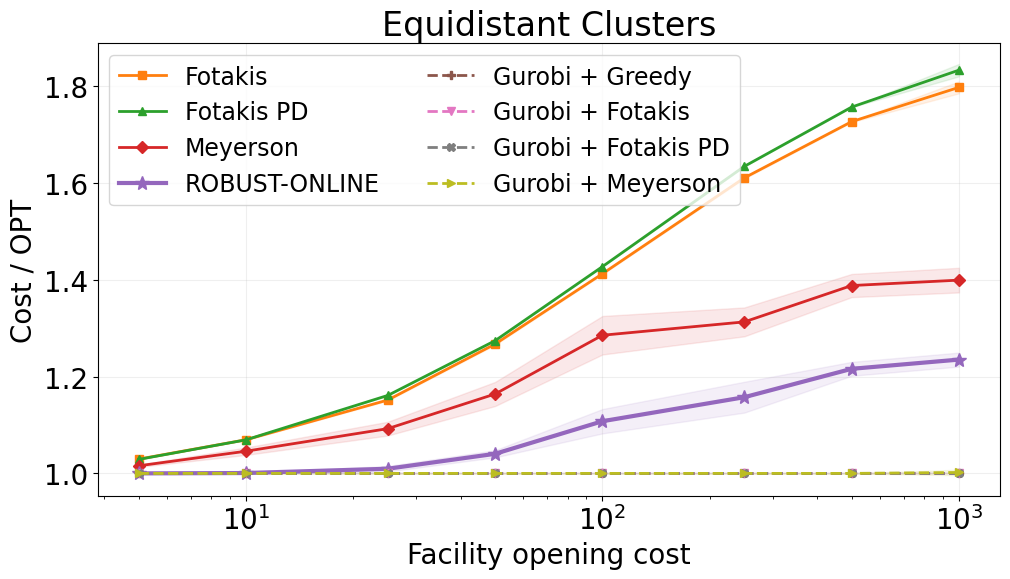


Average Cost / Gurobi reference
Algorithm                         5         10         25         50        100        250        500       1000
Greedy                       19.179     18.430     16.499     14.048     10.836      6.440      3.859      2.164
Fotakis                       1.029      1.070      1.152      1.267      1.413      1.611      1.727      1.798
Fotakis PD                    1.029      1.069      1.161      1.274      1.428      1.635      1.757      1.834
Meyerson                      1.016      1.046      1.093      1.164      1.286      1.313      1.388      1.400
ROBUST-ONLINE                 1.000      1.001      1.010      1.040      1.108      1.158      1.216      1.235
Gurobi + Greedy               1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Fotakis              1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Fotakis PD           1.000      1.000      1.000      

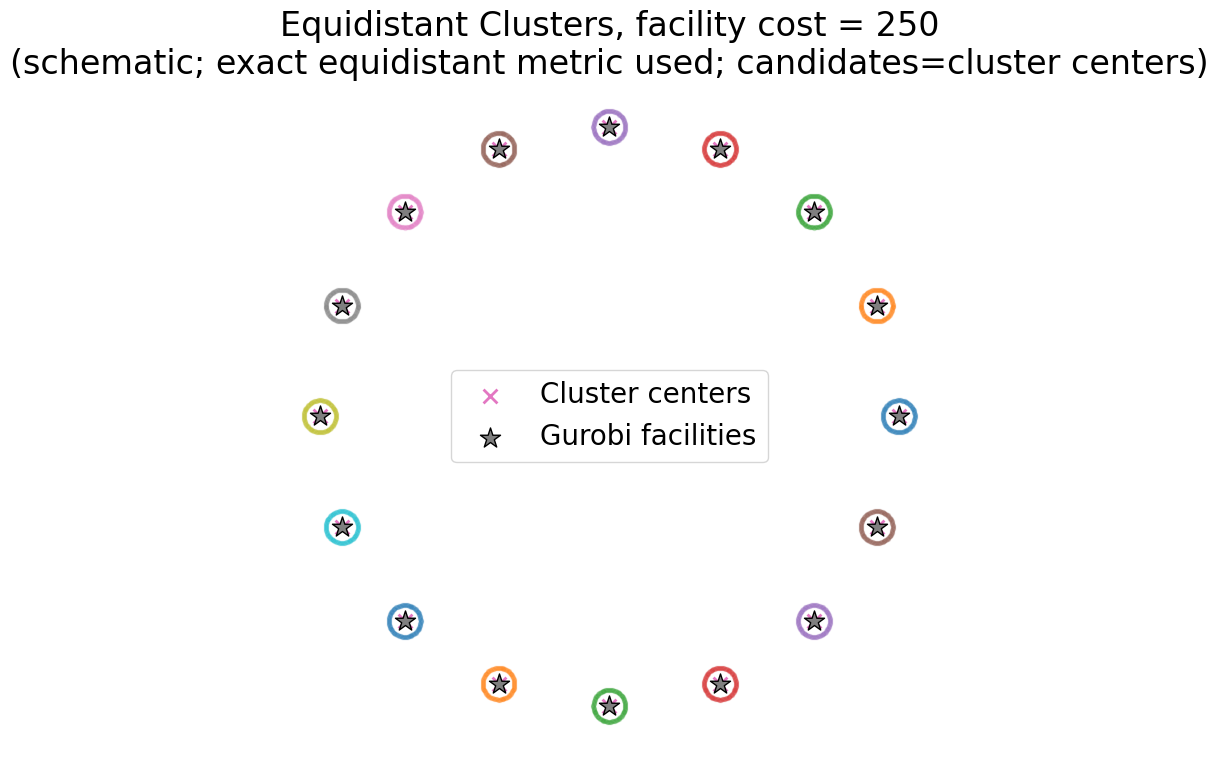

In [ ]:
# ============================================================
# 3B. PLOT — EQUIDISTANT CLUSTERS — BLOCKED CLUSTER ORDER
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = True
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'EQUIDISTANT_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 3A experiment cell before plotting.')

def _plot_equidistant():
    _d=EQUIDISTANT_PLOT_STATE
    EQUIDISTANT_COSTS=_d['EQUIDISTANT_COSTS']
    EQUIDISTANT_EXAMPLE_COST=_d['EQUIDISTANT_EXAMPLE_COST']
    EQUIDISTANT_K=_d['EQUIDISTANT_K']
    EQUIDISTANT_SUPPORT_PER_CLUSTER=_d['EQUIDISTANT_SUPPORT_PER_CLUSTER']
    candidate_label=_d['candidate_label']
    pc=_d['pc']; ps=_d['ps']; pview=_d['pview']; ref=_d['ref']; equidistant_cost=_d['equidistant_cost']

    exp_plot_nine(EQUIDISTANT_COSTS,equidistant_cost,'Equidistant Clusters',
                  'Facility opening cost','clean_equidistant',xscale='log',
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(equidistant_cost,[f'{x:g}' for x in EQUIDISTANT_COSTS])

    plt.figure(figsize=(8,8))
    for j in range(EQUIDISTANT_K):
        a=j*EQUIDISTANT_SUPPORT_PER_CLUSTER; b=a+EQUIDISTANT_SUPPORT_PER_CLUSTER
        plt.scatter(ps[a:b,0],ps[a:b,1],s=8,alpha=.22)
    plt.scatter(pc[:,0],pc[:,1],marker='x',s=100,linewidths=2,label='Cluster centers')
    plt.scatter(pview[ref['opened'],0],pview[ref['opened'],1],marker='*',s=230,
                edgecolors='black',label=f'{REFERENCE_NAME} facilities')
    plt.axis('equal'); plt.axis('off')
    plt.title(f'Equidistant Clusters, facility cost = {EQUIDISTANT_EXAMPLE_COST:g}\n'
              f'(schematic; exact equidistant metric used; candidates={candidate_label})')
    if SHOW_LEGEND: plt.legend()
    plt.tight_layout(); exp_save_current('clean_equidistant_instance'); plt.show()

_plot_equidistant()

In [ ]:
# ============================================================
# 4A. RUN — EXPONENTIAL LINE — BLOCKED CLUSTER ORDER
# ============================================================
_experiment_start = time.perf_counter()

EXP_NUM_OUTER_SEEDS = 10
EXP_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
EXP_OUTER_SEEDS = exp_select_outer_seeds(EXP_NUM_OUTER_SEEDS)

EXP_K = 10
EXP_N = 20000
EXP_SUPPORT_PER_CLUSTER = 100
EXP_DIRICHLET_ALPHA = 10.0
EXP_RADIUS = .05
EXP_SUPPORT_SEED = 41001
EXP_COSTS = np.array([10,30,100,300,1000,3000,10000],dtype=np.float64)
EXP_EXAMPLE_COST = 10000.0

def exp_line_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64)
    return np.abs(A[:,0][:,None]-B[:,0][None,:])

def make_exp_line_geometry():
    support_rng=exp_support_rng(EXP_SUPPORT_SEED); centers=(2.0**np.arange(EXP_K))[:,None]
    points=np.empty((EXP_K*EXP_SUPPORT_PER_CLUSTER,1)); support=[]
    for j in range(EXP_K):
        a=j*EXP_SUPPORT_PER_CLUSTER; b=a+EXP_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],EXP_RADIUS,EXP_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(EXP_K+a,EXP_K+b,dtype=np.int32))
    return centers,points,support

EXP_FIXED_CENTERS,EXP_FIXED_POINTS,EXP_FIXED_SUPPORT=make_exp_line_geometry()

def make_clean_exp_line(seed):
    rng=np.random.default_rng(int(seed)); counts=exp_dirichlet_counts(rng,EXP_K,EXP_N,EXP_DIRICHLET_ALPHA)
    centers=EXP_FIXED_CENTERS.copy(); points=EXP_FIXED_POINTS.copy(); support=[ids.copy() for ids in EXP_FIXED_SUPPORT]
    online=[]; sample=[]
    for j,count in enumerate(counts):
        online.append(rng.choice(support[j],size=int(count),replace=True)); sample.append(rng.choice(support[j],size=int(count),replace=True))
    return np.vstack([centers,points]),np.concatenate(online).astype(np.int32),np.concatenate(sample).astype(np.int32),support,centers,counts

exp_line_cost=np.empty((len(EXP_OUTER_SEEDS),len(EXP_COSTS),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(EXP_OUTER_SEEDS):
    print(f'Exponential Line: outer seed {s+1}/{len(EXP_OUTER_SEEDS)}',flush=True)
    coordinates,online,sample,support,centers,counts=make_clean_exp_line(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,EXP_K,support,EXP_CANDIDATE_FRACTION,EXP_SUPPORT_SEED,'cluster centers')
    online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,exp_line_distance)
    print(f'  n={len(online):,}, cluster counts={counts.min():,}--{counts.max():,}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,f in enumerate(EXP_COSTS):
        print(f'  facility cost = {f:g}',flush=True); costs=np.full(M,f); pre=precompute_meyerson(D,costs)
        online_ref=exp_reference(D,costs,online,pre); sample_ref=exp_reference(D,costs,sample,pre)
        exp_line_cost[s,e]=exp_run_nine(D,costs,online,sample,sample_ref,pre)/online_ref['total']

coordinates,online,sample,support,centers,counts=make_clean_exp_line(int(EXP_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,EXP_K,support,EXP_CANDIDATE_FRACTION,EXP_SUPPORT_SEED,'cluster centers')
online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,exp_line_distance); costs=np.full(M,EXP_EXAMPLE_COST); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,online,pre)

EXP_PLOT_STATE = {
    'EXP_COSTS': EXP_COSTS,
    'EXP_EXAMPLE_COST': EXP_EXAMPLE_COST,
    'EXP_K': EXP_K,
    'candidate_label': candidate_label,
    'centers': centers,
    'coordinates': coordinates,
    'exp_line_cost': exp_line_cost,
    'ref': ref,
    'support': support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Exponential Line: outer seed 1/10
  n=20,000, cluster counts=915--2,423, candidates=cluster centers (M=10)
  facility cost = 10
  facility cost = 30
  facility cost = 100
  facility cost = 300
  facility cost = 1000
  facility cost = 3000
  facility cost = 10000
Exponential Line: outer seed 2/10
  n=20,000, cluster counts=1,106--3,035, candidates=cluster centers (M=10)
  facility cost = 10
  facility cost = 30
  facility cost = 100
  facility cost = 300
  facility cost = 1000
  facility cost = 3000
  facility cost = 10000
Exponential Line: outer seed 3/10
  n=20,000, cluster counts=1,379--2,764, candidates=cluster centers (M=10)
  facility cost = 10
  facility cost = 30
  facility cost = 100
  facility cost = 300
  facility cost = 1000
  facility cost = 3000
  facility cost = 10000
Exponential Line: outer seed 4/10
  n=20,000, cluster counts=1,546--2,560, candidates=cluster centers (M=10)
  facility cost = 10
  facility cost = 30
  facility cost = 100
  facility cost = 300
  facility c

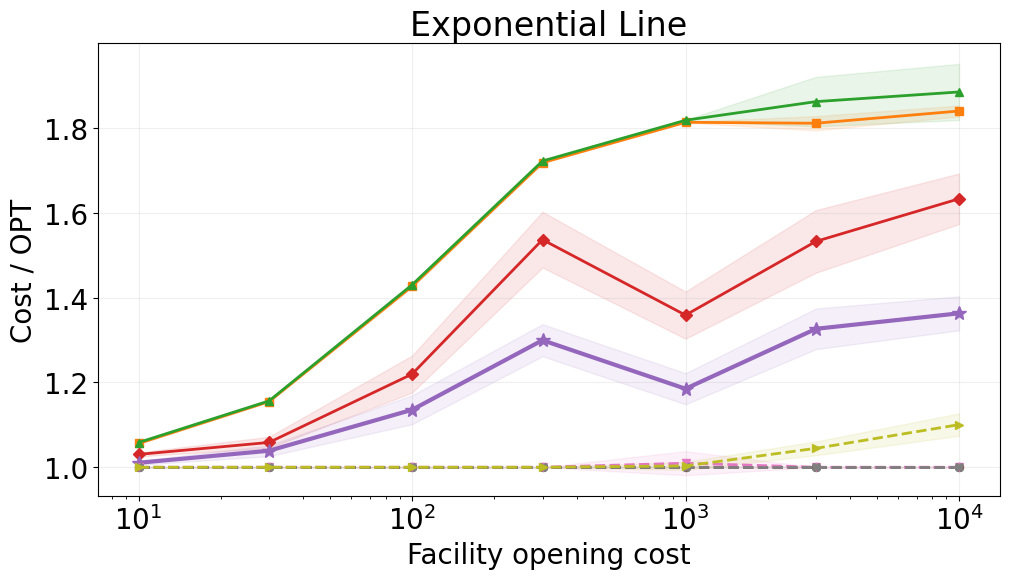


Average Cost / Gurobi reference
Algorithm                        10         30        100        300       1000       3000      10000
Greedy                       35.275     61.758    160.973    297.575    199.216     72.118     24.599
Fotakis                       1.056      1.155      1.426      1.718      1.814      1.811      1.840
Fotakis PD                    1.058      1.156      1.430      1.722      1.818      1.862      1.885
Meyerson                      1.030      1.058      1.220      1.537      1.359      1.533      1.633
ROBUST-ONLINE                 1.010      1.039      1.135      1.300      1.185      1.326      1.363
Gurobi + Greedy               1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Fotakis              1.000      1.000      1.000      1.000      1.009      1.000      1.000
Gurobi + Fotakis PD           1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Meyerson             1.000      1.000   

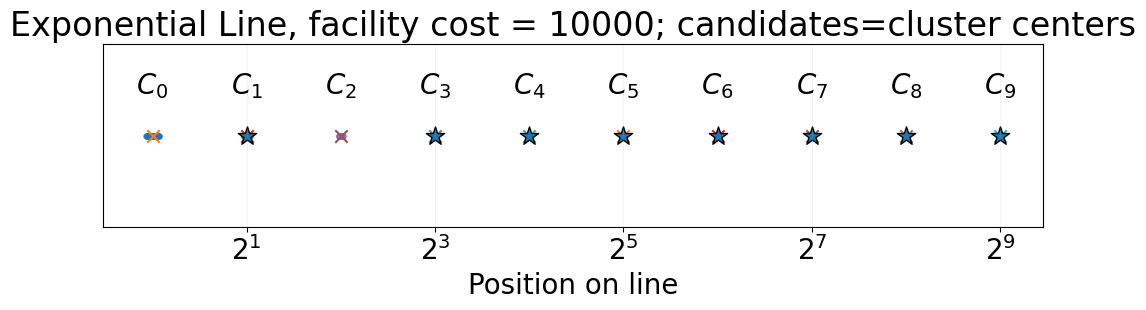

In [ ]:
# ============================================================
# 4B. PLOT — EXPONENTIAL LINE — BLOCKED CLUSTER ORDER
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'EXP_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 4A experiment cell before plotting.')

def _plot_exp():
    _d=EXP_PLOT_STATE
    EXP_COSTS=_d['EXP_COSTS']; EXP_EXAMPLE_COST=_d['EXP_EXAMPLE_COST']; EXP_K=_d['EXP_K']
    candidate_label=_d['candidate_label']; centers=_d['centers']; coordinates=_d['coordinates']
    exp_line_cost=_d['exp_line_cost']; ref=_d['ref']; support=_d['support']

    exp_plot_nine(EXP_COSTS,exp_line_cost,'Exponential Line',
                  'Facility opening cost','clean_exponential_line',xscale='log',
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(exp_line_cost,[f'{x:g}' for x in EXP_COSTS])

    plt.figure(figsize=(10,3.5))
    for j in range(EXP_K):
        plt.scatter(coordinates[support[j],0],np.zeros(len(support[j])),s=12,alpha=.3)
        plt.scatter(centers[j,0],0,marker='x',s=80)
        plt.text(centers[j,0],.025,f'$C_{j}$',ha='center')
    plt.scatter(coordinates[ref['opened'],0],np.zeros(len(ref['opened'])),marker='*',s=190,
                edgecolors='black',label=f'{REFERENCE_NAME} facilities')
    plt.xscale('log',base=2); plt.yticks([]); plt.xlabel('Position on line')
    plt.title(f'Exponential Line, facility cost = {EXP_EXAMPLE_COST:g}; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.grid(alpha=.15); plt.tight_layout()
    exp_save_current('clean_exponential_line_instance'); plt.show()

_plot_exp()

In [ ]:
# ============================================================
# 5A. RUN — CIRCULAR CLUSTERS — BLOCKED CLUSTER ORDER
# ============================================================
_experiment_start = time.perf_counter()

CIRCLE_NUM_OUTER_SEEDS = 10
CIRCLE_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
CIRCLE_OUTER_SEEDS = exp_select_outer_seeds(CIRCLE_NUM_OUTER_SEEDS)

CIRCLE_K = 16
CIRCLE_N = 20000
CIRCLE_SUPPORT_PER_CLUSTER = 100
CIRCLE_DIRICHLET_ALPHA = 10.0
CIRCLE_RADIUS = 1.0
CIRCLE_LOCAL_RADIUS = .06 # disk RMS .06/sqrt(2) equals Gaussian RMS sqrt(2)*.03
CIRCLE_SUPPORT_SEED = 51001
CIRCLE_COSTS = np.array([5,10,25,50,100,250,500,1000,2500],dtype=np.float64)
CIRCLE_EXAMPLE_COST = 500.0

def circle_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_circle_geometry():
    support_rng=exp_support_rng(CIRCLE_SUPPORT_SEED)
    theta=2*np.pi*np.arange(CIRCLE_K)/CIRCLE_K; centers=CIRCLE_RADIUS*np.column_stack([np.cos(theta),np.sin(theta)])
    points=np.empty((CIRCLE_K*CIRCLE_SUPPORT_PER_CLUSTER,2)); support=[]
    for j in range(CIRCLE_K):
        a=j*CIRCLE_SUPPORT_PER_CLUSTER; b=a+CIRCLE_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],CIRCLE_LOCAL_RADIUS,CIRCLE_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(CIRCLE_K+a,CIRCLE_K+b,dtype=np.int32))
    return centers,points,support

CIRCLE_FIXED_CENTERS,CIRCLE_FIXED_POINTS,CIRCLE_FIXED_SUPPORT=make_circle_geometry()

def make_clean_circle(seed):
    rng=np.random.default_rng(int(seed)); counts=exp_dirichlet_counts(rng,CIRCLE_K,CIRCLE_N,CIRCLE_DIRICHLET_ALPHA)
    centers=CIRCLE_FIXED_CENTERS.copy(); points=CIRCLE_FIXED_POINTS.copy(); support=[ids.copy() for ids in CIRCLE_FIXED_SUPPORT]
    online=[]; sample=[]
    for j,count in enumerate(counts):
        online.append(rng.choice(support[j],size=int(count),replace=True)); sample.append(rng.choice(support[j],size=int(count),replace=True))
    return np.vstack([centers,points]),np.concatenate(online).astype(np.int32),np.concatenate(sample).astype(np.int32),support,centers,counts

circle_cost=np.empty((len(CIRCLE_OUTER_SEEDS),len(CIRCLE_COSTS),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(CIRCLE_OUTER_SEEDS):
    print(f'Circular Clusters: outer seed {s+1}/{len(CIRCLE_OUTER_SEEDS)}',flush=True)
    coordinates,online,sample,support,centers,counts=make_clean_circle(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,CIRCLE_K,support,CIRCLE_CANDIDATE_FRACTION,CIRCLE_SUPPORT_SEED,'cluster centers')
    online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,circle_distance)
    print(f'  n={len(online):,}, cluster counts={counts.min():,}--{counts.max():,}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,f in enumerate(CIRCLE_COSTS):
        print(f'  facility cost = {f:g}',flush=True); costs=np.full(M,f); pre=precompute_meyerson(D,costs)
        online_ref=exp_reference(D,costs,online,pre); sample_ref=exp_reference(D,costs,sample,pre)
        circle_cost[s,e]=exp_run_nine(D,costs,online,sample,sample_ref,pre)/online_ref['total']

coordinates,online,sample,support,centers,counts=make_clean_circle(int(CIRCLE_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,CIRCLE_K,support,CIRCLE_CANDIDATE_FRACTION,CIRCLE_SUPPORT_SEED,'cluster centers')
online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,circle_distance); costs=np.full(M,CIRCLE_EXAMPLE_COST); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,online,pre)

CIRCLE_PLOT_STATE = {
    'CIRCLE_COSTS': CIRCLE_COSTS,
    'CIRCLE_EXAMPLE_COST': CIRCLE_EXAMPLE_COST,
    'CIRCLE_K': CIRCLE_K,
    'candidate_label': candidate_label,
    'centers': centers,
    'circle_cost': circle_cost,
    'coordinates': coordinates,
    'ref': ref,
    'support': support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Circular Clusters: outer seed 1/10
  n=20,000, cluster counts=542--2,037, candidates=cluster centers (M=16)
  facility cost = 5
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 500
  facility cost = 1000
  facility cost = 2500
Circular Clusters: outer seed 2/10
  n=20,000, cluster counts=627--2,112, candidates=cluster centers (M=16)
  facility cost = 5
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 500
  facility cost = 1000
  facility cost = 2500
Circular Clusters: outer seed 3/10
  n=20,000, cluster counts=644--1,813, candidates=cluster centers (M=16)
  facility cost = 5
  facility cost = 10
  facility cost = 25
  facility cost = 50
  facility cost = 100
  facility cost = 250
  facility cost = 500
  facility cost = 1000
  facility cost = 2500
Circular Clusters: outer seed 4/10
  n=20,000, cluster counts=723--2,138, candidates=cluste

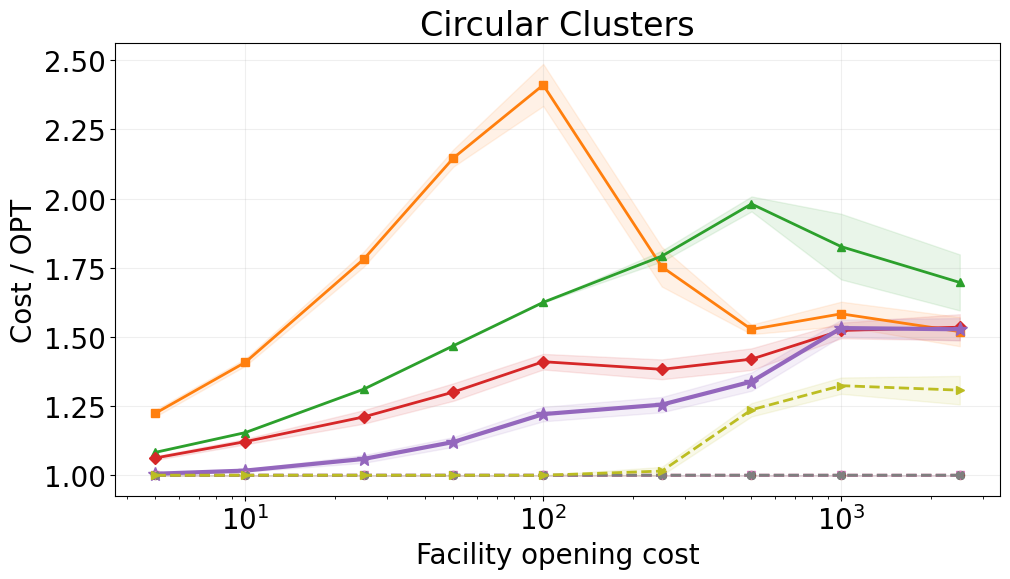


Average Cost / Gurobi reference
Algorithm                         5         10         25         50        100        250        500       1000       2500
Greedy                       29.227     26.787     21.424     16.070     10.726      5.442      3.457      2.508      1.660
Fotakis                       1.224      1.408      1.781      2.147      2.410      1.753      1.527      1.583      1.519
Fotakis PD                    1.083      1.154      1.311      1.468      1.625      1.792      1.980      1.826      1.697
Meyerson                      1.062      1.121      1.211      1.301      1.410      1.383      1.420      1.523      1.535
ROBUST-ONLINE                 1.005      1.017      1.059      1.120      1.221      1.255      1.338      1.532      1.527
Gurobi + Greedy               1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Fotakis              1.000      1.000      1.000      1.000      1.000      1.000      1.0

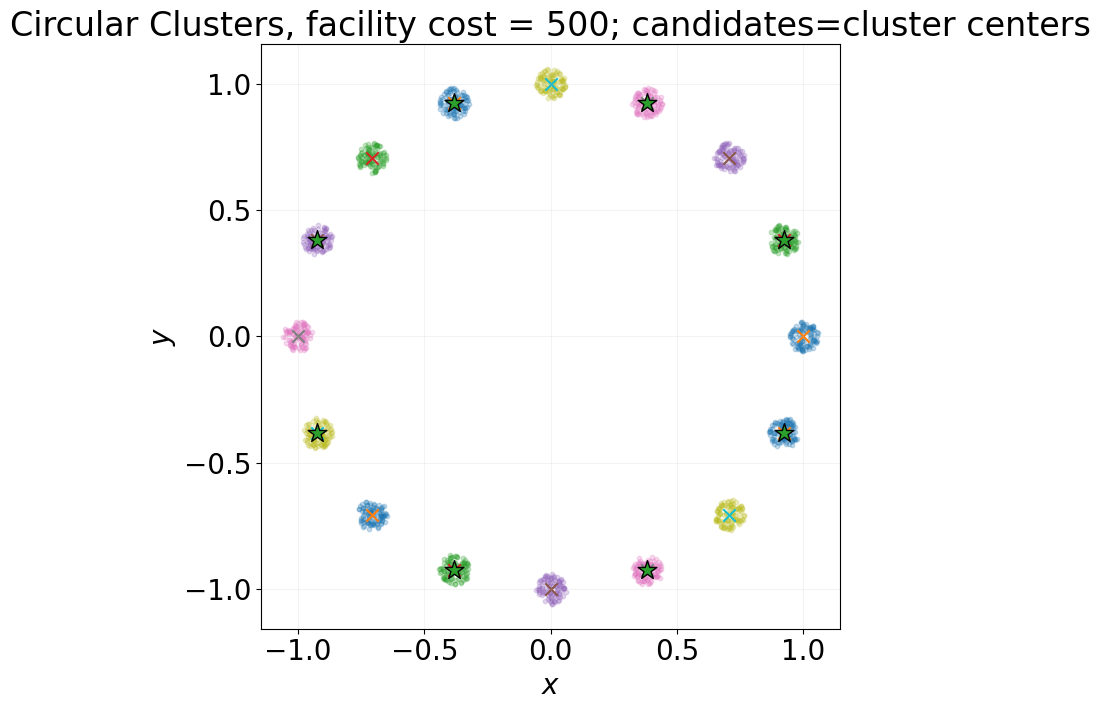

In [ ]:
# ============================================================
# 5B. PLOT — CIRCULAR CLUSTERS — BLOCKED CLUSTER ORDER
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'CIRCLE_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 5A experiment cell before plotting.')

def _plot_circle():
    _d=CIRCLE_PLOT_STATE
    CIRCLE_COSTS=_d['CIRCLE_COSTS']; CIRCLE_EXAMPLE_COST=_d['CIRCLE_EXAMPLE_COST']; CIRCLE_K=_d['CIRCLE_K']
    candidate_label=_d['candidate_label']; centers=_d['centers']; circle_cost=_d['circle_cost']
    coordinates=_d['coordinates']; ref=_d['ref']; support=_d['support']

    exp_plot_nine(CIRCLE_COSTS,circle_cost,'Circular Clusters',
                  'Facility opening cost','clean_gaussian_circle',xscale='log',
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(circle_cost,[f'{x:g}' for x in CIRCLE_COSTS])

    plt.figure(figsize=(7.5,7.5))
    for j in range(CIRCLE_K):
        plt.scatter(coordinates[support[j],0],coordinates[support[j],1],s=10,alpha=.25)
        plt.scatter(centers[j,0],centers[j,1],marker='x',s=80)
    plt.scatter(coordinates[ref['opened'],0],coordinates[ref['opened'],1],marker='*',s=200,
                edgecolors='black',label=f'{REFERENCE_NAME} facilities')
    plt.axis('equal'); plt.xlabel('$x$'); plt.ylabel('$y$')
    plt.title(f'Circular Clusters, facility cost = {CIRCLE_EXAMPLE_COST:g}; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.grid(alpha=.15); plt.tight_layout()
    exp_save_current('clean_gaussian_circle_instance'); plt.show()

_plot_circle()

In [ ]:
# ============================================================
# 6A. RUN — HIERARCHICAL LINE
# ============================================================
_experiment_start = time.perf_counter()

FOT_NUM_OUTER_SEEDS = 10
FOT_CANDIDATE_FRACTION = 1.0  # 0 = canonical facilities only; 1 = every metric point
FOT_OUTER_SEEDS = exp_select_outer_seeds(FOT_NUM_OUTER_SEEDS)

FOT_HEIGHTS = np.array([3,4,5,6,7],dtype=np.int32)
FOT_SUPPORT_PER_VERTEX = 5
FOT_BLUR = .25
FOT_EXAMPLE_HEIGHT = 4

def fot_distance(A,B):
    A=np.asarray(A,dtype=np.float64).reshape(-1); B=np.asarray(B,dtype=np.float64).reshape(-1)
    return np.abs(A[:,None]-B[None,:])

def make_clean_fotakis(h,seed):
    h=int(h); rng=np.random.default_rng(10000*int(seed)+h); position=[0.0]; level_of=[0]; children={}; current=[0]
    for level in range(h):
        step=1.0/(h**level); nxt=[]
        for parent in current:
            left,right=len(position),len(position)+1; position.extend([position[parent]-step,position[parent]+step]); level_of.extend([level+1,level+1])
            children[parent]=(left,right); nxt.extend([left,right])
        current=nxt
    position=np.asarray(position,dtype=np.float64); level_of=np.asarray(level_of,dtype=np.int32); V=len(position)
    raw_coordinates=np.empty((V*FOT_SUPPORT_PER_VERTEX,1),dtype=np.float64); raw_support=[]
    for v in range(V):
        delta=FOT_BLUR/(h**level_of[v]); a=v*FOT_SUPPORT_PER_VERTEX; b=a+FOT_SUPPORT_PER_VERTEX
        raw_coordinates[a:b,0]=position[v]+np.linspace(-delta,delta,FOT_SUPPORT_PER_VERTEX); raw_support.append(np.arange(a,b,dtype=np.int32))
    # Reorder the existing metric points so the first V are one natural representative per tree vertex.
    # This changes no distances or client support; it only makes restricted candidate mode compatible
    # with the common convention that candidate facilities are coordinates 0,...,M-1.
    designated_raw=np.asarray([ids[np.argmin(np.abs(raw_coordinates[ids,0]-position[v]))] for v,ids in enumerate(raw_support)],dtype=np.int32)
    keep=np.ones(len(raw_coordinates),dtype=bool); keep[designated_raw]=False; order=np.concatenate([designated_raw,np.flatnonzero(keep).astype(np.int32)])
    inverse=np.empty(len(order),dtype=np.int32); inverse[order]=np.arange(len(order),dtype=np.int32)
    coordinates=raw_coordinates[order]; support=[inverse[ids] for ids in raw_support]
    path=[0]; current=0
    for _ in range(h):
        left,right=children[current]; current=left if rng.integers(2)==0 else right; path.append(current)
    online=[]; sample=[]
    for level in range(h+1):
        count=h**level; ids=support[path[level]]
        online.append(rng.choice(ids,size=count,replace=True)); sample.append(rng.choice(ids,size=count,replace=True))
    online=np.concatenate(online).astype(np.int32); sample=np.concatenate(sample).astype(np.int32)
    return coordinates,online,sample,support,level_of,np.asarray(path,dtype=np.int32)

fot_ratio=np.empty((len(FOT_OUTER_SEEDS),len(FOT_HEIGHTS),len(ALG_SEEDS),9),dtype=np.float64)
fot_ns=[sum(int(h)**level for level in range(int(h)+1)) for h in FOT_HEIGHTS]
for s,outer_seed in enumerate(FOT_OUTER_SEEDS):
    print(f'Hierarchical Line: outer seed {s+1}/{len(FOT_OUTER_SEEDS)}',flush=True)
    for e,h in enumerate(FOT_HEIGHTS):
        coordinates,online,sample,support,level_of,path=make_clean_fotakis(h,outer_seed)
        coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(level_of),support,FOT_CANDIDATE_FRACTION,10000*int(outer_seed)+int(h),'one designated support point per tree vertex')
        online=remap[online]; sample=remap[sample]; costs=np.full(M,float(h),dtype=np.float64)
        print(f'  h={int(h)}, n={len(online):,}, support/vertex={FOT_SUPPORT_PER_VERTEX}, facility cost={costs[0]:g}, candidates={candidate_label} (M={M:,})',flush=True)
        D=precompute_distance_matrix(coordinates,fot_distance); pre=precompute_meyerson(D,costs)
        online_ref=exp_reference(D,costs,online,pre); sample_ref=exp_reference(D,costs,sample,pre)
        fot_ratio[s,e]=exp_run_nine(D,costs,online,sample,sample_ref,pre)/online_ref['total']

fot_labels=[f'h={int(h)}\nn={n:,}' for h,n in zip(FOT_HEIGHTS,fot_ns)]

coordinates,online,sample,support,level_of,path=make_clean_fotakis(FOT_EXAMPLE_HEIGHT,int(FOT_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(level_of),support,FOT_CANDIDATE_FRACTION,10000*int(FOT_OUTER_SEEDS[0])+int(FOT_EXAMPLE_HEIGHT),'one designated support point per tree vertex')
online=remap[online]; sample=remap[sample]; costs=np.full(M,float(FOT_EXAMPLE_HEIGHT),dtype=np.float64)
D=precompute_distance_matrix(coordinates,fot_distance); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,online,pre)
point_level=np.empty(len(coordinates),dtype=np.int32)
for v,ids in enumerate(support): point_level[ids]=level_of[v]
path_points=np.concatenate([support[int(v)] for v in path]); counts=np.bincount(online,minlength=len(coordinates))

FOT_PLOT_STATE = {
    'FOT_EXAMPLE_HEIGHT': FOT_EXAMPLE_HEIGHT,
    'FOT_HEIGHTS': FOT_HEIGHTS,
    'candidate_label': candidate_label,
    'coordinates': coordinates,
    'counts': counts,
    'fot_labels': fot_labels,
    'fot_ns': fot_ns,
    'fot_ratio': fot_ratio,
    'path_points': path_points,
    'point_level': point_level,
    'ref': ref,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Hierarchical Line: outer seed 1/10
  h=3, n=40, support/vertex=5, facility cost=3, candidates=all points (M=75)
  h=4, n=341, support/vertex=5, facility cost=4, candidates=all points (M=155)
  h=5, n=3,906, support/vertex=5, facility cost=5, candidates=all points (M=315)
  h=6, n=55,987, support/vertex=5, facility cost=6, candidates=all points (M=635)
  h=7, n=960,800, support/vertex=5, facility cost=7, candidates=all points (M=1,275)
Hierarchical Line: outer seed 2/10
  h=3, n=40, support/vertex=5, facility cost=3, candidates=all points (M=75)
  h=4, n=341, support/vertex=5, facility cost=4, candidates=all points (M=155)
  h=5, n=3,906, support/vertex=5, facility cost=5, candidates=all points (M=315)
  h=6, n=55,987, support/vertex=5, facility cost=6, candidates=all points (M=635)
  h=7, n=960,800, support/vertex=5, facility cost=7, candidates=all points (M=1,275)
Hierarchical Line: outer seed 3/10
  h=3, n=40, support/vertex=5, facility cost=3, candidates=all points (M=75)
  h=4, n=3

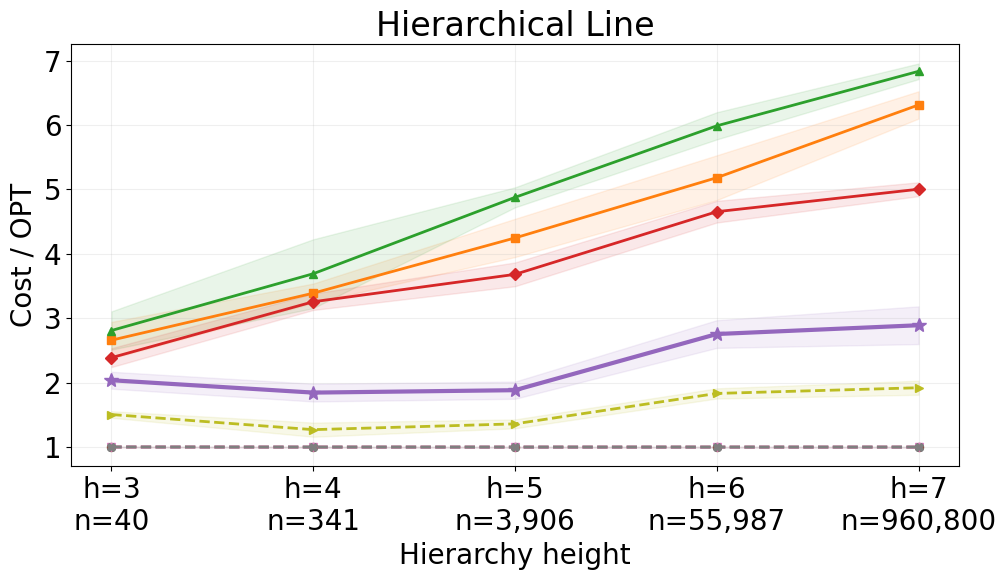


Average Cost / Gurobi reference
Algorithm                         h=3          h=4          h=5          h=6          h=7
clients                            40          341        3,906       55,987      960,800
Greedy                          6.036       39.886      407.550     4435.031    71649.998
Fotakis                         2.659        3.389        4.247        5.182        6.312
Fotakis PD                      2.809        3.691        4.877        5.987        6.834
Meyerson                        2.388        3.256        3.681        4.654        5.003
ROBUST-ONLINE                   2.038        1.845        1.883        2.755        2.891
Gurobi + Greedy                 1.001        1.000        1.000        1.000        1.000
Gurobi + Fotakis                1.001        1.000        1.000        1.000        1.000
Gurobi + Fotakis PD             1.001        1.000        1.000        1.000        1.000
Gurobi + Meyerson               1.505        1.270        1.360    

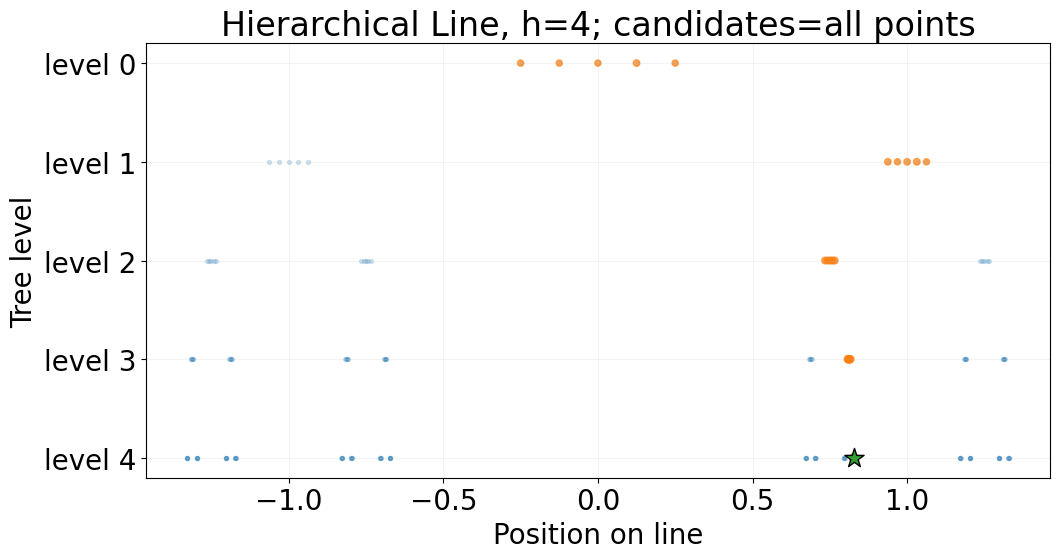

In [ ]:
# ============================================================
# 6B. PLOT — HIERARCHICAL LINE
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'FOT_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 6A experiment cell before plotting.')

def _plot_fot():
    _d=FOT_PLOT_STATE
    FOT_EXAMPLE_HEIGHT=_d['FOT_EXAMPLE_HEIGHT']; FOT_HEIGHTS=_d['FOT_HEIGHTS']
    candidate_label=_d['candidate_label']; coordinates=_d['coordinates']; counts=_d['counts']
    fot_labels=_d['fot_labels']; fot_ns=_d['fot_ns']; fot_ratio=_d['fot_ratio']
    path_points=_d['path_points']; point_level=_d['point_level']; ref=_d['ref']

    exp_plot_nine(FOT_HEIGHTS,fot_ratio,'Hierarchical Line','Hierarchy height',
                  'clean_blurred_fotakis',xticks=FOT_HEIGHTS,xticklabels=fot_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(fot_ratio,[f'h={int(h)}' for h in FOT_HEIGHTS],
                    extra_rows=[('clients',[f'{n:,}' for n in fot_ns])],width=13)

    plt.figure(figsize=(11,6))
    plt.scatter(coordinates[:,0],-point_level,s=8,alpha=.18,label='All support points')
    plt.scatter(coordinates[path_points,0],-point_level[path_points],
                s=20+2*np.sqrt(counts[path_points]),alpha=.65,label='Realized path support')
    plt.scatter(coordinates[ref['opened'],0],-point_level[ref['opened']],marker='*',s=210,
                edgecolors='black',label=f'{REFERENCE_NAME} facilities')
    plt.yticks(-np.arange(FOT_EXAMPLE_HEIGHT+1),[f'level {i}' for i in range(FOT_EXAMPLE_HEIGHT+1)])
    plt.xlabel('Position on line'); plt.ylabel('Tree level')
    plt.title(f'Hierarchical Line, h={FOT_EXAMPLE_HEIGHT}; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.grid(alpha=.15); plt.tight_layout()
    exp_save_current('clean_blurred_fotakis_instance'); plt.show()

_plot_fot()

In [ ]:
5# ============================================================
# 7A. RUN — PAIRED CLUSTERS — ALL A_i BLOCKS, THEN ALL B_i BLOCKS
# ============================================================
_experiment_start = time.perf_counter()

DUMB_NUM_OUTER_SEEDS = 10
DUMB_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
DUMB_OUTER_SEEDS = exp_select_outer_seeds(DUMB_NUM_OUTER_SEEDS)

DUMB_PAIRS = 8
DUMB_N = 20000
DUMB_MACRO_RADIUS = 5.0
DUMB_PAIR_SEPARATION = .8
DUMB_SUPPORT_PER_CLUSTER = 5
DUMB_LOCAL_RADIUS = .04
DUMB_SUPPORT_SEED = 71001
if DUMB_N % (2*DUMB_PAIRS) != 0: raise ValueError('DUMB_N must be divisible by 2*DUMB_PAIRS.')
DUMB_COUNT = DUMB_N//(2*DUMB_PAIRS)
DUMB_COSTS = np.array([50,100,200,300,400,500,750,1000,1500,2500],dtype=np.float64)
DUMB_EXAMPLE_COST = 500.0

def dumb_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_dumbbell_geometry():
    support_rng=exp_support_rng(DUMB_SUPPORT_SEED); theta=2*np.pi*np.arange(DUMB_PAIRS)/DUMB_PAIRS
    mid=DUMB_MACRO_RADIUS*np.column_stack([np.cos(theta),np.sin(theta)])
    tangent=np.column_stack([-np.sin(theta),np.cos(theta)])
    A=mid-.5*DUMB_PAIR_SEPARATION*tangent; B=mid+.5*DUMB_PAIR_SEPARATION*tangent
    centers=np.vstack([A,B]); M=len(centers); points=np.empty((M*DUMB_SUPPORT_PER_CLUSTER,2)); support=[]
    for j in range(M):
        a=j*DUMB_SUPPORT_PER_CLUSTER; b=a+DUMB_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],DUMB_LOCAL_RADIUS,DUMB_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(M+a,M+b,dtype=np.int32))
    return centers,points,support,A,B

DUMB_FIXED_CENTERS,DUMB_FIXED_POINTS,DUMB_FIXED_SUPPORT,DUMB_FIXED_A,DUMB_FIXED_B=make_dumbbell_geometry()

def make_clean_dumbbells(seed):
    rng=np.random.default_rng(int(seed)); centers=DUMB_FIXED_CENTERS.copy(); points=DUMB_FIXED_POINTS.copy()
    support=[ids.copy() for ids in DUMB_FIXED_SUPPORT]; A=DUMB_FIXED_A.copy(); B=DUMB_FIXED_B.copy()
    coordinates=np.vstack([centers,points]); online=[]; sample=[]
    for j in list(range(DUMB_PAIRS))+list(range(DUMB_PAIRS,2*DUMB_PAIRS)):
        online.append(rng.choice(support[j],size=DUMB_COUNT,replace=True)); sample.append(rng.choice(support[j],size=DUMB_COUNT,replace=True))
    return coordinates,np.concatenate(online).astype(np.int32),np.concatenate(sample).astype(np.int32),support,centers,A,B

dumb_cost=np.empty((len(DUMB_OUTER_SEEDS),len(DUMB_COSTS),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(DUMB_OUTER_SEEDS):
    print(f'Paired Clusters: outer seed {s+1}/{len(DUMB_OUTER_SEEDS)}',flush=True)
    coordinates,online,sample,support,centers,A,B=make_clean_dumbbells(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(centers),support,DUMB_CANDIDATE_FRACTION,DUMB_SUPPORT_SEED,'paired-cluster centers')
    online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,dumb_distance)
    print(f'  n={len(online):,}, clients/endpoint={DUMB_COUNT:,}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,f in enumerate(DUMB_COSTS):
        print(f'  facility cost = {f:g}',flush=True); costs=np.full(M,f); pre=precompute_meyerson(D,costs)
        online_ref=exp_reference(D,costs,online,pre); sample_ref=exp_reference(D,costs,sample,pre)
        dumb_cost[s,e]=exp_run_nine(D,costs,online,sample,sample_ref,pre)/online_ref['total']

coordinates,online,sample,support,centers,A,B=make_clean_dumbbells(int(DUMB_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(centers),support,DUMB_CANDIDATE_FRACTION,DUMB_SUPPORT_SEED,'paired-cluster centers')
online=remap[online]; sample=remap[sample]; D=precompute_distance_matrix(coordinates,dumb_distance); costs=np.full(M,DUMB_EXAMPLE_COST); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,online,pre)

DUMB_PLOT_STATE = {
    'A': A,
    'B': B,
    'DUMB_COSTS': DUMB_COSTS,
    'DUMB_EXAMPLE_COST': DUMB_EXAMPLE_COST,
    'DUMB_PAIRS': DUMB_PAIRS,
    'candidate_label': candidate_label,
    'centers': centers,
    'coordinates': coordinates,
    'dumb_cost': dumb_cost,
    'ref': ref,
    'support': support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Paired Clusters: outer seed 1/10
  n=20,000, clients/endpoint=1,250, candidates=paired-cluster centers (M=16)
  facility cost = 50
  facility cost = 100
  facility cost = 200
  facility cost = 300
  facility cost = 400
  facility cost = 500
  facility cost = 750
  facility cost = 1000
  facility cost = 1500
  facility cost = 2500
Paired Clusters: outer seed 2/10
  n=20,000, clients/endpoint=1,250, candidates=paired-cluster centers (M=16)
  facility cost = 50
  facility cost = 100
  facility cost = 200
  facility cost = 300
  facility cost = 400
  facility cost = 500
  facility cost = 750
  facility cost = 1000
  facility cost = 1500
  facility cost = 2500
Paired Clusters: outer seed 3/10
  n=20,000, clients/endpoint=1,250, candidates=paired-cluster centers (M=16)
  facility cost = 50
  facility cost = 100
  facility cost = 200
  facility cost = 300
  facility cost = 400
  facility cost = 500
  facility cost = 750
  facility cost = 1000
  facility cost = 1500
  facility cost = 2500
Pair

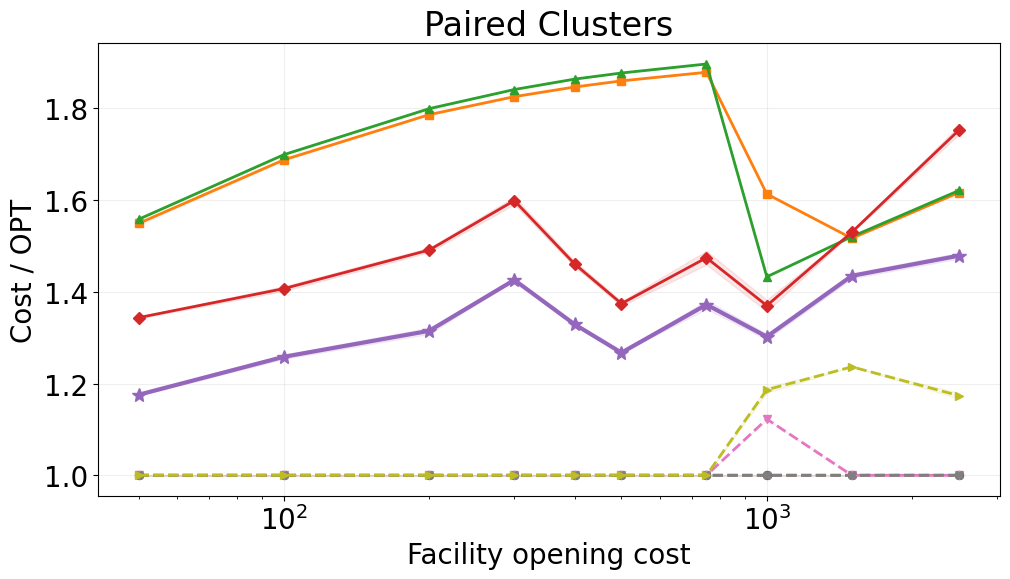


Average Cost / Gurobi reference
Algorithm                        50        100        200        300        400        500        750       1000       1500       2500
Greedy                       95.420     59.621     34.079     23.870     18.374     14.940     10.191      7.887      6.351      4.587
Fotakis                       1.549      1.688      1.786      1.825      1.846      1.860      1.878      1.613      1.517      1.616
Fotakis PD                    1.558      1.699      1.799      1.841      1.864      1.877      1.897      1.433      1.520      1.621
Meyerson                      1.344      1.407      1.491      1.599      1.461      1.374      1.474      1.370      1.530      1.752
ROBUST-ONLINE                 1.175      1.258      1.315      1.426      1.329      1.267      1.372      1.302      1.435      1.479
Gurobi + Greedy               1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Gurobi + Fotakis      

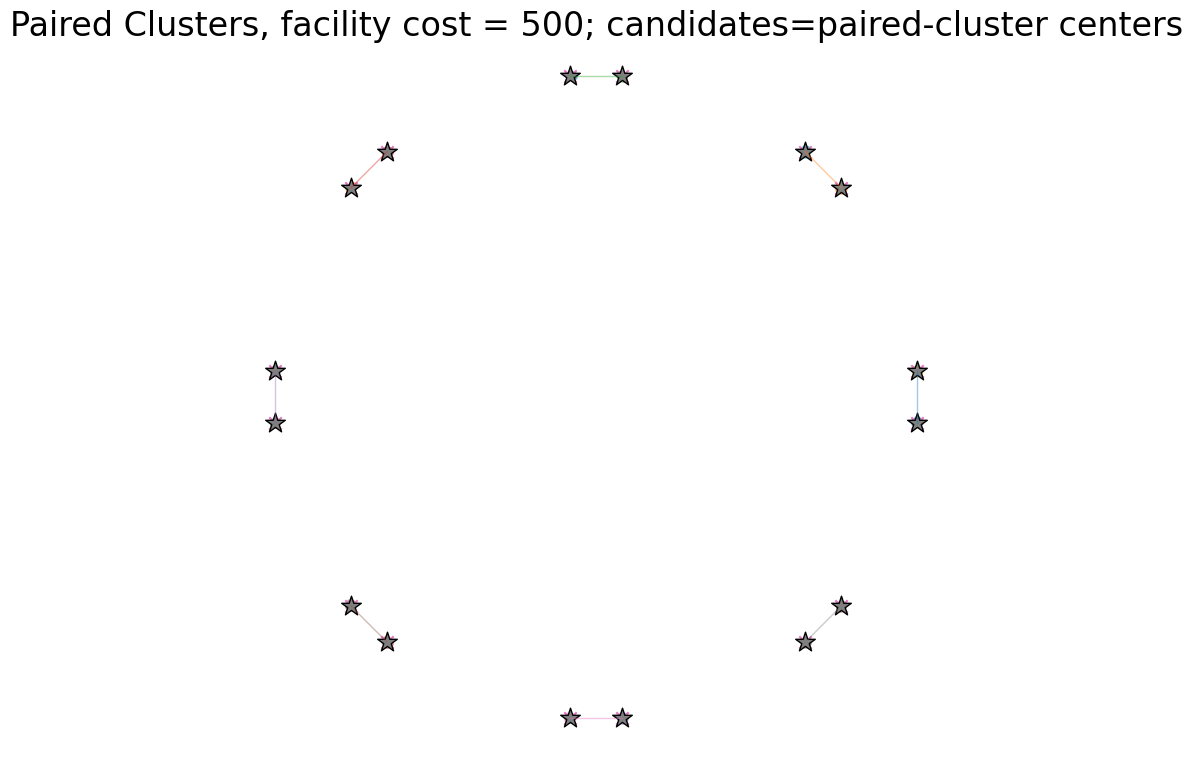

In [ ]:
# ============================================================
# 7B. PLOT — PAIRED CLUSTERS — ALL A_i BLOCKS, THEN ALL B_i BLOCKS
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'DUMB_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 7A experiment cell before plotting.')

def _plot_dumb():
    _d=DUMB_PLOT_STATE
    A=_d['A']
    B=_d['B']
    DUMB_COSTS=_d['DUMB_COSTS']
    DUMB_EXAMPLE_COST=_d['DUMB_EXAMPLE_COST']
    DUMB_PAIRS=_d['DUMB_PAIRS']
    candidate_label=_d['candidate_label']
    centers=_d['centers']
    coordinates=_d['coordinates']
    dumb_cost=_d['dumb_cost']
    ref=_d['ref']
    support=_d['support']
    exp_plot_nine(DUMB_COSTS,dumb_cost,'Paired Clusters','Facility opening cost','clean_dumbbells',xscale='log',
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(dumb_cost,[f'{x:g}' for x in DUMB_COSTS])

    plt.figure(figsize=(8,8))
    for i in range(DUMB_PAIRS): plt.plot([A[i,0],B[i,0]],[A[i,1],B[i,1]],linewidth=1,alpha=.4)
    for ids in support: plt.scatter(coordinates[ids,0],coordinates[ids,1],s=30,alpha=.4)
    plt.scatter(centers[:,0],centers[:,1],marker='x',s=80,label='Paired-cluster centers')
    plt.scatter(coordinates[ref['opened'],0],coordinates[ref['opened'],1],marker='*',s=220,edgecolors='black',label=f'{REFERENCE_NAME} facilities')
    plt.axis('equal'); plt.axis('off'); plt.title(f'Paired Clusters, facility cost = {DUMB_EXAMPLE_COST:g}; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.tight_layout(); exp_save_current('clean_dumbbells_instance'); plt.show()

_plot_dumb()


In [ ]:
# ============================================================
# 8A. RUN — HIERARCHICAL BRANCH CORRUPTION
# ============================================================
_experiment_start = time.perf_counter()

DB_NUM_OUTER_SEEDS = 10
DB_CANDIDATE_FRACTION = 1.0  # 0 = canonical facilities only; 1 = every metric point
DB_OUTER_SEEDS = exp_select_outer_seeds(DB_NUM_OUTER_SEEDS)

DB_H = 6
DB_SUPPORT_PER_VERTEX = 5
DB_BLUR = .25
DB_EPS = np.array([0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1],dtype=np.float64)
DB_EXAMPLE_EPS = .5
DB_LEVEL_COUNTS = np.array([DB_H**l for l in range(DB_H+1)],dtype=np.int64)
DB_SAMPLE_N = int(DB_LEVEL_COUNTS.sum())
DB_NUM_CORRUPTED = np.array([sum(int(round(e*c)) for c in DB_LEVEL_COUNTS[1:]) for e in DB_EPS],dtype=np.int64)
DB_X = DB_NUM_CORRUPTED/DB_SAMPLE_N
DB_XLABELS = [f'{100*x:.0f}%' if x>0 else '0%' for x in DB_X]

def db_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64)
    return np.abs(A[:,0][:,None]-B[:,0][None,:])

def make_distant_branch(seed):
    h=DB_H; rng=np.random.default_rng(int(seed)); position=[0.0]; level_of=[0]; children={}; current=[0]
    for level in range(h):
        step=1.0/(h**level); nxt=[]
        for parent in current:
            left,right=len(position),len(position)+1; position.extend([position[parent]-step,position[parent]+step]); level_of.extend([level+1,level+1])
            children[parent]=(left,right); nxt.extend([left,right])
        current=nxt
    position=np.asarray(position); level_of=np.asarray(level_of,dtype=np.int32); V=len(position); facilities=position[:,None].copy()
    points=np.empty((V*DB_SUPPORT_PER_VERTEX,1)); support=[]
    for v in range(V):
        delta=DB_BLUR/(h**level_of[v]); a=v*DB_SUPPORT_PER_VERTEX; b=a+DB_SUPPORT_PER_VERTEX
        points[a:b,0]=position[v]+np.linspace(-delta,delta,DB_SUPPORT_PER_VERTEX); support.append(np.arange(V+a,V+b,dtype=np.int32))
    coordinates=np.vstack([facilities,points]); path=[0]; distant=[0]; tc=fc=0
    for _ in range(h):
        tl,tr=children[tc]; fl,fr=children[fc]
        if rng.integers(2)==0: tc,fc=tl,fr
        else: tc,fc=tr,fl
        path.append(tc); distant.append(fc)
    online=[]; clean=[]; ranges=[]; cursor=0
    for level,count in enumerate(DB_LEVEL_COUNTS):
        ids=support[path[level]]; count=int(count); online.append(rng.choice(ids,size=count,replace=True)); clean.append(rng.choice(ids,size=count,replace=True))
        ranges.append((cursor,cursor+count)); cursor+=count
    online=np.concatenate(online).astype(np.int32); clean=np.concatenate(clean).astype(np.int32)
    crng=np.random.default_rng(100000+int(seed)); orders=[None]; replacements=[None]
    for level in range(1,h+1):
        a,b=ranges[level]; count=b-a; orders.append(crng.permutation(count).astype(np.int32))
        replacements.append(crng.choice(support[distant[level]],size=count,replace=True).astype(np.int32))
    return coordinates,support,level_of,np.asarray(path),np.asarray(distant),ranges,online,clean,orders,replacements

def make_distant_sample(clean,ranges,orders,replacements,eps):
    sample=clean.copy()
    for level in range(1,len(ranges)):
        a,b=ranges[level]; moved=int(round(float(eps)*(b-a)))
        if moved: sample[a+orders[level][:moved]]=replacements[level][:moved]
    return sample

db_cost=np.empty((len(DB_OUTER_SEEDS),len(DB_EPS),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(DB_OUTER_SEEDS):
    print(f'Hierarchical Branch Corruption: outer seed {s+1}/{len(DB_OUTER_SEEDS)}',flush=True)
    coordinates,support,level_of,path,distant,ranges,online,clean,orders,replacements=make_distant_branch(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(level_of),support,DB_CANDIDATE_FRACTION,outer_seed,'tree vertices')
    online=remap[online]; clean=remap[clean]; replacements=[None if r is None else remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,float(DB_H),dtype=np.float64)
    D=precompute_distance_matrix(coordinates,db_distance); pre=precompute_meyerson(D,costs); online_ref=exp_reference(D,costs,online,pre); plain=exp_run_plain_four(D,costs,online,pre)
    print(f'  n={len(online):,}, support/vertex={DB_SUPPORT_PER_VERTEX}, facility cost={costs[0]:g}, OPT={online_ref["total"]:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,eps in enumerate(DB_EPS):
        sample=make_distant_sample(clean,ranges,orders,replacements,eps); sample_ref=exp_reference(D,costs,sample,pre); sv=exp_run_sample_five(D,costs,online,sample,sample_ref,pre)
        db_cost[s,e,:,:4]=plain/online_ref['total']; db_cost[s,e,:,4:]=sv/online_ref['total']
        print(f'  corrupted={DB_NUM_CORRUPTED[e]:,}/{DB_SAMPLE_N:,} ({100*DB_X[e]:.2f}%)',flush=True)

coordinates,support,level_of,path,distant,ranges,online,clean,orders,replacements=make_distant_branch(int(DB_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(level_of),support,DB_CANDIDATE_FRACTION,int(DB_OUTER_SEEDS[0]),'tree vertices')
online=remap[online]; clean=remap[clean]; replacements=[None if r is None else remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,float(DB_H),dtype=np.float64)
sample=make_distant_sample(clean,ranges,orders,replacements,DB_EXAMPLE_EPS); D=precompute_distance_matrix(coordinates,db_distance); pre=precompute_meyerson(D,costs)
ref=exp_reference(D,costs,sample,pre); V=len(level_of); point_level=np.empty(len(coordinates),dtype=np.int32); point_level[:V]=level_of
for v,ids in enumerate(support): point_level[ids]=level_of[v]
true_support=np.concatenate([support[int(v)] for v in path]); false_support=np.concatenate([support[int(v)] for v in distant[1:]])
all_support=np.arange(V,len(coordinates),dtype=np.int32)

DB_PLOT_STATE = {
    'DB_EXAMPLE_EPS': DB_EXAMPLE_EPS,
    'DB_H': DB_H,
    'DB_NUM_CORRUPTED': DB_NUM_CORRUPTED,
    'DB_X': DB_X,
    'all_support': all_support,
    'candidate_label': candidate_label,
    'coordinates': coordinates,
    'db_cost': db_cost,
    'false_support': false_support,
    'point_level': point_level,
    'ref': ref,
    'true_support': true_support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Hierarchical Branch Corruption: outer seed 1/10
  n=55,987, support/vertex=5, facility cost=6, OPT=11.591, candidates=all points (M=762)
  corrupted=0/55,987 (0.00%)
  corrupted=5,601/55,987 (10.00%)
  corrupted=11,196/55,987 (20.00%)
  corrupted=16,797/55,987 (30.00%)
  corrupted=22,392/55,987 (39.99%)
  corrupted=27,993/55,987 (50.00%)
  corrupted=33,594/55,987 (60.00%)
  corrupted=39,189/55,987 (70.00%)
  corrupted=44,790/55,987 (80.00%)
  corrupted=50,385/55,987 (89.99%)
  corrupted=55,986/55,987 (100.00%)
Hierarchical Branch Corruption: outer seed 2/10
  n=55,987, support/vertex=5, facility cost=6, OPT=12.023, candidates=all points (M=762)
  corrupted=0/55,987 (0.00%)
  corrupted=5,601/55,987 (10.00%)
  corrupted=11,196/55,987 (20.00%)
  corrupted=16,797/55,987 (30.00%)
  corrupted=22,392/55,987 (39.99%)
  corrupted=27,993/55,987 (50.00%)
  corrupted=33,594/55,987 (60.00%)
  corrupted=39,189/55,987 (70.00%)
  corrupted=44,790/55,987 (80.00%)
  corrupted=50,385/55,987 (89.99%)
  co

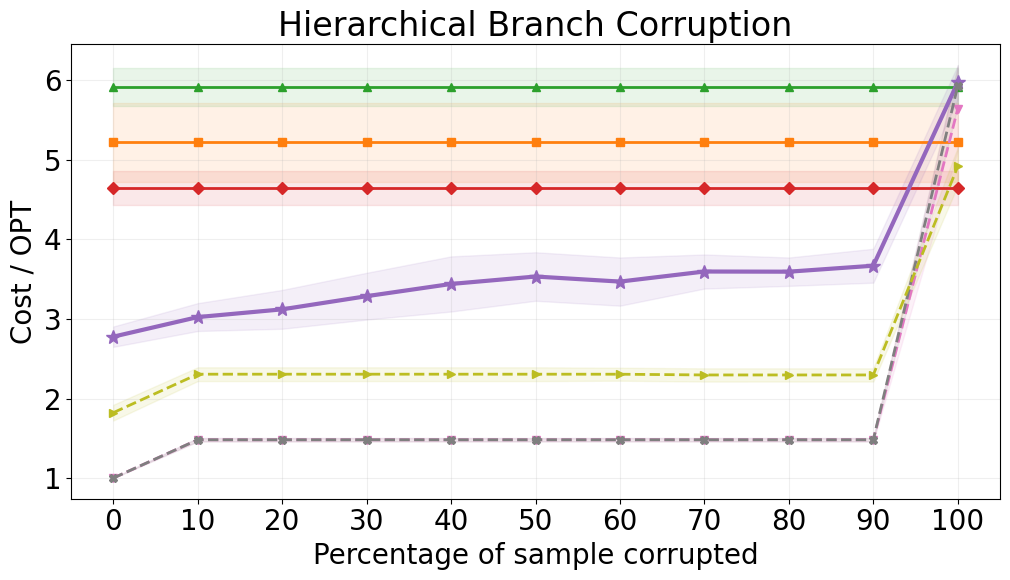


Average Cost / Gurobi reference
Algorithm                      0.0%      10.0%      20.0%      30.0%      40.0%      50.0%      60.0%      70.0%      80.0%      90.0%     100.0%
# corrupted                       0      5,601     11,196     16,797     22,392     27,993     33,594     39,189     44,790     50,385     55,986
Greedy                     4522.472   4522.472   4522.472   4522.472   4522.472   4522.472   4522.472   4522.472   4522.472   4522.472   4522.472
Fotakis                       5.220      5.220      5.220      5.220      5.220      5.220      5.220      5.220      5.220      5.220      5.220
Fotakis PD                    5.916      5.916      5.916      5.916      5.916      5.916      5.916      5.916      5.916      5.916      5.916
Meyerson                      4.651      4.651      4.651      4.651      4.651      4.651      4.651      4.651      4.651      4.651      4.651
ROBUST-ONLINE                 2.778      3.024      3.121      3.287      3.441      3.534 

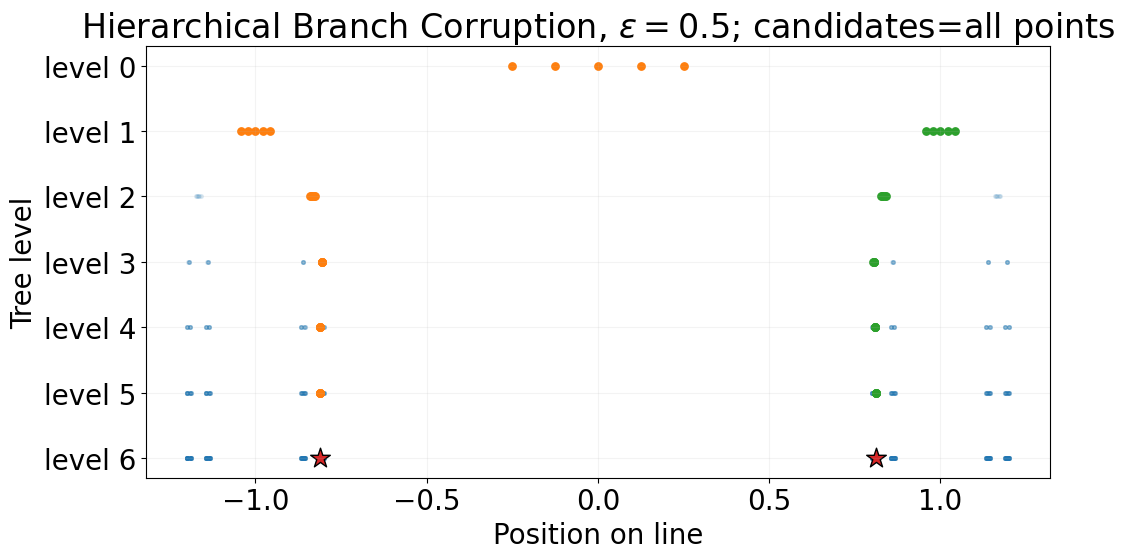

In [ ]:
# ============================================================
# 8B. PLOT — HIERARCHICAL BRANCH CORRUPTION
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = False
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'DB_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 8A experiment cell before plotting.')

def _plot_db():
    _d=DB_PLOT_STATE
    DB_EXAMPLE_EPS=_d['DB_EXAMPLE_EPS']; DB_H=_d['DB_H']; DB_NUM_CORRUPTED=_d['DB_NUM_CORRUPTED']; DB_X=_d['DB_X']
    all_support=_d['all_support']; candidate_label=_d['candidate_label']; coordinates=_d['coordinates']
    db_cost=_d['db_cost']; false_support=_d['false_support']; point_level=_d['point_level']
    ref=_d['ref']; true_support=_d['true_support']

    pct=100*DB_X
    pct_labels=[f'{x:.0f}' for x in pct]
    exp_plot_nine(pct,db_cost,'Hierarchical Branch Corruption',
                  'Percentage of sample corrupted','corrupt_distant_branch',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(db_cost,[f'{100*x:.1f}%' for x in DB_X],
                    [('# corrupted',[f'{k:,}' for k in DB_NUM_CORRUPTED])])

    plt.figure(figsize=(11,6))
    plt.scatter(coordinates[all_support,0],-point_level[all_support],s=7,alpha=.12,label='All client support')
    plt.scatter(coordinates[true_support,0],-point_level[true_support],s=28,label='True-path support')
    plt.scatter(coordinates[false_support,0],-point_level[false_support],s=28,label='Corrupted branch')
    plt.scatter(coordinates[ref['opened'],0],-point_level[ref['opened']],marker='*',s=220,
                edgecolors='black',label=f'Corrupted-sample {REFERENCE_NAME}')
    plt.yticks(-np.arange(DB_H+1),[f'level {i}' for i in range(DB_H+1)])
    plt.xlabel('Position on line'); plt.ylabel('Tree level')
    plt.title(f'Hierarchical Branch Corruption, $\\epsilon={DB_EXAMPLE_EPS:g}$; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.grid(alpha=.15); plt.tight_layout()
    exp_save_current('corrupt_distant_branch_instance'); plt.show()

_plot_db()

In [ ]:
# ============================================================
# 9A. RUN — EQUIDISTANT CLUSTER CORRUPTION
# ============================================================
_experiment_start = time.perf_counter()

SFP_NUM_OUTER_SEEDS = 10
SFP_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
SFP_OUTER_SEEDS = exp_select_outer_seeds(SFP_NUM_OUTER_SEEDS)

SFP_TRUE_K = 5
SFP_N = 20000
SFP_SUPPORT_PER_CLUSTER = 100
SFP_DIRICHLET_ALPHA = 10.0
SFP_MAX_K = 125
SFP_K_VALUES = np.array([0,10,20,30,50,75,100,125],dtype=np.int32)
SFP_SEPARATION = 2.0
SFP_LOCAL_RADIUS = .0004
SFP_SUPPORT_SEED = 91001
SFP_FACILITY_COST = 1.0
SFP_EXAMPLE_K = 64
SFP_X = SFP_K_VALUES/SFP_N
SFP_XLABELS = ['0%']+[f'{100*x:.2f}%' for x in SFP_X[1:]]

def sfp_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_equidistant_false_positive_geometry():
    support_rng=exp_support_rng(SFP_SUPPORT_SEED); M=SFP_TRUE_K+SFP_MAX_K
    equidistant=np.eye(M)-np.ones((M,M))/M; facilities=(SFP_SEPARATION/np.sqrt(2))*equidistant; true_centers=facilities[:SFP_TRUE_K]
    points=np.empty((SFP_TRUE_K*SFP_SUPPORT_PER_CLUSTER,M)); support=[]
    for j in range(SFP_TRUE_K):
        a=j*SFP_SUPPORT_PER_CLUSTER; b=a+SFP_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(true_centers[j],SFP_LOCAL_RADIUS,SFP_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(M+a,M+b,dtype=np.int32))
    return facilities,true_centers,points,support

SFP_FIXED_FACILITIES,SFP_FIXED_TRUE_CENTERS,SFP_FIXED_POINTS,SFP_FIXED_SUPPORT=make_equidistant_false_positive_geometry()

def make_equidistant_false_positive(seed):
    rng=np.random.default_rng(int(seed)); counts=exp_dirichlet_counts(rng,SFP_TRUE_K,SFP_N,SFP_DIRICHLET_ALPHA)
    facilities=SFP_FIXED_FACILITIES.copy(); true_centers=SFP_FIXED_TRUE_CENTERS.copy(); points=SFP_FIXED_POINTS.copy(); support=[ids.copy() for ids in SFP_FIXED_SUPPORT]
    coordinates=np.vstack([facilities,points]); online=[]; clean=[]
    for j,count in enumerate(counts):
        online.append(rng.choice(support[j],size=int(count),replace=True)); clean.append(rng.choice(support[j],size=int(count),replace=True))
    online=np.concatenate(online).astype(np.int32); clean=np.concatenate(clean).astype(np.int32); rng.shuffle(online); rng.shuffle(clean)
    crng=np.random.default_rng(100000+int(seed)); order=crng.permutation(SFP_N).astype(np.int32); fake_ids=np.arange(SFP_TRUE_K,SFP_TRUE_K+SFP_MAX_K,dtype=np.int32)
    return coordinates,online,clean,order,fake_ids,true_centers,support,counts

def make_sfp_sample(clean,order,fake_ids,k):
    sample=clean.copy(); k=int(k)
    if k: sample[order[:k]]=fake_ids[:k]
    return sample

sfp_cost=np.empty((len(SFP_OUTER_SEEDS),len(SFP_K_VALUES),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(SFP_OUTER_SEEDS):
    print(f'Equidistant Cluster Corruption: outer seed {s+1}/{len(SFP_OUTER_SEEDS)}',flush=True)
    coordinates,online,clean,order,fake_ids,true_centers,support,counts=make_equidistant_false_positive(outer_seed)
    designated_count=SFP_TRUE_K+SFP_MAX_K
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,designated_count,support,SFP_CANDIDATE_FRACTION,SFP_SUPPORT_SEED,'true + false-positive equidistant vertices')
    online=remap[online]; clean=remap[clean]; fake_ids=remap[fake_ids]; costs=np.full(M,SFP_FACILITY_COST,dtype=np.float64)
    D=precompute_distance_matrix(coordinates,sfp_distance); pre=precompute_meyerson(D,costs); online_ref=exp_reference(D,costs,online,pre); plain=exp_run_plain_four(D,costs,online,pre)
    mean_support_radius=np.asarray([np.mean(np.linalg.norm(coordinates[support[j]]-true_centers[j],axis=1)) for j in range(SFP_TRUE_K)])
    expected_clean_scale=SFP_TRUE_K*SFP_FACILITY_COST+float(np.dot(counts,mean_support_radius))
    print(f'  n={len(online):,}, true-cluster counts={counts.min():,}--{counts.max():,}, OPT={online_ref["total"]:.3f}, fixed-support expected clean scale={expected_clean_scale:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,k in enumerate(SFP_K_VALUES):
        sample=make_sfp_sample(clean,order,fake_ids,k); sample_ref=exp_reference(D,costs,sample,pre); sv=exp_run_sample_five(D,costs,online,sample,sample_ref,pre)
        sfp_cost[s,e,:,:4]=plain/online_ref['total']; sfp_cost[s,e,:,4:]=sv/online_ref['total']; fake_open=np.intersect1d(sample_ref['opened'],fake_ids).size
        print(f'  corrupted={int(k):,}/{SFP_N:,} ({100*SFP_X[e]:.2f}%), sample Gurobi fake facilities={fake_open}',flush=True)
        if fake_open!=int(k):
            print(f'  WARNING: expected {int(k)} false-positive equidistant facilities but Gurobi opened {fake_open}; candidates={candidate_label}, sample objective={sample_ref["total"]:.6f}, total facilities={len(sample_ref["opened"])}',flush=True)

coordinates,online,clean,order,fake_ids,true_centers,support,counts=make_equidistant_false_positive(int(SFP_OUTER_SEEDS[0]))
designated_count=SFP_TRUE_K+SFP_MAX_K
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,designated_count,support,SFP_CANDIDATE_FRACTION,SFP_SUPPORT_SEED,'true + false-positive equidistant vertices')
online=remap[online]; clean=remap[clean]; fake_ids=remap[fake_ids]; costs=np.full(M,SFP_FACILITY_COST,dtype=np.float64)
sample=make_sfp_sample(clean,order,fake_ids,SFP_EXAMPLE_K); D=precompute_distance_matrix(coordinates,sfp_distance); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,sample,pre)
M0=designated_count; theta=2*np.pi*np.arange(M0)/M0; pv=np.column_stack([np.cos(theta),np.sin(theta)]); active=fake_ids[:SFP_EXAMPLE_K]
angles=2*np.pi*np.arange(SFP_SUPPORT_PER_CLUSTER)/SFP_SUPPORT_PER_CLUSTER; support_view=np.vstack([pv[j]+.04*np.column_stack([np.cos(angles),np.sin(angles)]) for j in range(SFP_TRUE_K)]); pview=np.vstack([pv,support_view])[np.argsort(remap)]

SFP_PLOT_STATE = {
    'SFP_EXAMPLE_K': SFP_EXAMPLE_K,
    'SFP_K_VALUES': SFP_K_VALUES,
    'SFP_N': SFP_N,
    'SFP_TRUE_K': SFP_TRUE_K,
    'SFP_X': SFP_X,
    'SFP_XLABELS': SFP_XLABELS,
    'active': active,
    'candidate_label': candidate_label,
    'pv': pv,
    'pview': pview,
    'ref': ref,
    'sfp_cost': sfp_cost,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Equidistant Cluster Corruption: outer seed 1/10
  n=20,000, true-cluster counts=2,021--5,155, OPT=12.936, fixed-support expected clean scale=12.936, candidates=true + false-positive equidistant vertices (M=130)
  corrupted=0/20,000 (0.00%), sample Gurobi fake facilities=0
  corrupted=10/20,000 (0.05%), sample Gurobi fake facilities=10
  corrupted=20/20,000 (0.10%), sample Gurobi fake facilities=20
  corrupted=30/20,000 (0.15%), sample Gurobi fake facilities=30
  corrupted=50/20,000 (0.25%), sample Gurobi fake facilities=50
  corrupted=75/20,000 (0.38%), sample Gurobi fake facilities=75
  corrupted=100/20,000 (0.50%), sample Gurobi fake facilities=100
  corrupted=125/20,000 (0.62%), sample Gurobi fake facilities=125
Equidistant Cluster Corruption: outer seed 2/10
  n=20,000, true-cluster counts=2,336--5,190, OPT=12.937, fixed-support expected clean scale=12.937, candidates=true + false-positive equidistant vertices (M=130)
  corrupted=0/20,000 (0.00%), sample Gurobi fake facilities=0
  

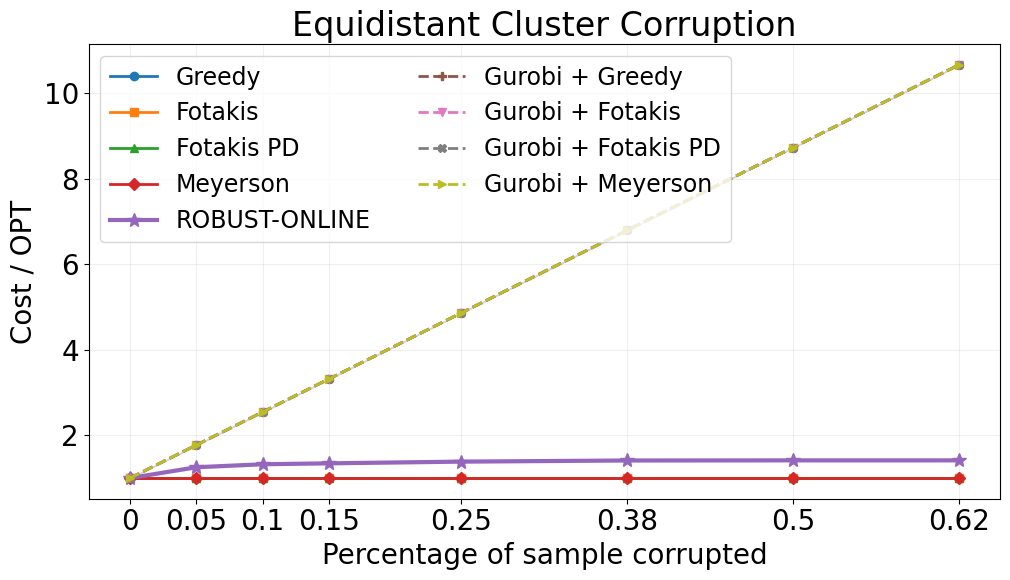


Average Cost / Gurobi reference
Algorithm                        0%      0.05%      0.10%      0.15%      0.25%      0.38%      0.50%      0.62%
# corrupted                       0         10         20         30         50         75        100        125
Greedy                        1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Fotakis                       1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Fotakis PD                    1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
Meyerson                      1.000      1.000      1.000      1.000      1.000      1.000      1.000      1.000
ROBUST-ONLINE                 1.000      1.254      1.323      1.345      1.385      1.411      1.414      1.414
Gurobi + Greedy               1.000      1.773      2.546      3.319      4.865      6.798      8.730     10.663
Gurobi + Fotakis              1.000      1.773      2.546      

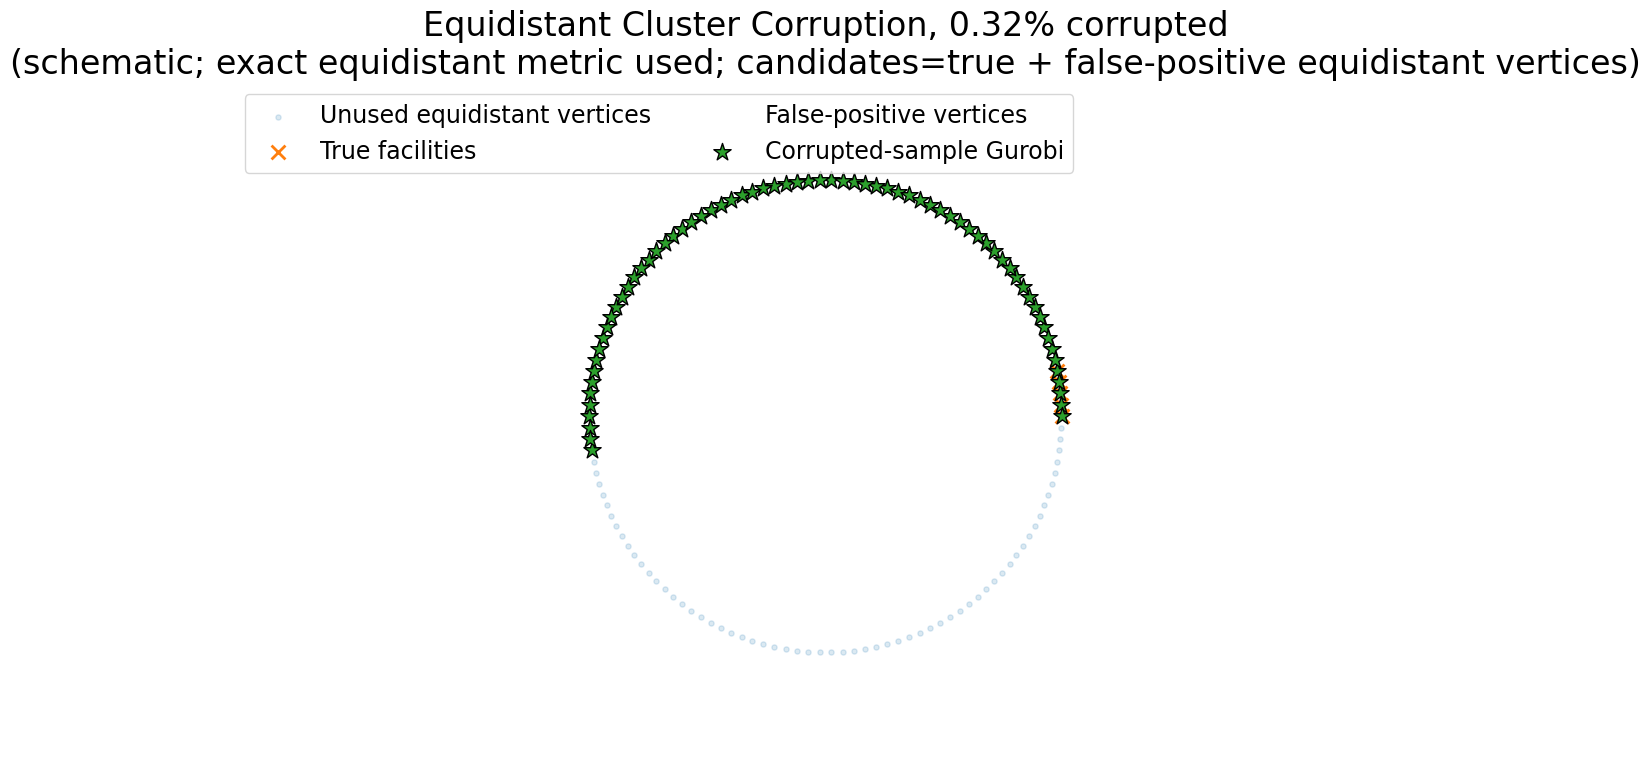

In [ ]:
# ============================================================
# 9B. PLOT — EQUIDISTANT CLUSTER CORRUPTION
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = True
SHOW_GREEDY = True
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'SFP_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 9A experiment cell before plotting.')

def _plot_sfp():
    _d=SFP_PLOT_STATE
    SFP_EXAMPLE_K=_d['SFP_EXAMPLE_K']; SFP_K_VALUES=_d['SFP_K_VALUES']; SFP_N=_d['SFP_N']
    SFP_TRUE_K=_d['SFP_TRUE_K']; SFP_X=_d['SFP_X']; SFP_XLABELS=_d['SFP_XLABELS']
    active=_d['active']; candidate_label=_d['candidate_label']; pv=_d['pv']; pview=_d['pview']
    ref=_d['ref']; sfp_cost=_d['sfp_cost']

    pct=100*SFP_X
    pct_labels=[f'{x:.2f}'.rstrip('0').rstrip('.') for x in pct]
    exp_plot_nine(pct,sfp_cost,'Equidistant Cluster Corruption',
                  'Percentage of sample corrupted','corrupt_equidistant_false_positives',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(sfp_cost,SFP_XLABELS,
                    [('# corrupted',[f'{int(k):,}' for k in SFP_K_VALUES])])

    plt.figure(figsize=(8,8))
    plt.scatter(pv[SFP_TRUE_K:,0],pv[SFP_TRUE_K:,1],s=14,alpha=.16,label='Unused equidistant vertices')
    plt.scatter(pv[:SFP_TRUE_K,0],pv[:SFP_TRUE_K,1],marker='x',s=100,linewidths=2,label='True facilities')
    plt.scatter(pv[active,0],pv[active,1],s=55,marker='s',facecolors='none',
                linewidths=1.2,label='False-positive vertices')
    plt.scatter(pview[ref['opened'],0],pview[ref['opened'],1],marker='*',s=170,
                edgecolors='black',label=f'Corrupted-sample {REFERENCE_NAME}')
    plt.axis('equal'); plt.axis('off')
    plt.title(f'Equidistant Cluster Corruption, {100*SFP_EXAMPLE_K/SFP_N:.2f}% corrupted\n'
              f'(schematic; exact equidistant metric used; candidates={candidate_label})')
    if SHOW_LEGEND: plt.legend(ncol=2,fontsize=max(8,global_font-3))
    plt.tight_layout()
    exp_save_current('corrupt_equidistant_false_positives_instance'); plt.show()

_plot_sfp()

In [ ]:
# ============================================================
# 10A. RUN — HIERARCHICAL COMPONENT CORRUPTION
# ============================================================
_experiment_start = time.perf_counter()

FH_NUM_OUTER_SEEDS = 10
FH_CANDIDATE_FRACTION = 1.0  # 0 = canonical facilities only; 1 = every metric point
FH_OUTER_SEEDS = exp_select_outer_seeds(FH_NUM_OUTER_SEEDS)

FH_H = 5
FH_RARE_K = 12
FH_RARE_WEIGHT = 1
FH_SINK_WEIGHT = 100
FH_SUPPORT_PER_VERTEX = 1
FH_BLUR = 0.0
FH_LOCAL_SCALE = .25
FH_SEPARATION = 2.0
FH_FACILITY_COST = FH_H*FH_LOCAL_SCALE
FH_BASE_N = sum(FH_H**l for l in range(FH_H+1))
FH_Q = np.arange(FH_RARE_K+1,dtype=np.int32)
FH_SAMPLE_N = (FH_SINK_WEIGHT+FH_RARE_K*FH_RARE_WEIGHT)*FH_BASE_N
FH_NUM_CORRUPTED = FH_Q*FH_BASE_N
FH_X = FH_NUM_CORRUPTED/FH_SAMPLE_N
FH_XLABELS = ['0%']+[f'{100*x:.1f}%' for x in FH_X[1:]]
FH_EXAMPLE_Q = 6
FH_GUROBI_TIME_LIMIT = 1800

def fh_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_fotakis_gadget(center,weight,seed):
    h=FH_H; rng=np.random.default_rng(int(seed)); position=[0.0]; level_of=[0]; children={}; current=[0]
    for level in range(h):
        step=1.0/(h**level); nxt=[]
        for parent in current:
            left,right=len(position),len(position)+1
            position.extend([position[parent]-step,position[parent]+step]); level_of.extend([level+1,level+1])
            children[parent]=(left,right); nxt.extend([left,right])
        current=nxt
    coordinates=np.repeat(center[None,:],len(position)*FH_SUPPORT_PER_VERTEX,axis=0); support=[]
    for v in range(len(position)):
        delta=FH_BLUR/(h**level_of[v]); a=v*FH_SUPPORT_PER_VERTEX; b=a+FH_SUPPORT_PER_VERTEX
        coordinates[a:b,-1]+=FH_LOCAL_SCALE*(position[v]+np.linspace(-delta,delta,FH_SUPPORT_PER_VERTEX))
        support.append(np.arange(a,b,dtype=np.int32))
    path=[0]; current=0
    for _ in range(h):
        left,right=children[current]; current=left if rng.integers(2)==0 else right; path.append(current)
    online=[]; sample=[]
    for level in range(h+1):
        count=int(weight)*(h**level); ids=support[path[level]]
        online.append(rng.choice(ids,size=count,replace=True)); sample.append(rng.choice(ids,size=count,replace=True))
    return coordinates,np.concatenate(online).astype(np.int32),np.concatenate(sample).astype(np.int32),np.concatenate([support[v] for v in path]).astype(np.int32)

def make_fotakis_equidistant(seed):
    K=FH_RARE_K+1; dim=K+1; macro=np.zeros((K,dim)); macro[:,:K]=np.eye(K)*(FH_SEPARATION/np.sqrt(2))
    coords=[]; online=[]; sample=[]; path_supports=[]; ranges=[]; offset=sample_offset=0
    for j in range(K):
        weight=FH_SINK_WEIGHT if j==0 else FH_RARE_WEIGHT
        c,o,s,p=make_fotakis_gadget(macro[j],weight,10000*int(seed)+j)
        coords.append(c); online.append(o+offset); sample.append(s+offset); path_supports.append(p+offset)
        ranges.append((sample_offset,sample_offset+len(s))); offset+=len(c); sample_offset+=len(s)
    coordinates=np.vstack(coords); online=np.concatenate(online).astype(np.int32); clean=np.concatenate(sample).astype(np.int32)
    rng=np.random.default_rng(900000+int(seed))
    a,b=ranges[0]; sink=clean[a:b]; replacements=[]
    for j in range(1,K):
        a,b=ranges[j]; replacements.append(rng.choice(sink,size=b-a,replace=True).astype(np.int32))
    return coordinates,online,clean,path_supports,macro,ranges,replacements

def make_fh_sample(clean,ranges,replacements,q):
    sample=clean.copy()
    for j in range(FH_RARE_K-int(q)+1,FH_RARE_K+1):
        a,b=ranges[j]; sample[a:b]=replacements[j-1]
    return sample

def fh_ref_from_opt(opt):
    return {'total':opt['total'],'opening':opt['opening'],'connection':opt['connection'],'opened':opt['opened']}

fh_cost=np.empty((len(FH_OUTER_SEEDS),len(FH_Q),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(FH_OUTER_SEEDS):
    print(f'Hierarchical Component Corruption: outer seed {s+1}/{len(FH_OUTER_SEEDS)}',flush=True)
    coordinates,online,clean,path_supports,macro,ranges,replacements=make_fotakis_equidistant(outer_seed)
    # FH_SUPPORT_PER_VERTEX=1, so every metric point is already canonical; the fraction knob has no effect here.
    coordinates,_,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(coordinates),[],FH_CANDIDATE_FRACTION,outer_seed,'hierarchical tree vertices (same as all points)')
    online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,FH_FACILITY_COST,dtype=np.float64)
    D=precompute_distance_matrix(coordinates,fh_distance); pre=precompute_meyerson(D,costs)
    online_opt=gurobi_integer_opt(D,costs,online,time_limit=FH_GUROBI_TIME_LIMIT,mip_gap=1e-8)
    if not online_opt['optimal']: raise RuntimeError(f'Online Gurobi gap={online_opt["mip_gap"]}.')
    plain=exp_run_plain_four(D,costs,online,pre)
    print(f'  sample size={len(clean):,}, OPT={online_opt["total"]:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,q in enumerate(FH_Q):
        sample=make_fh_sample(clean,ranges,replacements,q)
        sample_opt=gurobi_integer_opt(D,costs,sample,time_limit=FH_GUROBI_TIME_LIMIT,mip_gap=1e-8)
        if not sample_opt['optimal']: raise RuntimeError(f'Sample Gurobi failed at q={q}; gap={sample_opt["mip_gap"]}.')
        sv=exp_run_sample_five(D,costs,online,sample,fh_ref_from_opt(sample_opt),pre)
        fh_cost[s,e,:,:4]=plain/online_opt['total']; fh_cost[s,e,:,4:]=sv/online_opt['total']
        print(f'  corrupted={FH_NUM_CORRUPTED[e]:,}/{FH_SAMPLE_N:,} ({100*FH_X[e]:.2f}%), corrupted components={int(q)}',flush=True)

coordinates,online,clean,path_supports,macro,ranges,replacements=make_fotakis_equidistant(int(FH_OUTER_SEEDS[0]))
coordinates,_,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(coordinates),[],FH_CANDIDATE_FRACTION,int(FH_OUTER_SEEDS[0]),'hierarchical tree vertices (same as all points)')
online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,FH_FACILITY_COST,dtype=np.float64)
sample=make_fh_sample(clean,ranges,replacements,FH_EXAMPLE_Q); D=precompute_distance_matrix(coordinates,fh_distance)
sample_opt=gurobi_integer_opt(D,costs,sample,time_limit=FH_GUROBI_TIME_LIMIT,mip_gap=1e-8); K=FH_RARE_K+1
theta=2*np.pi*np.arange(K)/K; pm=np.column_stack([np.cos(theta),np.sin(theta)])
hidden=np.arange(FH_RARE_K-FH_EXAMPLE_Q+1,FH_RARE_K+1); gadget_size=len(coordinates)//K
opened_gadgets=np.unique(sample_opt['opened']//gadget_size)

FH_PLOT_STATE = {
    'FH_BASE_N': FH_BASE_N,
    'FH_EXAMPLE_Q': FH_EXAMPLE_Q,
    'FH_NUM_CORRUPTED': FH_NUM_CORRUPTED,
    'FH_Q': FH_Q,
    'FH_SAMPLE_N': FH_SAMPLE_N,
    'FH_X': FH_X,
    'FH_XLABELS': FH_XLABELS,
    'candidate_label': candidate_label,
    'fh_cost': fh_cost,
    'hidden': hidden,
    'opened_gadgets': opened_gadgets,
    'pm': pm,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Hierarchical Component Corruption: outer seed 1/10
  sample size=437,472, OPT=37.460, candidates=all points (M=819)
  corrupted=0/437,472 (0.00%), corrupted components=0
  corrupted=3,906/437,472 (0.89%), corrupted components=1
  corrupted=7,812/437,472 (1.79%), corrupted components=2
  corrupted=11,718/437,472 (2.68%), corrupted components=3
  corrupted=15,624/437,472 (3.57%), corrupted components=4
  corrupted=19,530/437,472 (4.46%), corrupted components=5
  corrupted=23,436/437,472 (5.36%), corrupted components=6
  corrupted=27,342/437,472 (6.25%), corrupted components=7
  corrupted=31,248/437,472 (7.14%), corrupted components=8
  corrupted=35,154/437,472 (8.04%), corrupted components=9
  corrupted=39,060/437,472 (8.93%), corrupted components=10
  corrupted=42,966/437,472 (9.82%), corrupted components=11
  corrupted=46,872/437,472 (10.71%), corrupted components=12
Hierarchical Component Corruption: outer seed 2/10
  sample size=437,472, OPT=37.572, candidates=all points (M=819)
  co

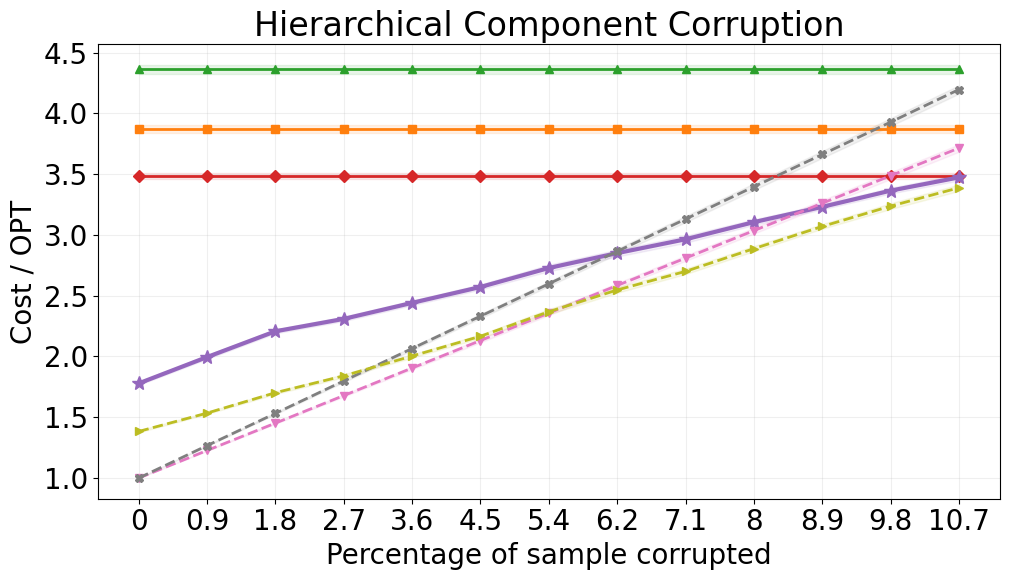


Average Cost / Gurobi reference
Algorithm                         0%        0.9%        1.8%        2.7%        3.6%        4.5%        5.4%        6.2%        7.1%        8.0%        8.9%        9.8%       10.7%
corrupted components               0           1           2           3           4           5           6           7           8           9          10          11          12
# corrupted                        0       3,906       7,812      11,718      15,624      19,530      23,436      27,342      31,248      35,154      39,060      42,966      46,872
Greedy                      3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866    3164.866
Fotakis                        3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874       3.874
Fotakis PD                     4.362       4.362       4.362  

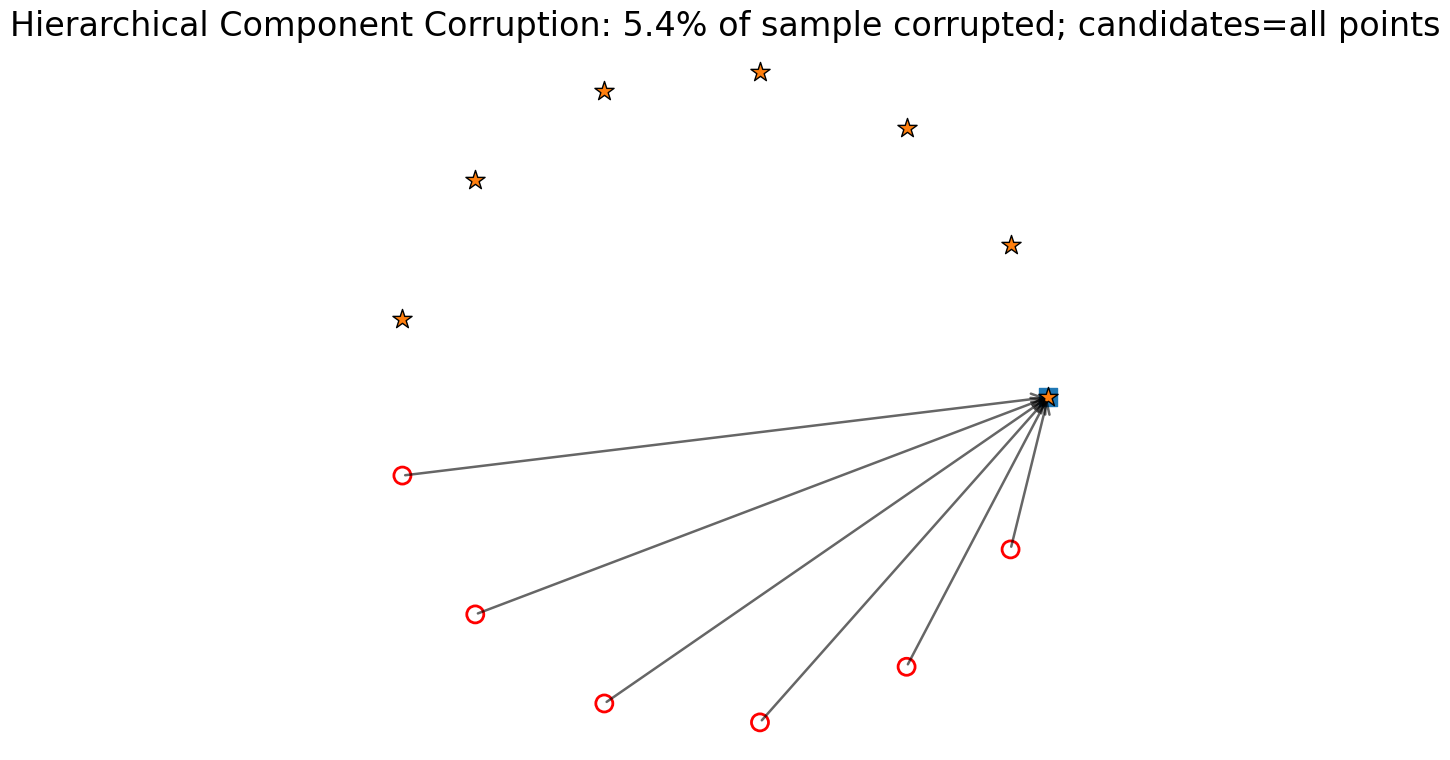

In [ ]:
# ============================================================
# 10B. PLOT — HIERARCHICAL COMPONENT CORRUPTION
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = False
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'FH_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 10A experiment cell before plotting.')

def _plot_fh():
    _d=FH_PLOT_STATE
    FH_BASE_N=_d['FH_BASE_N']; FH_EXAMPLE_Q=_d['FH_EXAMPLE_Q']; FH_NUM_CORRUPTED=_d['FH_NUM_CORRUPTED']
    FH_Q=_d['FH_Q']; FH_SAMPLE_N=_d['FH_SAMPLE_N']; FH_X=_d['FH_X']; FH_XLABELS=_d['FH_XLABELS']
    candidate_label=_d['candidate_label']; fh_cost=_d['fh_cost']; hidden=_d['hidden']
    opened_gadgets=_d['opened_gadgets']; pm=_d['pm']

    pct=100*FH_X
    pct_labels=[f'{x:.1f}'.rstrip('0').rstrip('.') for x in pct]
    exp_plot_nine(pct,fh_cost,
                  'Hierarchical Component Corruption',
                  'Percentage of sample corrupted','corrupt_fotakis_gadget_erasure',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(fh_cost,FH_XLABELS,
                    [('corrupted components',[str(int(q)) for q in FH_Q]),
                     ('# corrupted',[f'{k:,}' for k in FH_NUM_CORRUPTED])],
                    width=12)

    plt.figure(figsize=(8,8))
    plt.scatter(pm[1:,0],pm[1:,1],s=85,facecolors='none',label='Rare hierarchical components')
    plt.scatter(pm[0,0],pm[0,1],s=150,marker='s',label='Dense sink component')
    for j in hidden:
        plt.annotate('',xy=pm[0],xytext=pm[j],
                     arrowprops=dict(arrowstyle='->',linewidth=1.8,alpha=.6))
    plt.scatter(pm[hidden,0],pm[hidden,1],s=150,facecolors='none',
                edgecolors='red',linewidths=2,label='Corrupted components')
    plt.scatter(pm[opened_gadgets,0],pm[opened_gadgets,1],marker='*',s=210,
                edgecolors='black',label=f'Components used by sample {REFERENCE_NAME}')
    plt.axis('equal'); plt.axis('off')
    plt.title(f'Hierarchical Component Corruption: {100*FH_EXAMPLE_Q*FH_BASE_N/FH_SAMPLE_N:.1f}% '
              f'of sample corrupted; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend(ncol=2,fontsize=max(8,global_font-3))
    plt.tight_layout()
    exp_save_current('corrupt_fotakis_gadget_erasure_instance'); plt.show()

_plot_fh()

In [ ]:
# ============================================================
# 11A. RUN — CIRCULAR CLUSTER CORRUPTION
# ============================================================
_experiment_start = time.perf_counter()

GHOST_NUM_OUTER_SEEDS = 10
GHOST_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
GHOST_OUTER_SEEDS = exp_select_outer_seeds(GHOST_NUM_OUTER_SEEDS)

GHOST_K = 8
GHOST_N = 20000
GHOST_SUPPORT_PER_CLUSTER = 100
GHOST_DIRICHLET_ALPHA = 10.0
GHOST_TRUE_RADIUS = 1.0
GHOST_FALSE_RADIUS = 8.0
GHOST_LOCAL_RADIUS = .06 # same uniform-disk radius as Accurate Circular Clusters
GHOST_SUPPORT_SEED = 110001
GHOST_FACILITY_COST = 1250.0
GHOST_MASS = 250
GHOST_Q = np.arange(GHOST_K+1,dtype=np.int32)
GHOST_NUM_CORRUPTED = GHOST_Q*GHOST_MASS
GHOST_X = GHOST_NUM_CORRUPTED/GHOST_N
GHOST_XLABELS = ['0%']+[f'{100*x:.2f}%' for x in GHOST_X[1:]]
GHOST_EXAMPLE_Q = 6

def ghost_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_circular_ghost_geometry():
    support_rng=exp_support_rng(GHOST_SUPPORT_SEED)
    theta=2*np.pi*np.arange(GHOST_K)/GHOST_K; directions=np.column_stack([np.cos(theta),np.sin(theta)])
    true_centers=GHOST_TRUE_RADIUS*directions; ghost_centers=GHOST_FALSE_RADIUS*directions; facilities=np.vstack([true_centers,ghost_centers]); M=len(facilities)
    true_points=np.empty((GHOST_K*GHOST_SUPPORT_PER_CLUSTER,2)); ghost_points=np.empty_like(true_points); true_support=[]; ghost_support=[]
    for j in range(GHOST_K):
        a=j*GHOST_SUPPORT_PER_CLUSTER; b=a+GHOST_SUPPORT_PER_CLUSTER
        true_points[a:b]=sample_uniform_ball(true_centers[j],GHOST_LOCAL_RADIUS,GHOST_SUPPORT_PER_CLUSTER,support_rng)
        ghost_points[a:b]=sample_uniform_ball(ghost_centers[j],GHOST_LOCAL_RADIUS,GHOST_SUPPORT_PER_CLUSTER,support_rng)
        true_support.append(np.arange(M+a,M+b,dtype=np.int32)); ghost_support.append(np.arange(M+GHOST_K*GHOST_SUPPORT_PER_CLUSTER+a,M+GHOST_K*GHOST_SUPPORT_PER_CLUSTER+b,dtype=np.int32))
    return facilities,true_centers,ghost_centers,true_points,ghost_points,true_support,ghost_support

GHOST_FIXED_FACILITIES,GHOST_FIXED_TRUE_CENTERS,GHOST_FIXED_CENTERS,GHOST_FIXED_TRUE_POINTS,GHOST_FIXED_POINTS,GHOST_FIXED_TRUE_SUPPORT,GHOST_FIXED_SUPPORT=make_circular_ghost_geometry()

def make_circular_ghost(seed):
    rng=np.random.default_rng(int(seed)); counts=exp_dirichlet_counts(rng,GHOST_K,GHOST_N,GHOST_DIRICHLET_ALPHA)
    facilities=GHOST_FIXED_FACILITIES.copy(); true_centers=GHOST_FIXED_TRUE_CENTERS.copy(); ghost_centers=GHOST_FIXED_CENTERS.copy()
    true_points=GHOST_FIXED_TRUE_POINTS.copy(); ghost_points=GHOST_FIXED_POINTS.copy(); true_support=[ids.copy() for ids in GHOST_FIXED_TRUE_SUPPORT]; ghost_support=[ids.copy() for ids in GHOST_FIXED_SUPPORT]
    coordinates=np.vstack([facilities,true_points,ghost_points]); online=[]; clean=[]
    for j,count in enumerate(counts):
        online.append(rng.choice(true_support[j],size=int(count),replace=True)); clean.append(rng.choice(true_support[j],size=int(count),replace=True))
    online=np.concatenate(online).astype(np.int32); clean=np.concatenate(clean).astype(np.int32)
    crng=np.random.default_rng(100000+int(seed)); ghost_order=crng.permutation(GHOST_K).astype(np.int32); pos_order=crng.permutation(GHOST_N).astype(np.int32)
    positions=[]; replacements=[]
    for rank,ghost in enumerate(ghost_order):
        a=rank*GHOST_MASS; b=a+GHOST_MASS; positions.append(pos_order[a:b]); replacements.append(crng.choice(ghost_support[int(ghost)],size=GHOST_MASS,replace=True).astype(np.int32))
    return coordinates,online,clean,true_support,ghost_support,true_centers,ghost_centers,ghost_order,positions,replacements,counts

def make_ghost_sample(clean,positions,replacements,q):
    sample=clean.copy()
    for r in range(int(q)): sample[positions[r]]=replacements[r]
    return sample

ghost_cost=np.empty((len(GHOST_OUTER_SEEDS),len(GHOST_Q),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(GHOST_OUTER_SEEDS):
    print(f'Circular Cluster Corruption: outer seed {s+1}/{len(GHOST_OUTER_SEEDS)}',flush=True)
    coordinates,online,clean,true_support,ghost_support,true_centers,ghost_centers,ghost_order,positions,replacements,counts=make_circular_ghost(outer_seed)
    designated_count=2*GHOST_K
    coordinates,support_groups,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,designated_count,true_support+ghost_support,GHOST_CANDIDATE_FRACTION,GHOST_SUPPORT_SEED,'true + false-cluster centers')
    true_support=support_groups[:GHOST_K]; ghost_support=support_groups[GHOST_K:]; online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,GHOST_FACILITY_COST,dtype=np.float64)
    D=precompute_distance_matrix(coordinates,ghost_distance); pre=precompute_meyerson(D,costs); online_ref=exp_reference(D,costs,online,pre); plain=exp_run_plain_four(D,costs,online,pre)
    print(f'  n={len(online):,}, true-cluster counts={counts.min():,}--{counts.max():,}, OPT={online_ref["total"]:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,q in enumerate(GHOST_Q):
        sample=make_ghost_sample(clean,positions,replacements,q); sample_ref=exp_reference(D,costs,sample,pre); sv=exp_run_sample_five(D,costs,online,sample,sample_ref,pre)
        ghost_cost[s,e,:,:4]=plain/online_ref['total']; ghost_cost[s,e,:,4:]=sv/online_ref['total']
        ghost_support_candidates=np.concatenate([ids[ids<M] for ids in ghost_support]) if ghost_support else np.empty(0,dtype=np.int32)
        ghost_candidate_ids=np.concatenate([np.arange(GHOST_K,2*GHOST_K,dtype=np.int32),ghost_support_candidates])
        ghost_open=np.intersect1d(sample_ref['opened'],ghost_candidate_ids).size
        print(f'  corrupted={GHOST_NUM_CORRUPTED[e]:,}/{GHOST_N:,} ({100*GHOST_X[e]:.2f}%), sample Gurobi false-cluster facilities={ghost_open}',flush=True)

coordinates,online,clean,true_support,ghost_support,true_centers,ghost_centers,ghost_order,positions,replacements,counts=make_circular_ghost(int(GHOST_OUTER_SEEDS[0]))
designated_count=2*GHOST_K
coordinates,support_groups,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,designated_count,true_support+ghost_support,GHOST_CANDIDATE_FRACTION,GHOST_SUPPORT_SEED,'true + false-cluster centers')
true_support=support_groups[:GHOST_K]; ghost_support=support_groups[GHOST_K:]; online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,GHOST_FACILITY_COST,dtype=np.float64)
sample=make_ghost_sample(clean,positions,replacements,GHOST_EXAMPLE_Q); D=precompute_distance_matrix(coordinates,ghost_distance); pre=precompute_meyerson(D,costs)
ref=exp_reference(D,costs,sample,pre); active=ghost_order[:GHOST_EXAMPLE_Q]

GHOST_PLOT_STATE = {
    'GHOST_EXAMPLE_Q': GHOST_EXAMPLE_Q,
    'GHOST_MASS': GHOST_MASS,
    'GHOST_N': GHOST_N,
    'GHOST_NUM_CORRUPTED': GHOST_NUM_CORRUPTED,
    'GHOST_X': GHOST_X,
    'GHOST_XLABELS': GHOST_XLABELS,
    'active': active,
    'candidate_label': candidate_label,
    'coordinates': coordinates,
    'ghost_centers': ghost_centers,
    'ghost_cost': ghost_cost,
    'ghost_support': ghost_support,
    'ref': ref,
    'true_centers': true_centers,
    'true_support': true_support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Circular Cluster Corruption: outer seed 1/10
  n=20,000, true-cluster counts=1,180--3,126, OPT=10375.732, candidates=true + false-cluster centers (M=16)
  corrupted=0/20,000 (0.00%), sample Gurobi false-cluster facilities=0
  corrupted=250/20,000 (1.25%), sample Gurobi false-cluster facilities=1
  corrupted=500/20,000 (2.50%), sample Gurobi false-cluster facilities=2
  corrupted=750/20,000 (3.75%), sample Gurobi false-cluster facilities=3
  corrupted=1,000/20,000 (5.00%), sample Gurobi false-cluster facilities=4
  corrupted=1,250/20,000 (6.25%), sample Gurobi false-cluster facilities=5
  corrupted=1,500/20,000 (7.50%), sample Gurobi false-cluster facilities=6
  corrupted=1,750/20,000 (8.75%), sample Gurobi false-cluster facilities=7
  corrupted=2,000/20,000 (10.00%), sample Gurobi false-cluster facilities=8
Circular Cluster Corruption: outer seed 2/10
  n=20,000, true-cluster counts=1,371--3,763, OPT=10510.692, candidates=true + false-cluster centers (M=16)
  corrupted=0/20,000 (0.00%)

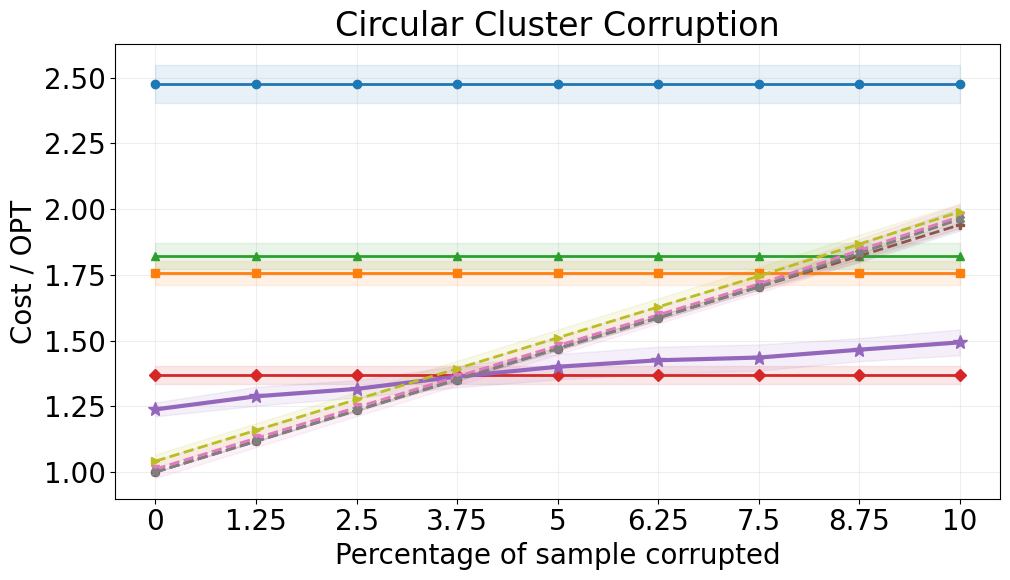


Average Cost / Gurobi reference
Algorithm                        0%      1.25%      2.50%      3.75%      5.00%      6.25%      7.50%      8.75%     10.00%
# corrupted                       0        250        500        750      1,000      1,250      1,500      1,750      2,000
Greedy                        2.477      2.477      2.477      2.477      2.477      2.477      2.477      2.477      2.477
Fotakis                       1.758      1.758      1.758      1.758      1.758      1.758      1.758      1.758      1.758
Fotakis PD                    1.822      1.822      1.822      1.822      1.822      1.822      1.822      1.822      1.822
Meyerson                      1.369      1.369      1.369      1.369      1.369      1.369      1.369      1.369      1.369
ROBUST-ONLINE                 1.238      1.288      1.316      1.363      1.400      1.425      1.435      1.465      1.493
Gurobi + Greedy               1.000      1.117      1.235      1.352      1.469      1.586      1.7

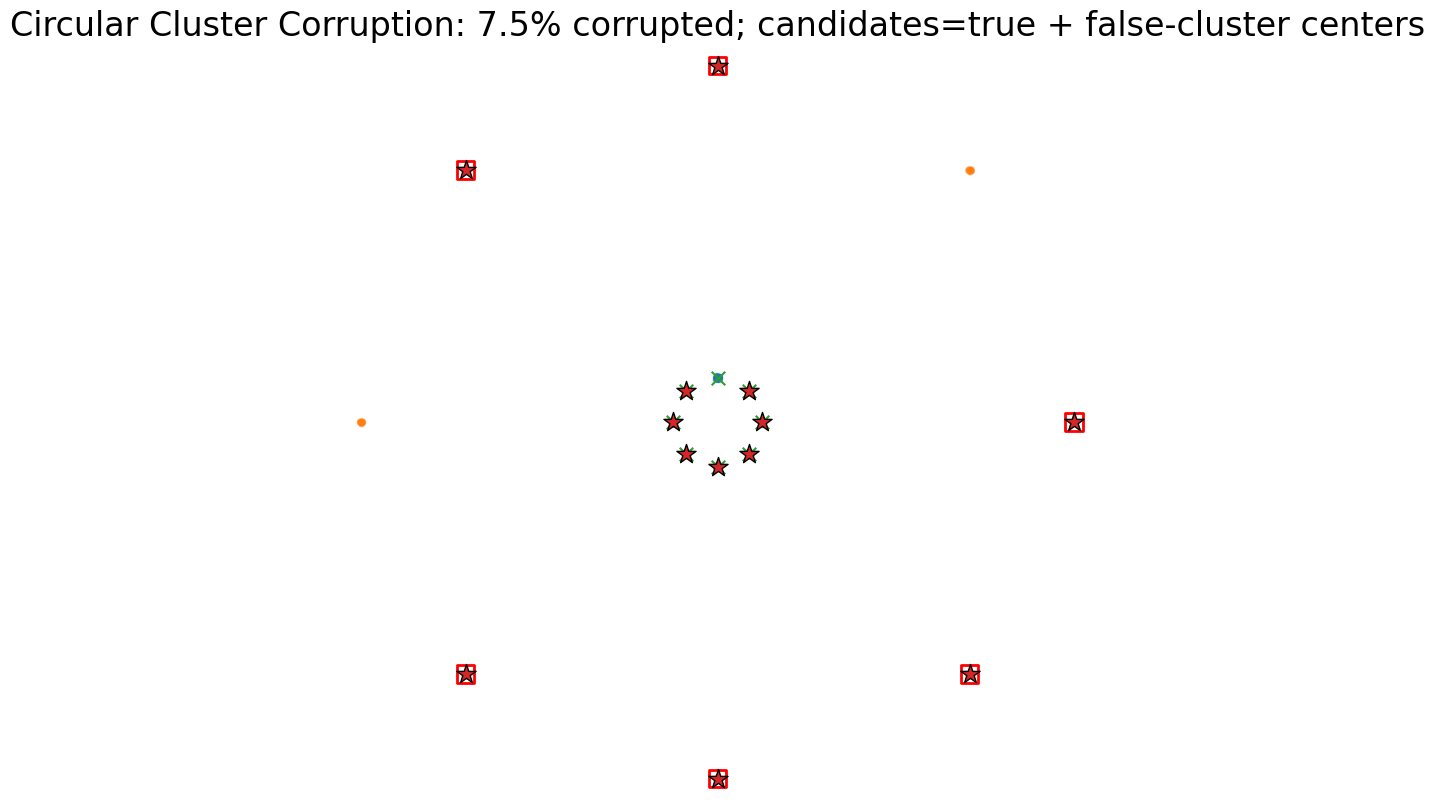

In [ ]:
# ============================================================
# 11B. PLOT — CIRCULAR CLUSTER CORRUPTION
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = True
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'GHOST_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 11A experiment cell before plotting.')

def _plot_ghost():
    _d=GHOST_PLOT_STATE
    GHOST_EXAMPLE_Q=_d['GHOST_EXAMPLE_Q']; GHOST_MASS=_d['GHOST_MASS']; GHOST_N=_d['GHOST_N']
    GHOST_NUM_CORRUPTED=_d['GHOST_NUM_CORRUPTED']; GHOST_X=_d['GHOST_X']; GHOST_XLABELS=_d['GHOST_XLABELS']
    active=_d['active']; candidate_label=_d['candidate_label']; coordinates=_d['coordinates']
    ghost_centers=_d['ghost_centers']; ghost_cost=_d['ghost_cost']; ghost_support=_d['ghost_support']
    ref=_d['ref']; true_centers=_d['true_centers']; true_support=_d['true_support']

    pct=100*GHOST_X
    pct_labels=[f'{x:.2f}'.rstrip('0').rstrip('.') for x in pct]
    exp_plot_nine(pct,ghost_cost,'Circular Cluster Corruption',
                  'Percentage of sample corrupted','corrupt_gaussian_ghosts',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(ghost_cost,GHOST_XLABELS,
                    [('# corrupted',[f'{k:,}' for k in GHOST_NUM_CORRUPTED])])

    plt.figure(figsize=(8.5,8.5))
    plt.scatter(coordinates[np.concatenate(true_support),0],
                coordinates[np.concatenate(true_support),1],s=8,alpha=.22,label='True client support')
    plt.scatter(coordinates[np.concatenate(ghost_support),0],
                coordinates[np.concatenate(ghost_support),1],s=7,alpha=.08,label='False-cluster support')
    plt.scatter(true_centers[:,0],true_centers[:,1],marker='x',s=95,label='True candidate facilities')
    plt.scatter(ghost_centers[:,0],ghost_centers[:,1],marker='s',s=55,
                facecolors='none',label='False-cluster candidate facilities')
    plt.scatter(ghost_centers[active,0],ghost_centers[active,1],marker='s',s=160,
                facecolors='none',edgecolors='red',linewidths=2,label='Activated false clusters')
    plt.scatter(coordinates[ref['opened'],0],coordinates[ref['opened'],1],marker='*',s=210,
                edgecolors='black',label=f'Corrupted-sample {REFERENCE_NAME}')
    plt.axis('equal'); plt.axis('off')
    plt.title(f'Circular Cluster Corruption: {100*GHOST_EXAMPLE_Q*GHOST_MASS/GHOST_N:.1f}% '
              f'corrupted; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend(ncol=2,fontsize=max(8,global_font-3))
    plt.tight_layout()
    exp_save_current('corrupt_gaussian_ghosts_instance'); plt.show()

_plot_ghost()

In [ ]:
# ============================================================
# 12A. RUN — PAIRED CLUSTER CORRUPTION — B_i -> A_i
# ============================================================
_experiment_start = time.perf_counter()

CDUMB_NUM_OUTER_SEEDS = 10
CDUMB_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
CDUMB_OUTER_SEEDS = exp_select_outer_seeds(CDUMB_NUM_OUTER_SEEDS)

CDUMB_PAIRS = 8
CDUMB_N = 20000
CDUMB_MACRO_RADIUS = 5.0
CDUMB_PAIR_SEPARATION = .8
CDUMB_SUPPORT_PER_CLUSTER = 5
CDUMB_LOCAL_RADIUS = .04
CDUMB_SUPPORT_SEED = 71001 # shared with Accurate Paired Clusters
if CDUMB_N % (2*CDUMB_PAIRS) != 0: raise ValueError('CDUMB_N must be divisible by 2*CDUMB_PAIRS.')
CDUMB_COUNT = CDUMB_N//(2*CDUMB_PAIRS)
CDUMB_FACILITY_COST = 500.0
CDUMB_Q = np.arange(CDUMB_PAIRS+1,dtype=np.int32)
CDUMB_SAMPLE_N = CDUMB_N
CDUMB_NUM_CORRUPTED = CDUMB_Q*CDUMB_COUNT
CDUMB_X = CDUMB_NUM_CORRUPTED/CDUMB_SAMPLE_N
CDUMB_XLABELS = ['0%']+[f'{100*x:.2f}%' for x in CDUMB_X[1:]]
CDUMB_EXAMPLE_Q = 4

def cdumb_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64); d=A[:,None,:]-B[None,:,:]
    return np.sqrt(np.sum(d*d,axis=2))

def make_dumbbell_collapse_geometry():
    support_rng=exp_support_rng(CDUMB_SUPPORT_SEED); theta=2*np.pi*np.arange(CDUMB_PAIRS)/CDUMB_PAIRS
    mid=CDUMB_MACRO_RADIUS*np.column_stack([np.cos(theta),np.sin(theta)]); tangent=np.column_stack([-np.sin(theta),np.cos(theta)])
    A=mid-.5*CDUMB_PAIR_SEPARATION*tangent; B=mid+.5*CDUMB_PAIR_SEPARATION*tangent
    centers=np.vstack([A,B]); M=len(centers); points=np.empty((M*CDUMB_SUPPORT_PER_CLUSTER,2)); support=[]
    for j in range(M):
        a=j*CDUMB_SUPPORT_PER_CLUSTER; b=a+CDUMB_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],CDUMB_LOCAL_RADIUS,CDUMB_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(M+a,M+b,dtype=np.int32))
    return centers,points,support,A,B

CDUMB_FIXED_CENTERS,CDUMB_FIXED_POINTS,CDUMB_FIXED_SUPPORT,CDUMB_FIXED_A,CDUMB_FIXED_B=make_dumbbell_collapse_geometry()

def make_dumbbell_collapse(seed):
    rng=np.random.default_rng(int(seed)); centers=CDUMB_FIXED_CENTERS.copy(); points=CDUMB_FIXED_POINTS.copy()
    support=[ids.copy() for ids in CDUMB_FIXED_SUPPORT]; A=CDUMB_FIXED_A.copy(); B=CDUMB_FIXED_B.copy()
    coordinates=np.vstack([centers,points]); online=[]; clean=[]
    for j in range(2*CDUMB_PAIRS):
        online.append(rng.choice(support[j],size=CDUMB_COUNT,replace=True)); clean.append(rng.choice(support[j],size=CDUMB_COUNT,replace=True))
    online=np.concatenate(online).astype(np.int32); clean=np.concatenate(clean).astype(np.int32)
    crng=np.random.default_rng(100000+int(seed)); pair_order=crng.permutation(CDUMB_PAIRS).astype(np.int32)
    replacements=[crng.choice(support[int(i)],size=CDUMB_COUNT,replace=True).astype(np.int32) for i in pair_order]
    return coordinates,online,clean,support,centers,A,B,pair_order,replacements

def make_cdumb_sample(clean,pair_order,replacements,q):
    sample=clean.copy()
    for r in range(int(q)):
        i=int(pair_order[r]); a=(CDUMB_PAIRS+i)*CDUMB_COUNT; sample[a:a+CDUMB_COUNT]=replacements[r]
    return sample

cdumb_cost=np.empty((len(CDUMB_OUTER_SEEDS),len(CDUMB_Q),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(CDUMB_OUTER_SEEDS):
    print(f'Paired Cluster Corruption: outer seed {s+1}/{len(CDUMB_OUTER_SEEDS)}',flush=True)
    coordinates,online,clean,support,centers,A,B,pair_order,replacements=make_dumbbell_collapse(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(centers),support,CDUMB_CANDIDATE_FRACTION,CDUMB_SUPPORT_SEED,'paired-cluster centers')
    online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,CDUMB_FACILITY_COST,dtype=np.float64)
    D=precompute_distance_matrix(coordinates,cdumb_distance); pre=precompute_meyerson(D,costs)
    online_ref=exp_reference(D,costs,online,pre); plain=exp_run_plain_four(D,costs,online,pre)
    print(f'  n={len(online):,}, clients/endpoint={CDUMB_COUNT:,}, OPT={online_ref["total"]:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,q in enumerate(CDUMB_Q):
        sample=make_cdumb_sample(clean,pair_order,replacements,q); sample_ref=exp_reference(D,costs,sample,pre)
        sv=exp_run_sample_five(D,costs,online,sample,sample_ref,pre)
        cdumb_cost[s,e,:,:4]=plain/online_ref['total']; cdumb_cost[s,e,:,4:]=sv/online_ref['total']
        print(f'  corrupted={CDUMB_NUM_CORRUPTED[e]:,}/{CDUMB_SAMPLE_N:,} ({100*CDUMB_X[e]:.2f}%), sample Gurobi facilities={len(sample_ref["opened"])}',flush=True)

coordinates,online,clean,support,centers,A,B,pair_order,replacements=make_dumbbell_collapse(int(CDUMB_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,len(centers),support,CDUMB_CANDIDATE_FRACTION,CDUMB_SUPPORT_SEED,'paired-cluster centers')
online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,CDUMB_FACILITY_COST,dtype=np.float64)
sample=make_cdumb_sample(clean,pair_order,replacements,CDUMB_EXAMPLE_Q); D=precompute_distance_matrix(coordinates,cdumb_distance)
pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,sample,pre)

CDUMB_PLOT_STATE = {
    'A': A,
    'B': B,
    'CDUMB_COUNT': CDUMB_COUNT,
    'CDUMB_EXAMPLE_Q': CDUMB_EXAMPLE_Q,
    'CDUMB_NUM_CORRUPTED': CDUMB_NUM_CORRUPTED,
    'CDUMB_PAIRS': CDUMB_PAIRS,
    'CDUMB_SAMPLE_N': CDUMB_SAMPLE_N,
    'CDUMB_X': CDUMB_X,
    'CDUMB_XLABELS': CDUMB_XLABELS,
    'candidate_label': candidate_label,
    'cdumb_cost': cdumb_cost,
    'centers': centers,
    'coordinates': coordinates,
    'pair_order': pair_order,
    'ref': ref,
    'support': support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Paired Cluster Corruption: outer seed 1/10
  n=20,000, clients/endpoint=1,250, OPT=8530.569, candidates=paired-cluster centers (M=16)
  corrupted=0/20,000 (0.00%), sample Gurobi facilities=16
  corrupted=1,250/20,000 (6.25%), sample Gurobi facilities=15
  corrupted=2,500/20,000 (12.50%), sample Gurobi facilities=14
  corrupted=3,750/20,000 (18.75%), sample Gurobi facilities=13
  corrupted=5,000/20,000 (25.00%), sample Gurobi facilities=12
  corrupted=6,250/20,000 (31.25%), sample Gurobi facilities=11
  corrupted=7,500/20,000 (37.50%), sample Gurobi facilities=10
  corrupted=8,750/20,000 (43.75%), sample Gurobi facilities=9
  corrupted=10,000/20,000 (50.00%), sample Gurobi facilities=8
Paired Cluster Corruption: outer seed 2/10
  n=20,000, clients/endpoint=1,250, OPT=8531.823, candidates=paired-cluster centers (M=16)
  corrupted=0/20,000 (0.00%), sample Gurobi facilities=16
  corrupted=1,250/20,000 (6.25%), sample Gurobi facilities=15
  corrupted=2,500/20,000 (12.50%), sample Gurobi fac

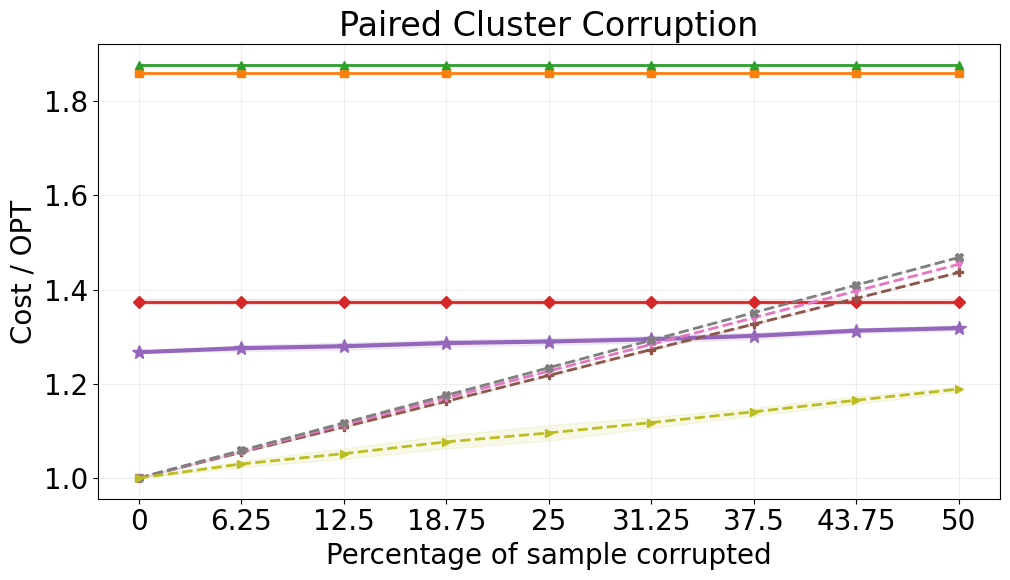


Average Cost / Gurobi reference
Algorithm                        0%      6.25%     12.50%     18.75%     25.00%     31.25%     37.50%     43.75%     50.00%
# corrupted                       0      1,250      2,500      3,750      5,000      6,250      7,500      8,750     10,000
Greedy                       14.940     14.940     14.940     14.940     14.940     14.940     14.940     14.940     14.940
Fotakis                       1.860      1.860      1.860      1.860      1.860      1.860      1.860      1.860      1.860
Fotakis PD                    1.877      1.877      1.877      1.877      1.877      1.877      1.877      1.877      1.877
Meyerson                      1.374      1.374      1.374      1.374      1.374      1.374      1.374      1.374      1.374
ROBUST-ONLINE                 1.267      1.276      1.280      1.287      1.290      1.295      1.302      1.313      1.318
Gurobi + Greedy               1.000      1.055      1.108      1.163      1.218      1.273      1.3

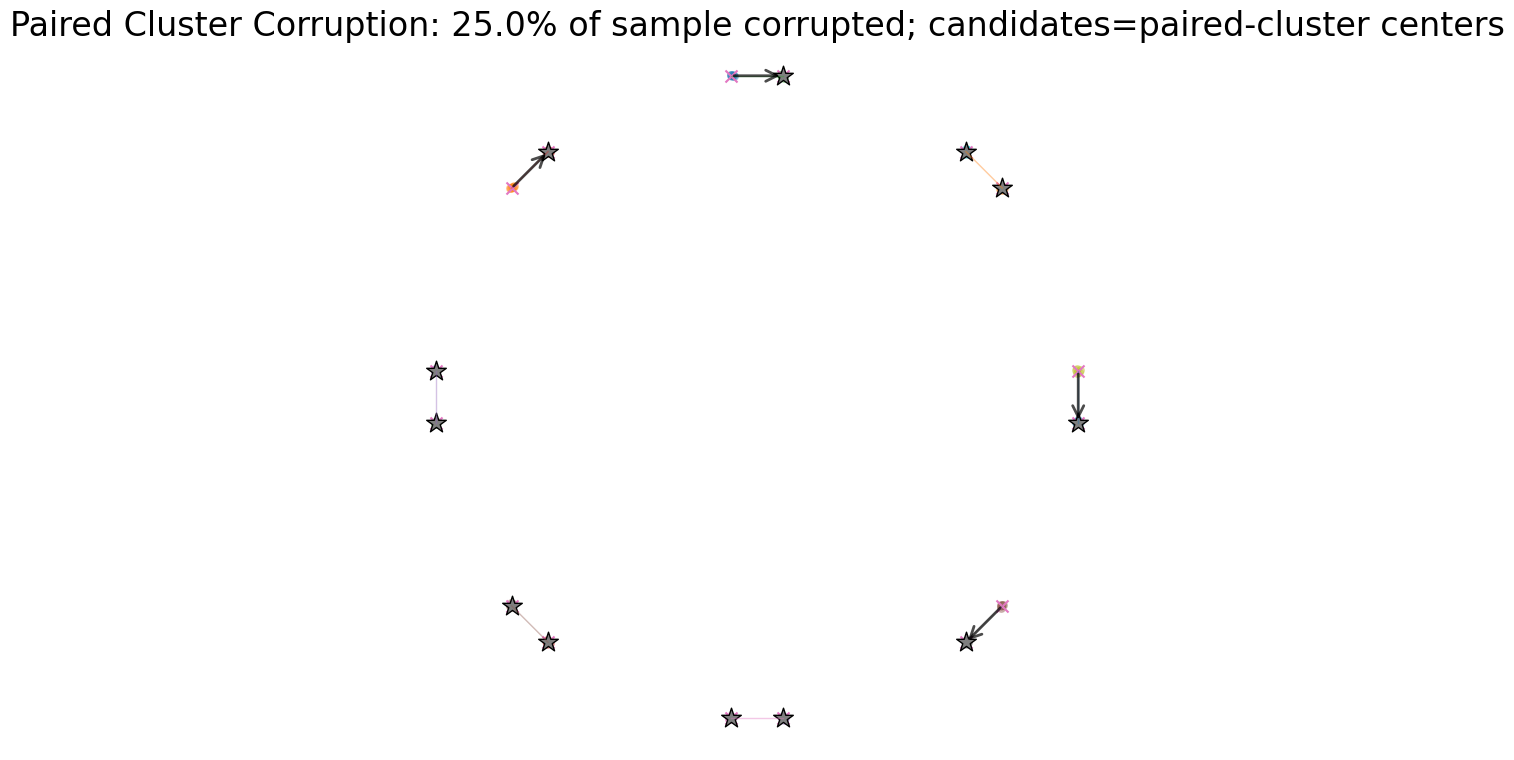

In [ ]:
# ============================================================
# 12B. PLOT — PAIRED CLUSTER CORRUPTION — B_i -> A_i
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = True
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'CDUMB_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 12A experiment cell before plotting.')

def _plot_cdumb():
    _d=CDUMB_PLOT_STATE
    A=_d['A']; B=_d['B']; CDUMB_COUNT=_d['CDUMB_COUNT']; CDUMB_EXAMPLE_Q=_d['CDUMB_EXAMPLE_Q']
    CDUMB_NUM_CORRUPTED=_d['CDUMB_NUM_CORRUPTED']; CDUMB_PAIRS=_d['CDUMB_PAIRS']
    CDUMB_SAMPLE_N=_d['CDUMB_SAMPLE_N']; CDUMB_X=_d['CDUMB_X']; CDUMB_XLABELS=_d['CDUMB_XLABELS']
    candidate_label=_d['candidate_label']; cdumb_cost=_d['cdumb_cost']; centers=_d['centers']
    coordinates=_d['coordinates']; pair_order=_d['pair_order']; ref=_d['ref']; support=_d['support']

    pct=100*CDUMB_X
    pct_labels=[f'{x:.2f}'.rstrip('0').rstrip('.') for x in pct]
    exp_plot_nine(pct,cdumb_cost,'Paired Cluster Corruption',
                  'Percentage of sample corrupted','corrupt_dumbbell_collapse',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(cdumb_cost,CDUMB_XLABELS,
                    [('# corrupted',[f'{k:,}' for k in CDUMB_NUM_CORRUPTED])])

    plt.figure(figsize=(8,8))
    for i in range(CDUMB_PAIRS):
        plt.plot([A[i,0],B[i,0]],[A[i,1],B[i,1]],linewidth=1,alpha=.4)
    for ids in support:
        plt.scatter(coordinates[ids,0],coordinates[ids,1],s=30,alpha=.35)
    for i in pair_order[:CDUMB_EXAMPLE_Q]:
        plt.annotate('',xy=A[i],xytext=B[i],
                     arrowprops=dict(arrowstyle='->',linewidth=2,alpha=.7))
    plt.scatter(centers[:,0],centers[:,1],marker='x',s=75,label='Paired-cluster centers')
    plt.scatter(coordinates[ref['opened'],0],coordinates[ref['opened'],1],marker='*',s=220,
                edgecolors='black',label=f'Corrupted-sample {REFERENCE_NAME}')
    plt.axis('equal'); plt.axis('off')
    plt.title(f'Paired Cluster Corruption: {100*CDUMB_EXAMPLE_Q*CDUMB_COUNT/CDUMB_SAMPLE_N:.1f}% '
              f'of sample corrupted; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend()
    plt.tight_layout()
    exp_save_current('corrupt_dumbbell_collapse_instance'); plt.show()

_plot_cdumb()

In [ ]:
# ============================================================
# 13A. RUN — EXPONENTIAL LINE CORRUPTION
# ============================================================
_experiment_start = time.perf_counter()

ELC_NUM_OUTER_SEEDS = 10
ELC_CANDIDATE_FRACTION = 0.0 #0 = canonical facilities only; 1 = every metric point
ELC_OUTER_SEEDS = exp_select_outer_seeds(ELC_NUM_OUTER_SEEDS)

ELC_K = 10
ELC_N = 20000
ELC_SUPPORT_PER_CLUSTER = 100
ELC_RADIUS = .05
ELC_SUPPORT_SEED = 41001 # shared with Accurate Exponential Line
ELC_FACILITY_COST = 1000.0
ELC_DEST = ELC_K-1
ELC_Q = np.arange(ELC_K,dtype=np.int32)
ELC_BLOCK = ELC_N//ELC_K
ELC_NUM_CORRUPTED = ELC_Q*ELC_BLOCK
ELC_X = ELC_NUM_CORRUPTED/ELC_N
ELC_XLABELS = ['0%']+[f'{100*x:.0f}%' for x in ELC_X[1:]]
ELC_EXAMPLE_Q = 4

def elc_distance(A,B):
    A=np.asarray(A,dtype=np.float64); B=np.asarray(B,dtype=np.float64)
    return np.abs(A[:,0][:,None]-B[:,0][None,:])

def make_exp_line_erasure_geometry():
    support_rng=exp_support_rng(ELC_SUPPORT_SEED); centers=(2.0**np.arange(ELC_K))[:,None]; points=np.empty((ELC_K*ELC_SUPPORT_PER_CLUSTER,1)); support=[]
    for j in range(ELC_K):
        a=j*ELC_SUPPORT_PER_CLUSTER; b=a+ELC_SUPPORT_PER_CLUSTER
        points[a:b]=sample_uniform_ball(centers[j],ELC_RADIUS,ELC_SUPPORT_PER_CLUSTER,support_rng)
        support.append(np.arange(ELC_K+a,ELC_K+b,dtype=np.int32))
    return centers,points,support

ELC_FIXED_CENTERS,ELC_FIXED_POINTS,ELC_FIXED_SUPPORT=make_exp_line_erasure_geometry()

def make_exp_line_erasure(seed):
    rng=np.random.default_rng(int(seed)); centers=ELC_FIXED_CENTERS.copy(); points=ELC_FIXED_POINTS.copy(); support=[ids.copy() for ids in ELC_FIXED_SUPPORT]
    if ELC_BLOCK*ELC_K!=ELC_N: raise ValueError('ELC_N must be divisible by ELC_K.')
    coordinates=np.vstack([centers,points]); online=[]; clean=[]
    for j in range(ELC_K):
        online.append(rng.choice(support[j],size=ELC_BLOCK,replace=True)); clean.append(rng.choice(support[j],size=ELC_BLOCK,replace=True))
    online=np.concatenate(online).astype(np.int32); clean=np.concatenate(clean).astype(np.int32); crng=np.random.default_rng(100000+int(seed))
    replacements=[crng.choice(support[ELC_DEST],size=ELC_BLOCK,replace=True).astype(np.int32) for _ in range(ELC_K-1)]
    return coordinates,online,clean,support,centers,replacements

def make_elc_sample(clean,replacements,q):
    sample=clean.copy()
    for source in range(int(q)): sample[source*ELC_BLOCK:(source+1)*ELC_BLOCK]=replacements[source]
    return sample

elc_cost=np.empty((len(ELC_OUTER_SEEDS),len(ELC_Q),len(ALG_SEEDS),9),dtype=np.float64)
for s,outer_seed in enumerate(ELC_OUTER_SEEDS):
    print(f'Exponential Line Corruption: outer seed {s+1}/{len(ELC_OUTER_SEEDS)}',flush=True)
    coordinates,online,clean,support,centers,replacements=make_exp_line_erasure(outer_seed)
    coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,ELC_K,support,ELC_CANDIDATE_FRACTION,ELC_SUPPORT_SEED,'cluster centers')
    online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,ELC_FACILITY_COST,dtype=np.float64)
    D=precompute_distance_matrix(coordinates,elc_distance); pre=precompute_meyerson(D,costs); online_ref=exp_reference(D,costs,online,pre); plain=exp_run_plain_four(D,costs,online,pre)
    print(f'  n={len(online):,}, clients/cluster={ELC_BLOCK:,}, OPT={online_ref["total"]:.3f}, candidates={candidate_label} (M={M:,})',flush=True)
    for e,q in enumerate(ELC_Q):
        sample=make_elc_sample(clean,replacements,q); sample_ref=exp_reference(D,costs,sample,pre); sv=exp_run_sample_five(D,costs,online,sample,sample_ref,pre)
        elc_cost[s,e,:,:4]=plain/online_ref['total']; elc_cost[s,e,:,4:]=sv/online_ref['total']
        print(f'  corrupted={ELC_NUM_CORRUPTED[e]:,}/{ELC_N:,} ({100*ELC_X[e]:.0f}%), erased clusters={int(q)}',flush=True)

coordinates,online,clean,support,centers,replacements=make_exp_line_erasure(int(ELC_OUTER_SEEDS[0]))
coordinates,support,remap,M,candidate_label=exp_prepare_candidate_fraction(coordinates,ELC_K,support,ELC_CANDIDATE_FRACTION,ELC_SUPPORT_SEED,'cluster centers')
online=remap[online]; clean=remap[clean]; replacements=[remap[np.asarray(r,dtype=np.int32)] for r in replacements]; costs=np.full(M,ELC_FACILITY_COST,dtype=np.float64)
sample=make_elc_sample(clean,replacements,ELC_EXAMPLE_Q); D=precompute_distance_matrix(coordinates,elc_distance); pre=precompute_meyerson(D,costs); ref=exp_reference(D,costs,sample,pre)

ELC_PLOT_STATE = {
    'ELC_BLOCK': ELC_BLOCK,
    'ELC_DEST': ELC_DEST,
    'ELC_EXAMPLE_Q': ELC_EXAMPLE_Q,
    'ELC_K': ELC_K,
    'ELC_N': ELC_N,
    'ELC_NUM_CORRUPTED': ELC_NUM_CORRUPTED,
    'ELC_X': ELC_X,
    'ELC_XLABELS': ELC_XLABELS,
    'candidate_label': candidate_label,
    'centers': centers,
    'coordinates': coordinates,
    'elc_cost': elc_cost,
    'ref': ref,
    'support': support,
}

print(f'Total experiment time: {(time.perf_counter()-_experiment_start)/60:.2f} minutes')


Exponential Line Corruption: outer seed 1/10
  n=20,000, clients/cluster=2,000, OPT=10511.084, candidates=cluster centers (M=10)
  corrupted=0/20,000 (0%), erased clusters=0
  corrupted=2,000/20,000 (10%), erased clusters=1
  corrupted=4,000/20,000 (20%), erased clusters=2
  corrupted=6,000/20,000 (30%), erased clusters=3
  corrupted=8,000/20,000 (40%), erased clusters=4
  corrupted=10,000/20,000 (50%), erased clusters=5
  corrupted=12,000/20,000 (60%), erased clusters=6
  corrupted=14,000/20,000 (70%), erased clusters=7
  corrupted=16,000/20,000 (80%), erased clusters=8
  corrupted=18,000/20,000 (90%), erased clusters=9
Exponential Line Corruption: outer seed 2/10
  n=20,000, clients/cluster=2,000, OPT=10510.234, candidates=cluster centers (M=10)
  corrupted=0/20,000 (0%), erased clusters=0
  corrupted=2,000/20,000 (10%), erased clusters=1
  corrupted=4,000/20,000 (20%), erased clusters=2
  corrupted=6,000/20,000 (30%), erased clusters=3
  corrupted=8,000/20,000 (40%), erased clusters

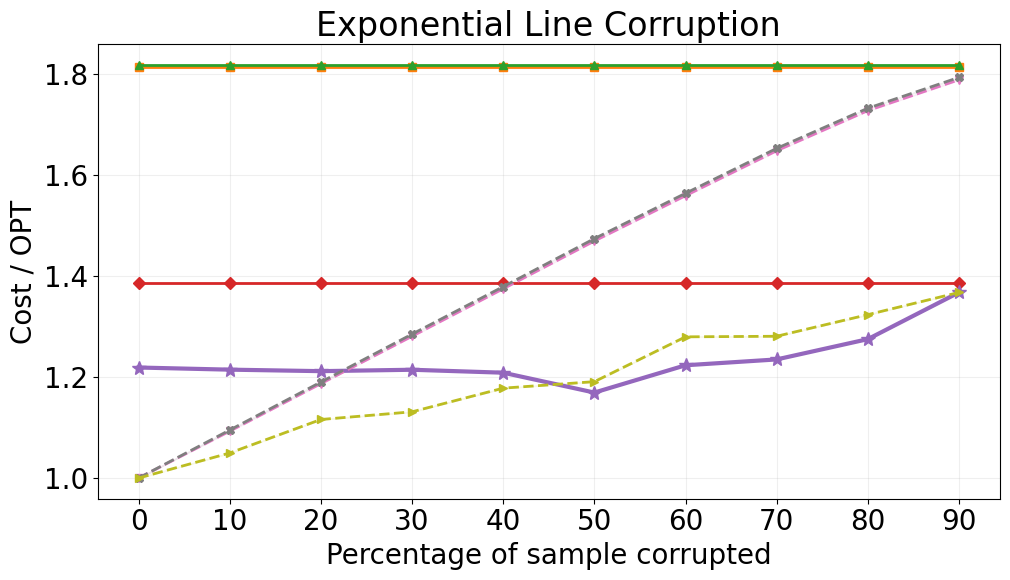


Average Cost / Gurobi reference
Algorithm                        0%        10%        20%        30%        40%        50%        60%        70%        80%        90%
# corrupted                       0      2,000      4,000      6,000      8,000     10,000     12,000     14,000     16,000     18,000
Greedy                      192.856    192.856    192.856    192.856    192.856    192.856    192.856    192.856    192.856    192.856
Fotakis                       1.813      1.813      1.813      1.813      1.813      1.813      1.813      1.813      1.813      1.813
Fotakis PD                    1.818      1.818      1.818      1.818      1.818      1.818      1.818      1.818      1.818      1.818
Meyerson                      1.387      1.387      1.387      1.387      1.387      1.387      1.387      1.387      1.387      1.387
ROBUST-ONLINE                 1.219      1.215      1.212      1.215      1.209      1.169      1.223      1.235      1.275      1.368
Gurobi + Greedy       

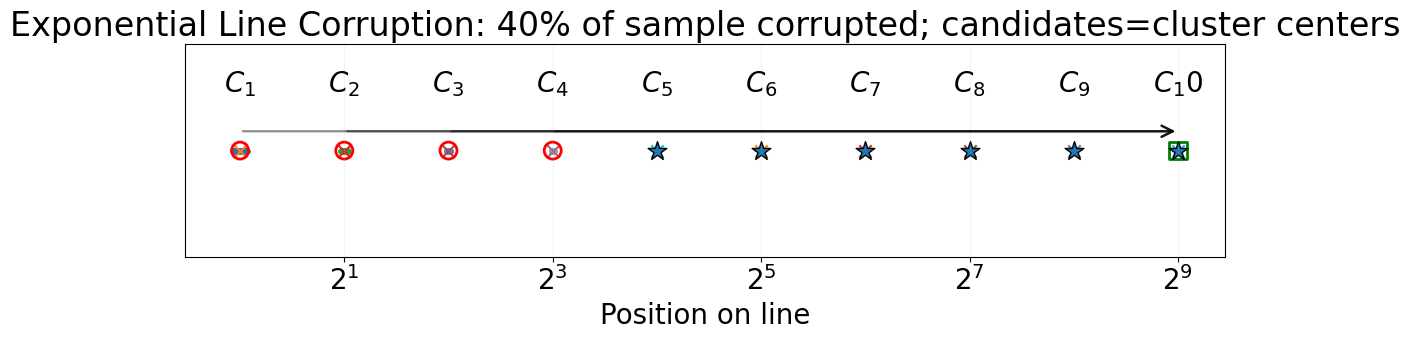

In [ ]:
# ============================================================
# 13B. PLOT — EXPONENTIAL LINE CORRUPTION
# ============================================================
# Display toggles (presentation only; all curves remain computed)
SHOW_LEGEND = False
SHOW_GREEDY = False
SHOW_GUROBI_GREEDY = False
SHOW_GUROBI_FOTAKIS = True
SHOW_GUROBI_FOTAKIS_PD = True
SHOW_GUROBI_MEYERSON = True

if 'ELC_PLOT_STATE' not in globals(): raise RuntimeError('Run the preceding 13A experiment cell before plotting.')

def _plot_elc():
    _d=ELC_PLOT_STATE
    ELC_BLOCK=_d['ELC_BLOCK']; ELC_DEST=_d['ELC_DEST']; ELC_EXAMPLE_Q=_d['ELC_EXAMPLE_Q']
    ELC_K=_d['ELC_K']; ELC_N=_d['ELC_N']; ELC_NUM_CORRUPTED=_d['ELC_NUM_CORRUPTED']
    ELC_X=_d['ELC_X']; ELC_XLABELS=_d['ELC_XLABELS']; candidate_label=_d['candidate_label']
    centers=_d['centers']; coordinates=_d['coordinates']; elc_cost=_d['elc_cost']
    ref=_d['ref']; support=_d['support']

    pct=100*ELC_X
    pct_labels=[f'{x:.0f}' for x in pct]
    exp_plot_nine(pct,elc_cost,
                  'Exponential Line Corruption',
                  'Percentage of sample corrupted','corrupt_exponential_line_prefix_erasure',
                  xticks=pct,xticklabels=pct_labels,
                  show_legend=SHOW_LEGEND,show_greedy=SHOW_GREEDY,
                  show_gurobi_greedy=SHOW_GUROBI_GREEDY,
                  show_gurobi_fotakis=SHOW_GUROBI_FOTAKIS,
                  show_gurobi_fotakis_pd=SHOW_GUROBI_FOTAKIS_PD,
                  show_gurobi_meyerson=SHOW_GUROBI_MEYERSON)
    exp_print_table(elc_cost,ELC_XLABELS,
                    [('# corrupted',[f'{k:,}' for k in ELC_NUM_CORRUPTED])])

    plt.figure(figsize=(11,3.8))
    for j in range(ELC_K):
        plt.scatter(coordinates[support[j],0],np.zeros(len(support[j])),s=12,alpha=.3)
        plt.scatter(centers[j,0],0,marker='x',s=80)
        plt.text(centers[j,0],.03,f'$C_{j+1}$',ha='center')
    for source in range(ELC_EXAMPLE_Q):
        plt.annotate('',xy=(centers[ELC_DEST,0],.01),xytext=(centers[source,0],.01),
                     arrowprops=dict(arrowstyle='->',linewidth=1.6,alpha=.45))
    plt.scatter(centers[:ELC_EXAMPLE_Q,0],np.zeros(ELC_EXAMPLE_Q),s=150,
                facecolors='none',edgecolors='red',linewidths=2,label='Erased sample clusters')
    plt.scatter(centers[ELC_DEST,0],0,s=160,marker='s',facecolors='none',
                edgecolors='green',linewidths=2,label='Corruption destination')
    plt.scatter(coordinates[ref['opened'],0],np.zeros(len(ref['opened'])),marker='*',s=200,
                edgecolors='black',label=f'Corrupted-sample {REFERENCE_NAME}')
    plt.xscale('log',base=2); plt.yticks([]); plt.xlabel('Position on line')
    plt.title(f'Exponential Line Corruption: {100*ELC_EXAMPLE_Q*ELC_BLOCK/ELC_N:.0f}% '
              f'of sample corrupted; candidates={candidate_label}')
    if SHOW_LEGEND: plt.legend(ncol=2,fontsize=max(8,global_font-3))
    plt.grid(alpha=.15); plt.tight_layout()
    exp_save_current('corrupt_exponential_line_prefix_erasure_instance'); plt.show()

_plot_elc()

In [ ]:
# ============================================================
#  RUN — SCALABILITY — EQUIDISTANT CLUSTERS
# ============================================================
import gc
from scipy.spatial.distance import cdist

SCALABILITY_N = np.array([10000,20000,40000,60000,80000],dtype=int)
SCALABILITY_K = 10
SCALABILITY_SEPARATION = 2.0
SCALABILITY_RADIUS = .10
SCALABILITY_FACILITY_COST = 1.0
SCALABILITY_SEED = 42
SCALABILITY_REPEATS = 5
SCALABILITY_BLOCK_SIZE = 128

SCALABILITY_NAMES = ['ROBUST-ONLINE']
SCALABILITY_ALGORITHMS = [MEYERSON]
SCALABILITY_MODES = [2]

def scalability_distance(A,B):
    return cdist(A,B,metric='euclidean')

def make_scalability_instance(n):
    """n candidate sites, n online clients, and n independent clean samples."""
    n=int(n)
    if n<SCALABILITY_K: raise ValueError('Use n >= SCALABILITY_K.')
    rng=np.random.default_rng(SCALABILITY_SEED)
    centers=np.eye(SCALABILITY_K)*(SCALABILITY_SEPARATION/np.sqrt(2))
    counts=np.full(SCALABILITY_K,n//SCALABILITY_K,dtype=int)
    counts[:n%SCALABILITY_K]+=1

    coordinates=np.empty((n,SCALABILITY_K),dtype=np.float64)
    online=[]; sample=[]; start=0
    for j,count in enumerate(counts):
        stop=start+int(count)
        coordinates[start:stop]=sample_uniform_ball(
            centers[j],SCALABILITY_RADIUS,int(count),rng)
        support=np.arange(start,stop,dtype=np.int32)
        online.append(rng.choice(support,size=int(count),replace=True))
        sample.append(rng.choice(support,size=int(count),replace=True))
        start=stop

    costs=np.full(n,SCALABILITY_FACILITY_COST,dtype=np.float64)
    return (coordinates,costs,np.concatenate(online).astype(np.int32),
            np.concatenate(sample).astype(np.int32))

def scalability_run(j,D,costs,online,sample):
    # The same seed is used on every repetition.
    # Algorithm preprocessing and the sample simulation are included.
    return run_algorithm(
        SCALABILITY_ALGORITHMS[j],D,costs,online,
        sample=sample if SCALABILITY_MODES[j]==2 else None,
        mode=SCALABILITY_MODES[j],seed=SCALABILITY_SEED,
        sample_reference=REFERENCE_RO,ro_connection_costs=1)

def scalability_measure(j,coordinates,costs,online,sample):
    gc.collect()
    start=time.perf_counter()
    D=precompute_distance_matrix(
        coordinates,scalability_distance,cache_path=None,
        block_size=SCALABILITY_BLOCK_SIZE,dtype=np.float32)
    matrix_done=time.perf_counter()
    result=scalability_run(j,D,costs,online,sample)
    finish=time.perf_counter()
    total=finish-start
    matrix_time=matrix_done-start
    del D,result
    return total,matrix_time

# Warm up Numba on a small instance; excluded from measurements.
print('Warming up algorithms...',flush=True)
_wx,_wc,_wo,_ws=make_scalability_instance(100)
_wo=np.tile(_wo,20); _ws=np.tile(_ws,20)
_wD=precompute_distance_matrix(
    _wx,scalability_distance,block_size=SCALABILITY_BLOCK_SIZE,dtype=np.float32)
for _j in range(len(SCALABILITY_NAMES)):
    _warm_result=scalability_run(_j,_wD,_wc,_wo,_ws)
del _wx,_wc,_wo,_ws,_wD,_warm_result
gc.collect()

# Axes: input size, timing repetition, algorithm.
scalability_seconds=np.full(
    (len(SCALABILITY_N),SCALABILITY_REPEATS,len(SCALABILITY_NAMES)),np.nan)
scalability_matrix_seconds=np.full_like(scalability_seconds,np.nan)
scalability_rows=[]

for i,n in enumerate(SCALABILITY_N):
    # Generate the instance once and reuse it for all five repetitions.
    coordinates,costs,online,sample=make_scalability_instance(n)
    print(f'\nn={n:,}; candidate facilities={len(costs):,}; '
          f'distance matrix={4*int(n)**2/1e9:.3f} GB',flush=True)

    for j,name in enumerate(SCALABILITY_NAMES):
        for r in range(SCALABILITY_REPEATS):
            # Rebuild the distance matrix and preprocessing on every repetition.
            total,matrix_time=scalability_measure(j,coordinates,costs,online,sample)
            scalability_seconds[i,r,j]=total
            scalability_matrix_seconds[i,r,j]=matrix_time
            scalability_rows.append({
                'n':int(n),'algorithm':name,'repeat':r+1,
                'seconds':total,'matrix_seconds':matrix_time,
            })
            print(f'  {name}: run {r+1}/{SCALABILITY_REPEATS}: '
                  f'{total:.3f} s (distance matrix: {matrix_time:.3f} s)',
                  flush=True)

        times=scalability_seconds[i,:,j]
        print(f'  {name}: mean = {times.mean():.3f} s, '
              f'SD = {times.std(ddof=1):.3f} s',flush=True)

# Mean and sample SD across timing repetitions.
scalability_mean=scalability_seconds.mean(axis=1)
scalability_std=scalability_seconds.std(axis=1,ddof=1)
scalability_matrix_mean=scalability_matrix_seconds.mean(axis=1)
scalability_matrix_std=scalability_matrix_seconds.std(axis=1,ddof=1)

SCALABILITY_PLOT_STATE = {
    'n': SCALABILITY_N.copy(),
    'names': SCALABILITY_NAMES.copy(),
    'seconds': scalability_seconds.copy(),
    'matrix_seconds': scalability_matrix_seconds.copy(),
}

# Save individual timings and the summary.
scalability_runs=pd.DataFrame(scalability_rows)
scalability_runs.to_csv(result_dir/'scalability_equidistant_runs.csv',index=False)

scalability_table=pd.DataFrame([
    {'n':int(n),'algorithm':name,
     'mean_seconds':scalability_mean[i,j],
     'sd_seconds':scalability_std[i,j],
     'matrix_mean_seconds':scalability_matrix_mean[i,j],
     'matrix_sd_seconds':scalability_matrix_std[i,j]}
    for i,n in enumerate(SCALABILITY_N)
    for j,name in enumerate(SCALABILITY_NAMES)
])
scalability_table.to_csv(
    result_dir/'scalability_equidistant_summary.csv',index=False)
print('\nRunning time in seconds, including distance preprocessing:')
print(scalability_table.round(3).to_string(index=False))

Warming up algorithms...

n=10,000; candidate facilities=10,000; distance matrix=0.400 GB
  ROBUST-ONLINE: run 1/5: 2.196 s (distance matrix: 1.497 s)
  ROBUST-ONLINE: run 2/5: 1.746 s (distance matrix: 1.073 s)
  ROBUST-ONLINE: run 3/5: 1.736 s (distance matrix: 1.058 s)
  ROBUST-ONLINE: run 4/5: 1.796 s (distance matrix: 1.112 s)
  ROBUST-ONLINE: run 5/5: 1.769 s (distance matrix: 1.094 s)
  ROBUST-ONLINE: mean = 1.849 s, SD = 0.195 s

n=20,000; candidate facilities=20,000; distance matrix=1.600 GB
  ROBUST-ONLINE: run 1/5: 13.042 s (distance matrix: 4.808 s)
  ROBUST-ONLINE: run 2/5: 12.542 s (distance matrix: 4.447 s)
  ROBUST-ONLINE: run 3/5: 12.485 s (distance matrix: 4.394 s)
  ROBUST-ONLINE: run 4/5: 12.469 s (distance matrix: 4.366 s)
  ROBUST-ONLINE: run 5/5: 12.304 s (distance matrix: 4.335 s)
  ROBUST-ONLINE: mean = 12.568 s, SD = 0.279 s

n=40,000; candidate facilities=40,000; distance matrix=6.400 GB
  ROBUST-ONLINE: run 1/5: 27.302 s (distance matrix: 18.787 s)
  ROBUST-

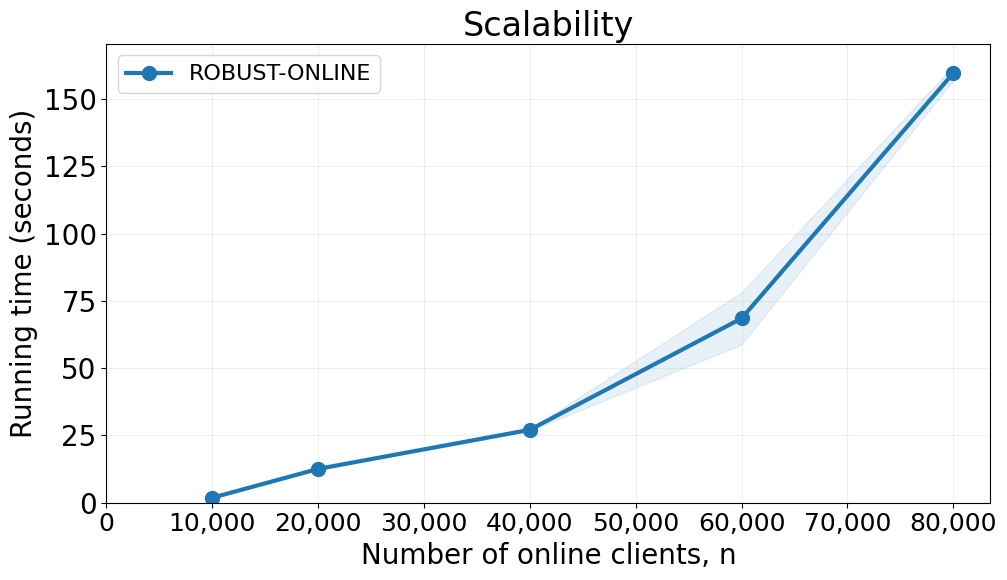

In [ ]:
# ============================================================
#  PLOT — SCALABILITY — ROBUST-ONLINE
# ============================================================
from matplotlib.ticker import StrMethodFormatter, NullFormatter

SCALABILITY_LOG_X = False              # False gives a linear x-axis.

if 'SCALABILITY_PLOT_STATE' not in globals():
    raise RuntimeError('Run the preceding scalability experiment cell first.')

def _plot_scalability():
    _d=SCALABILITY_PLOT_STATE
    n=_d['n']
    j=_d['names'].index('ROBUST-ONLINE')
    if _d['seconds'].ndim!=3 or _d['seconds'].shape[1]<2:
        raise RuntimeError('Rerun the updated experiment cell with five repetitions.')
    times=_d['seconds'][:,:,j]
    if not np.all(np.isfinite(times)):
        raise RuntimeError('Some timing repetitions are missing.')
    mean=times.mean(axis=1)
    std=times.std(axis=1,ddof=1)

    fig,ax=plt.subplots(figsize=(10.5,6.2))
    ax.plot(n,mean,color=PLOT_COLORS[j],marker=PLOT_MARKERS[j],
            markersize=10,linewidth=3,label='ROBUST-ONLINE')
    ax.fill_between(n,mean-std,mean+std,color=PLOT_COLORS[j],alpha=.10)

    ax.legend(fontsize=16)
    ax.set_xlabel('Number of online clients, n')
    ax.set_ylabel('Running time (seconds)')
    ax.set_title('Scalability')
    if SCALABILITY_LOG_X:
        ax.set_xscale('log')
        ax.set_xticks(n)
        ax.xaxis.set_minor_formatter(NullFormatter())
    else:
        ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.ticklabel_format(axis='y',style='plain',useOffset=False)
    ax.grid(alpha=.2)
    ax.tick_params(axis='x',labelsize=18)
    fig.tight_layout()
    fig.savefig(image_dir/'scalability_equidistant_robust_online.png',
                dpi=SAVE_DPI,bbox_inches='tight')
    plt.show()

_plot_scalability()

Log-log slope: 2.001
R^2 in log space: 0.9777


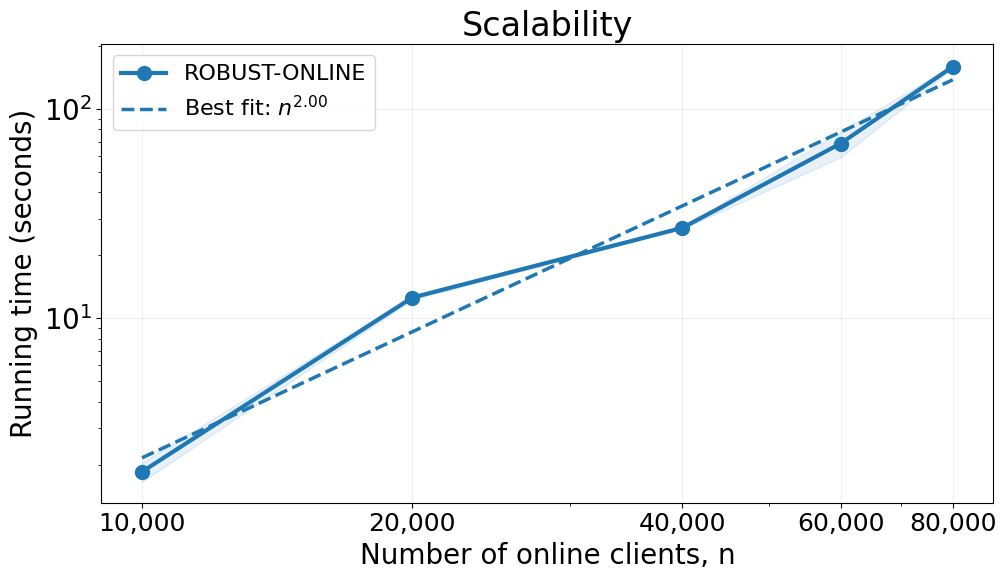

In [ ]:
# ============================================================
#  PLOT — SCALABILITY — ROBUST-ONLINE — LOG-LOG + FIT
# ============================================================
from matplotlib.ticker import StrMethodFormatter, NullFormatter

if 'SCALABILITY_PLOT_STATE' not in globals():
    raise RuntimeError('Run the preceding scalability experiment cell first.')

def _plot_scalability_loglog():
    _d = SCALABILITY_PLOT_STATE
    n = _d['n']
    j = _d['names'].index('ROBUST-ONLINE')

    if _d['seconds'].ndim != 3 or _d['seconds'].shape[1] < 2:
        raise RuntimeError('Rerun the updated experiment cell with five repetitions.')

    times = _d['seconds'][:, :, j]

    if not np.all(np.isfinite(times)):
        raise RuntimeError('Some timing repetitions are missing.')

    mean = times.mean(axis=1)
    std = times.std(axis=1, ddof=1)

    # Linear regression in log-log space:
    # log(time) = slope * log(n) + intercept
    slope, intercept = np.polyfit(np.log(n), np.log(mean), 1)
    fitted = np.exp(intercept) * n**slope

    # R^2 in log space
    log_mean = np.log(mean)
    log_fit = np.log(fitted)
    r2 = 1 - np.sum((log_mean - log_fit)**2) / np.sum(
        (log_mean - log_mean.mean())**2
    )

    print(f'Log-log slope: {slope:.3f}')
    print(f'R^2 in log space: {r2:.4f}')

    fig, ax = plt.subplots(figsize=(10.5, 6.2))

    ax.plot(
        n, mean,
        color=PLOT_COLORS[j],
        marker=PLOT_MARKERS[j],
        markersize=10,
        linewidth=3,
        label='ROBUST-ONLINE'
    )

    ax.fill_between(
        n,
        np.maximum(mean - std, np.finfo(float).tiny),
        mean + std,
        color=PLOT_COLORS[j],
        alpha=.10
    )

    # Best-fit power law
    ax.plot(
        n, fitted,
        linestyle='--',
        linewidth=2.5,
        label=fr'Best fit: $n^{{{slope:.2f}}}$'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xticks(n)
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_xlabel('Number of online clients, n')
    ax.set_ylabel('Running time (seconds)')
    ax.set_title('Scalability')

    ax.legend(fontsize=16)
    ax.grid(alpha=.2)
    ax.tick_params(axis='x', labelsize=18)

    fig.tight_layout()
    fig.savefig(
        image_dir / 'scalability_equidistant_robust_online_loglog.png',
        dpi=SAVE_DPI,
        bbox_inches='tight'
    )
    plt.show()


_plot_scalability_loglog()